# Step 1 — Test API Connection and Find La Liga

In [ ]:
import requests
import json
import time

API_TOKEN = ""
BASE_URL = "https://apidriblab.com" # Corrected URL: added 'i' in 'api.driblab.com'

headers = {
    "Authorization": f"Bearer {API_TOKEN}"
}

def call_api(endpoint):
    response = requests.get(
        f"{BASE_URL}{endpoint}",
        headers=headers
    )
    # Check for successful response before trying to parse JSON
    if response.status_code == 200:
        data = response.json()
        if 'message' in data:
            return data['message']
        elif 'body' in data:
            return data['body']
        elif '_embedded' in data:
            # Generalize to extract the list from _embedded
            # Assuming there's usually one primary list within _embedded
            for key in data['_embedded']:
                if isinstance(data['_embedded'][key], list):
                    return data['_embedded'][key]
            # If no list found in _embedded, return the whole _embedded dict or an empty list
            return data['_embedded']
        else:
            return data
    else:
        print(f"API Error: Status Code {response.status_code} for {endpoint}")
        print(f"Response Text: {response.text}")
        return [] # Return empty list for failed API calls to prevent further errors

# Initialize IDs
spain_id = None
competition_id = None
sesion_id = None

# Step 1 — Find Spain's country ID (still useful for filtering later)
countries = call_api("/countries")
if countries:
    for country in countries:
        if country['name'] == 'Spain':
            try:
                spain_id = int(country['_links']['self']['href'].split('/')[-1])
            except (KeyError, ValueError) as e:
                print(f"Error extracting Spain ID: {e} - Country data: {country}")
                spain_id = None
            print(f"Spain ID: {spain_id}")
            break
if spain_id is None:
    print("Error: Spain not found or API call for countries failed.")

time.sleep(5)

# Step 2 — Find La Liga competition ID by fetching all competitions and filtering
all_competitions = call_api("/competitions")
if all_competitions: # Check if the list is not empty
    for competition in all_competitions:
        # Check if the competition name is 'La Liga' and its ID is '1' (based on season object structure)
        if competition.get('name') == 'La Liga' and competition.get('id') == 1: # Compare to integer 1 first, if not try string '1'
            competition_id = competition['id']
            print(f"\nLa Liga ID: {competition_id}")
            break
        # Fallback for string ID if integer comparison fails
        elif competition.get('name') == 'La Liga' and competition.get('id') == '1':
            competition_id = int(competition['id']) # Convert to int for consistency
            print(f"\nLa Liga ID (string match converted to int): {competition_id}")
            break

if competition_id is None:
    print("Error: La Liga not found or API call for competitions failed. Please check the competition name and ID in the API response.")
# Removed the misleading else print statement from here

time.sleep(5)

# Step 3 — Find 2025/26 season ID
if competition_id is not None:
    seasons = call_api(f"/competition/{competition_id}/seasons")
    if seasons: # Check if the list is not empty
        for season in seasons:
            if season['year'] == 2025:
                sesion_id = season['id']
                print(f"\nLa Liga 2025/26 Season ID: {sesion_id}")
                break
    if sesion_id is None:
        print("Error: 2025/26 season for La Liga not found or API call for seasons failed.")
else:
    print("Skipping season search: La Liga ID not found.")

Error extracting Spain ID: '_links' - Country data: {'id': 1, 'name': 'Spain', 'code': 'es', 'alpha3code': 'ESP'}
Spain ID: None
Error: Spain not found or API call for countries failed.

La Liga ID: 1

La Liga 2025/26 Season ID: 818687


In [ ]:
import requests
import json
import pandas as pd
import time

# Fresh API token
API_TOKEN = ""
BASE_URL = "https://apidriblab.com"

headers = {
    "Authorization": f"Bearer {API_TOKEN}"
}

def call_api(endpoint):
    response = requests.get(
        f"{BASE_URL}{endpoint}",
        headers=headers
    )
    if response.status_code != 200:
        print(f"Error {response.status_code} for {endpoint}")
        return None
    try:
        data = response.json()
    except Exception as e:
        print(f"JSON parse error: {e}")
        return None
    if isinstance(data, list):
        return data
    elif 'body' in data:
        return data['body']
    elif 'message' in data:
        return data['message']
    else:
        return data

# Confirmed IDs — these never change
spain_id = 1
competition_id = 1
season_id = 818687

# Confirmed player IDs
player_ids = {
    "Lamine Yamal": 1776309,
    "Nico Williams": 1533082,
    "Pedri": 1477163,
    "Dani Olmo": 1221869,
    "Pau Cubarsi": 1746425,
    "Mikel Oyarzabal": 273054
}

# Bradley Part 1 benchmarks
bradley_benchmarks = {
    "Lamine Yamal":    {"position": "WF", "total_dist": 10517, "hsr_z4z5": 1024, "sprint_dist": 299, "max_speed": 32.1},
    "Nico Williams":   {"position": "WF", "total_dist": 10517, "hsr_z4z5": 1024, "sprint_dist": 299, "max_speed": 32.1},
    "Pedri":           {"position": "CM", "total_dist": 11366, "hsr_z4z5": 860,  "sprint_dist": 187, "max_speed": 30.5},
    "Dani Olmo":       {"position": "AM", "total_dist": 10519, "hsr_z4z5": 959,  "sprint_dist": 278, "max_speed": 32.1},
    "Pau Cubarsi":     {"position": "CD", "total_dist": 9696,  "hsr_z4z5": 565,  "sprint_dist": 136, "max_speed": 30.5},
    "Mikel Oyarzabal": {"position": "CF", "total_dist": 10310, "hsr_z4z5": 843,  "sprint_dist": 220, "max_speed": 32.1}
}

# Confirm connection
test = call_api("/countries")
if test:
    print("Connection confirmed. All variables ready.")
    print(f"Season ID: {season_id}")
    print(f"Players loaded: {list(player_ids.keys())}")
else:
    print("Connection failed. Check token.")

Connection confirmed. All variables ready.
Season ID: 818687
Players loaded: ['Lamine Yamal', 'Nico Williams', 'Pedri', 'Dani Olmo', 'Pau Cubarsi', 'Mikel Oyarzabal']


# Step 2 — Find the Six Player IDs

In [ ]:
# Pull all players in La Liga 2025/26
season_id = 818687

players = call_api(f"/season/{season_id}/players")

# Our six target players
targets = [
    "Lamine Yamal",
    "Nico Williams",
    "Pedri",
    "Dani Olmo",
    "Pau Cubarsí",
    "Mikel Oyarzabal"
]

# Search for each player
print("Searching for target players...\n")
found_players = {}

for player in players:
    for target in targets:
        if target.lower() in player['name'].lower():
            found_players[target] = {
                'id': player['id'],
                'name': player['name']
            }
            print(f"Found: {player['name']}, ID: {player['id']}")

print(f"\nTotal found: {len(found_players)} of {len(targets)}")

Searching for target players...

Found: Mikel Oyarzabal, ID: 273054
Found: Dani Olmo, ID: 1221869
Found: Pedri, ID: 1477163
Found: Nico Williams, ID: 1533082
Found: Lamine Yamal, ID: 1776309

Total found: 5 of 6


In [ ]:
import time

# Search for Cubarsi with different name variations
search_terms = ["Cubars", "Pau C", "cubarsi", "cubarsí"]

print("Searching for Cubarsi...\n")

for player in players:
    for term in search_terms:
        if term.lower() in player['name'].lower():
            print(f"Found: {player['name']}, ID: {player['id']}")
            break

Searching for Cubarsi...

Found: Pau Cubarsi, ID: 1746425
Found: Pau Cabanes, ID: 1983847


# Step 3 — Pull Physical Data for Lamine Yamal

In [ ]:
# Player and season IDs confirmed
player_ids = {
    "Lamine Yamal": 1776309,
    "Nico Williams": 1533082,
    "Pedri": 1477163,
    "Dani Olmo": 1221869,
    "Pau Cubarsi": 1746425,
    "Mikel Oyarzabal": 273054
}

season_id = 818687

# Pull physical stats for Yamal first
yamal_id = 1776309

physical_data = call_api(
    f"/player/{yamal_id}/season/{season_id}/physical-stats"
)

print("Yamal Physical Data:")
print(json.dumps(physical_data, indent=2))

Yamal Physical Data:
[
  {
    "player": {
      "id": 1776309,
      "name": "Lamine Yamal",
      "position": "AMR",
      "secondary_position": "FWR",
      "side": "Right",
      "minutes_played": 2563,
      "games_played": 28
    },
    "season": {
      "id": 818687,
      "name": "ESP I 2025"
    },
    "team": {
      "id": 4279,
      "name": "FC Barcelona"
    },
    "game": {
      "id": 683206,
      "name": "Real Madrid 2 : 1 FC Barcelona"
    },
    "stats": {
      "distance": {
        "totalDistance": 10492,
        "walkingDistance": 3956,
        "joggingDistance": 4112,
        "runningDistance": 1576,
        "hsrDistance": 582,
        "sprintDistance": 266
      },
      "runs": {
        "runsQuantity": 54,
        "hsrQuantity": 35,
        "sprintsQuantity": 10
      },
      "accelerations": {
        "accelerationsNumber": 36,
        "extremeAccelerationsNumber": 1,
        "maxAcceleration": 4.15
      },
      "speed": {
        "maxSpeed": 31.81
      }

# Step 4a — Data Quality Check Before Analysis

## What this code does
Verifies the physical data is clean and complete
for all six players before calculating any averages.
Checks game counts against Driblab platform figures,
identifies outliers, and flags any missing values.

In [ ]:
import pandas as pd
import time

# Expected game counts from Driblab platform
expected_games = {
    "Lamine Yamal": 28,
    "Nico Williams": 25,
    "Pedri": 29,
    "Dani Olmo": 33,
    "Pau Cubarsi": 31,
    "Mikel Oyarzabal": 34
}

player_ids = {
    "Lamine Yamal": 1776309,
    "Nico Williams": 1533082,
    "Pedri": 1477163,
    "Dani Olmo": 1221869,
    "Pau Cubarsi": 1746425,
    "Mikel Oyarzabal": 273054
}

season_id = 818687

for player_name, player_id in player_ids.items():

    physical_data = call_api(
        f"/player/{player_id}/season/{season_id}/physical-stats"
    )

    rows = []
    for game in physical_data:
        rows.append({
            'game': game['game']['name'],
            'total_distance': game['stats']['distance']['totalDistance'],
            'hsr_distance': game['stats']['distance']['hsrDistance'],
            'sprint_distance': game['stats']['distance']['sprintDistance']
        })

    df = pd.DataFrame(rows)

    # Check 1 — game count vs expected
    total_records = len(df)
    expected = expected_games[player_name]
    match = "OK" if total_records == expected else "MISMATCH"

    # Check 2 — missing or zero values
    zero_hsr = (df['hsr_distance'] == 0).sum()
    zero_sprint = (df['sprint_distance'] == 0).sum()

    # Check 3 — identify likely short appearances
    short = df[df['total_distance'] < 5000]
    full = df[df['total_distance'] >= 5000]

    # Check 4 — outliers in full appearances
    if len(full) > 0:
        hsr_mean = full['hsr_distance'].mean()
        hsr_std = full['hsr_distance'].std()
        outliers = full[
            (full['hsr_distance'] > hsr_mean + 2*hsr_std) |
            (full['hsr_distance'] < hsr_mean - 2*hsr_std)
        ]

    print(f"\n{player_name}")
    print(f"  Total records: {total_records} vs expected {expected} — {match}")
    print(f"  Short appearances (<5000m): {len(short)}")
    print(f"  Full appearances (≥5000m): {len(full)}")
    print(f"  Zero HSR values: {zero_hsr}")
    print(f"  Zero Sprint values: {zero_sprint}")
    print(f"  HSR outliers (>2 SD from mean): {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outlier games:")
        for _, row in outliers.iterrows():
            print(f"    {row['game']}: HSR={row['hsr_distance']}m")

    time.sleep(3)


Lamine Yamal
  Total records: 27 vs expected 28 — MISMATCH
  Short appearances (<5000m): 3
  Full appearances (≥5000m): 24
  Zero HSR values: 0
  Zero Sprint values: 0
  HSR outliers (>2 SD from mean): 2
  Outlier games:
    Real Sociedad 2 : 1 FC Barcelona: HSR=727m
    FC Barcelona 2 : 0 Osasuna: HSR=286m

Nico Williams
  Total records: 23 vs expected 25 — MISMATCH
  Short appearances (<5000m): 5
  Full appearances (≥5000m): 18
  Zero HSR values: 0
  Zero Sprint values: 0
  HSR outliers (>2 SD from mean): 0

Pedri
  Total records: 27 vs expected 29 — MISMATCH
  Short appearances (<5000m): 5
  Full appearances (≥5000m): 22
  Zero HSR values: 0
  Zero Sprint values: 1
  HSR outliers (>2 SD from mean): 0

Dani Olmo
  Total records: 31 vs expected 33 — MISMATCH
  Short appearances (<5000m): 7
  Full appearances (≥5000m): 24
  Zero HSR values: 0
  Zero Sprint values: 0
  HSR outliers (>2 SD from mean): 2
  Outlier games:
    FC Barcelona 3 : 1 Deportivo Alaves: HSR=781m
    FC Barcelona 

## Output Explanation — Step 4a Data Quality Check

**Game count mismatches — all six players**

Every player shows fewer records than expected.
The missing games are likely explained by two things:
matches where physical data was not captured by
the tracking system, or games where the player
was on the bench and did not appear at all.
This is normal for broadcast tracking data and
does not indicate a problem with the API.
It needs to be acknowledged in the limitations
section — one line is enough.

Missing games per player:
- Yamal: 1 missing
- Nico Williams: 2 missing
- Pedri: 2 missing
- Dani Olmo: 2 missing
- Cubarsi: 1 missing
- Oyarzabal: 3 missing

**Short appearances — threshold is working correctly**

The 5000m filter is correctly identifying substitute
appearances. Nico Williams has 5 short appearances
and Dani Olmo has 7 — both played significant
rotation roles this season. This is consistent
with the Driblab platform descriptions.

**Zero sprint values — Pedri**

Pedri has one game with zero sprint distance.
This is a valid data point — a game where he
never reached 25.2 km/h. It will be included
in the full appearance averages only if total
distance was above 5000m.

**HSR outliers — important observations**

The outliers reveal interesting football stories
rather than data errors:

Yamal high outlier — Real Sociedad 2:1 Barcelona
(727m HSR). This was a high intensity away game
where Barcelona lost. The physical demand was
genuinely higher.

Yamal low outlier — Osasuna 0:2 Barcelona (286m
HSR). Barcelona dominated comfortably — low
intensity required.

Cubarsi outliers — both high values (879m and
926m HSR). These are games where Cubarsi was
extremely active defensively — both were
competitive away games.

Oyarzabal high outlier — Real Sociedad 1:0
Mallorca (1205m HSR). An exceptional physical
performance in a tight home win.

These outliers are genuine data — not errors.
They reflect game state and opponent context
exactly as Bradley's framework predicts.
We keep them in the averages as they are
part of the real physical profile.

**Decision on outliers**

Keeping all outliers in the dataset. Removing them
would artificially smooth the data and misrepresent
the players' actual physical profiles. The variation
is real and meaningful.

**Data quality verdict**

The data is clean and usable. No zero HSR values
except one legitimate Pedri game. No missing
metric fields. The mismatches are explained by
tracking coverage gaps rather than data errors.

We are ready to proceed to Step 4b — calculating
season averages for all six players.

# Step 4b — Build Season Physical Averages for All Six Players

## What this code does

Builds the complete physical profile for all six
players using every metric available from Driblab's
physical data endpoint, benchmarked against the
Qatar 2022 positional standards from Bradley's
Part 1 of the Setting the Benchmark series.

## The metrics and why we use each one

Total Distance is the full distance covered across
all speed zones in a game. Bradley uses this in
Figure 1A to establish the baseline workload for
each position. Central and defensive midfielders
covered the most at Qatar 2022 while centre backs
covered the least.

Zone 4+5 Combined Distance is our equivalent of
Bradley's high intensity distance benchmark from
Figure 1B. Bradley defines high intensity running
as all activity above 20 km/h and presents it as
a single combined figure. Driblab separates this
into HSR Distance covering 19.8 to 25.2 km/h and
Sprint Distance covering above 25.2 km/h. We add
them together to produce the correct equivalent.
This is the most important benchmark comparison
in Layer 1.

Sprint Distance Zone 5 is the distance covered
above 25.2 km/h, equivalent to Bradley's Figure
1C. This isolates pure explosive output — the
fastest efforts in a game that directly relate
to runs behind the line, pressing triggers and
transition sprints.

Max Speed is the peak speed reached by a player
averaged across their full games, equivalent to
Bradley's Figure 1D. Wide forwards and wide
defenders averaged 32.1-32.3 km/h during games
at Qatar 2022 while central positions averaged
30.2-30.8 km/h. Nine of the top ten fastest
efforts in the tournament came from wide
positions reaching 35.3-35.7 km/h.

HSR Quantity and Sprint Quantity are the number
of high intensity and sprint efforts per game.
Bradley references run counts alongside distances
throughout Part 1 to show how frequently players
reach high intensity, not just how far they
travel at those speeds.

Coefficient of Variation measures how consistent
each player's physical output is from game to
game. Bradley used CV in Part 1 to show
positional consistency patterns. A low CV means
reliable output every game. A high CV means
variable output. CV informs the narrative
rather than the score calculation.

## Physical Benchmark Score — Layer 1

The score uses the four metrics Bradley
explicitly benchmarks by position — Total
Distance, Z4+Z5, Sprint Distance and Max Speed.
Each is expressed as a percentage of the Qatar
2022 positional benchmark. The four percentages
are averaged and capped at 100 since exceeding
the benchmark represents the ceiling of World
Cup readiness.

Score = (% Total + % Z4+Z5 + % Sprint +
% Max Speed) / 4 — capped at 100

## Filtering approach

Games below 70% of each player's personal median
total distance are excluded as likely partial
appearances, following Bradley's approach of
analysing only players who completed the full
match.

## Limitation

Physical data is available as total game output
only. In-possession and out-of-possession splits
are not available at individual player level,
preventing direct comparison with Bradley's
phase-specific benchmarks. Bradley found that
wide forwards cover 62-68% of their high
intensity distance in possession while defensive
midfielders and centre backs cover 71-83% out
of possession. All metrics therefore reflect
combined output across both phases, consistent
with Bradley's primary benchmark figures in
1A, 1B and 1C which also present total game
output.

In [ ]:
all_players_complete = []

for player_name, player_id in player_ids.items():

    physical_data = call_api(
        f"/player/{player_id}/season/{season_id}/physical-stats"
    )

    if not physical_data:
        print(f"No data returned for {player_name}")
        continue

    rows = []
    for game in physical_data:
        hsr = game['stats']['distance']['hsrDistance']
        sprint = game['stats']['distance']['sprintDistance']
        rows.append({
            'game': game['game']['name'],
            'total_distance': game['stats']['distance']['totalDistance'],
            'hsr_distance': hsr,
            'sprint_distance': sprint,
            'hsr_z4z5': hsr + sprint,
            'hsr_quantity': game['stats']['runs']['hsrQuantity'],
            'sprint_quantity': game['stats']['runs']['sprintsQuantity'],
            'max_speed': game['stats']['speed']['maxSpeed']
        })

    df = pd.DataFrame(rows)

    # Player-specific threshold — 70% of personal median
    median_dist = df['total_distance'].median()
    threshold = median_dist * 0.70
    df_full = df[df['total_distance'] >= threshold]

    # Season averages
    avg_total = df_full['total_distance'].mean()
    avg_hsr_only = df_full['hsr_distance'].mean()
    avg_sprint = df_full['sprint_distance'].mean()
    avg_hsr_z4z5 = df_full['hsr_z4z5'].mean()
    avg_hsr_qty = df_full['hsr_quantity'].mean()
    avg_sprint_qty = df_full['sprint_quantity'].mean()
    avg_max_speed = df_full['max_speed'].mean()
    peak_max_speed = df_full['max_speed'].max()

    # Coefficient of Variation
    cv_total = (df_full['total_distance'].std() / avg_total) * 100
    cv_z4z5 = (df_full['hsr_z4z5'].std() / avg_hsr_z4z5) * 100
    cv_sprint = (df_full['sprint_distance'].std() / avg_sprint) * 100

    bench = bradley_benchmarks[player_name]

    # Percentage vs Qatar 2022 benchmark
    pct_total = (avg_total / bench['total_dist']) * 100
    pct_hsr_z4z5 = (avg_hsr_z4z5 / bench['hsr_z4z5']) * 100
    pct_sprint = (avg_sprint / bench['sprint_dist']) * 100
    pct_max_speed = (avg_max_speed / bench['max_speed']) * 100

    # Physical Benchmark Score — four metrics capped at 100
    raw_score = (pct_total + pct_hsr_z4z5 + pct_sprint + pct_max_speed) / 4
    physical_score = min(round(raw_score, 1), 100)

    all_players_complete.append({
        'Player': player_name,
        'Position': bench['position'],
        'Games': len(df_full),
        'Avg Total (m)': round(avg_total),
        'Qatar 2022 Total (m)': bench['total_dist'],
        '% Total': round(pct_total, 1),
        'CV Total (%)': round(cv_total, 1),
        'Avg HSR only (m)': round(avg_hsr_only),
        'Avg Z4+Z5 (m)': round(avg_hsr_z4z5),
        'Qatar 2022 Z4+Z5 (m)': bench['hsr_z4z5'],
        '% Z4+Z5': round(pct_hsr_z4z5, 1),
        'CV Z4+Z5 (%)': round(cv_z4z5, 1),
        'Avg Sprint (m)': round(avg_sprint),
        'Qatar 2022 Sprint (m)': bench['sprint_dist'],
        '% Sprint': round(pct_sprint, 1),
        'CV Sprint (%)': round(cv_sprint, 1),
        'Avg HSR Qty': round(avg_hsr_qty, 1),
        'Avg Sprint Qty': round(avg_sprint_qty, 1),
        'Avg Max Speed (km/h)': round(avg_max_speed, 2),
        'Qatar 2022 Max Speed (km/h)': bench['max_speed'],
        '% Max Speed': round(pct_max_speed, 1),
        'Peak Max Speed (km/h)': round(peak_max_speed, 2),
        'Physical Score (/100)': physical_score
    })

    print(f"\n{player_name} ({bench['position']}) — {len(df_full)} games")
    print(f"  Total Distance:    {round(avg_total)}m vs {bench['total_dist']}m ({round(pct_total,1)}%) | CV: {round(cv_total,1)}%")
    print(f"  HSR only (Z4):     {round(avg_hsr_only)}m")
    print(f"  Sprint only (Z5):  {round(avg_sprint)}m vs {bench['sprint_dist']}m ({round(pct_sprint,1)}%) | CV: {round(cv_sprint,1)}%")
    print(f"  Z4+Z5 combined:    {round(avg_hsr_z4z5)}m vs {bench['hsr_z4z5']}m ({round(pct_hsr_z4z5,1)}%) | CV: {round(cv_z4z5,1)}%")
    print(f"  HSR Quantity:      {round(avg_hsr_qty, 1)} runs per game")
    print(f"  Sprint Quantity:   {round(avg_sprint_qty, 1)} sprints per game")
    print(f"  Avg Max Speed:     {round(avg_max_speed, 2)} km/h vs {bench['max_speed']} km/h ({round(pct_max_speed,1)}%)")
    print(f"  Peak Max Speed:    {round(peak_max_speed, 2)} km/h")
    print(f"  PHYSICAL SCORE:    {physical_score}/100")

    time.sleep(3)

df_complete = pd.DataFrame(all_players_complete)
print("\n\nFull Complete Summary Table:")
print(df_complete.to_string(index=False))


Lamine Yamal (WF) — 24 games
  Total Distance:    9317m vs 10517m (88.6%) | CV: 11.7%
  HSR only (Z4):     501m
  Sprint only (Z5):  182m vs 299m (60.8%) | CV: 44.9%
  Z4+Z5 combined:    683m vs 1024m (66.7%) | CV: 23.5%
  HSR Quantity:      31.2 runs per game
  Sprint Quantity:   7.0 sprints per game
  Avg Max Speed:     31.43 km/h vs 32.1 km/h (97.9%)
  Peak Max Speed:    34.47 km/h
  PHYSICAL SCORE:    78.5/100

Nico Williams (WF) — 18 games
  Total Distance:    8264m vs 10517m (78.6%) | CV: 18.9%
  HSR only (Z4):     492m
  Sprint only (Z5):  226m vs 299m (75.5%) | CV: 77.9%
  Z4+Z5 combined:    718m vs 1024m (70.1%) | CV: 40.4%
  HSR Quantity:      29.5 runs per game
  Sprint Quantity:   7.2 sprints per game
  Avg Max Speed:     31.84 km/h vs 32.1 km/h (99.2%)
  Peak Max Speed:    34.9 km/h
  PHYSICAL SCORE:    80.9/100

Pedri (CM) — 20 games
  Total Distance:    10662m vs 11366m (93.8%) | CV: 11.7%
  HSR only (Z4):     564m
  Sprint only (Z5):  143m vs 187m (76.6%) | CV: 39.2%
 

## Output Explanation — Step 4 Complete Physical Profile

All six players processed successfully across
143 combined games. Layer 1 is complete.

Before reading the scores it is important to
acknowledge that this comparison is directionally
valid but not perfectly equivalent. Bradley's
Qatar 2022 benchmarks come from tournament
football — maximum seven games under knockout
pressure where players produce peak output.
La Liga is a 38-game season where players are
managed and paced across ten months. The gap
between La Liga averages and Qatar 2022
benchmarks therefore reflects context as much
as physical capacity. Players who appear below
benchmark here should not be read as physically
inadequate — the tournament will demand and
unlock higher output.

**Cubarsi and Oyarzabal — 100/100**

Both players exceed the Qatar 2022 benchmark
across all four metrics in a domestic league
context. Cubarsi at 124.1% Z4+Z5 and 151.5%
sprint distance is the standout — a 17 year
old centre back producing more explosive output
than the Qatar 2022 average for his position.
Oyarzabal at 127.4% Z4+Z5 and 148.4% sprint
confirms his physical profile matches his goal
output — 15 goals on 8.84 xG this season.

**Pedri — 87.7/100**

The strongest of the remaining four. Close to
the central midfielder benchmark across all
metrics with a consistent CV of 11.7% for
total distance. His max speed at 98.3% of
benchmark confirms he meets the positional
speed standard despite his injury history
across recent seasons.

**Nico Williams — 80.9/100**

Edges Yamal despite covering less total
distance — his higher sprint distance and
near-perfect max speed at 99.2% lift his
score. His CV for sprint distance at 77.9%
is the highest of all six players — his
explosive output varies significantly from
game to game depending on Athletic Club's
tactical demands.

**Yamal — 78.5/100**

Below the wide forward benchmark across the
distance metrics but his max speed at 97.9%
of benchmark and peak of 34.47 km/h confirm
his explosive ceiling is close to World Cup
elite territory. His score is influenced by
Barcelona's possession system which naturally
reduces transition intensity for wide players.

**Dani Olmo — 70.4/100**

The furthest below benchmark — particularly
sprint distance at 45.1%. Context is important
here. Olmo was heavily rotated this season
with 24 full games from 33 appearances,
suggesting physical management rather than
underperformance. His max speed at 91.7% of
the AM benchmark is the only metric where
the gap reflects a genuine physical difference
rather than a contextual one.

**Layer 1 Physical Benchmark Scores**

Cubarsi:    100/100
Oyarzabal:  100/100
Pedri:       88/100
Nico:        81/100
Yamal:       79/100
Dani Olmo:   70/100

## Graph — Layer 1 Physical Benchmark Comparison

### What this graph shows

The following charts compare each player's La Liga 2025/26 physical output against the Qatar 2022 positional benchmarks derived from Bradley's Part 1 research.

For each metric, the dashed horizontal line represents the World Cup benchmark for that player's position, while the bars represent the player's average output across the available La Liga sample. The percentage shown beneath each player indicates how closely their output matches the benchmark.

Together, these visualisations provide a metric-by-metric assessment of physical readiness before the individual results are combined into the final Physical Readiness Score.



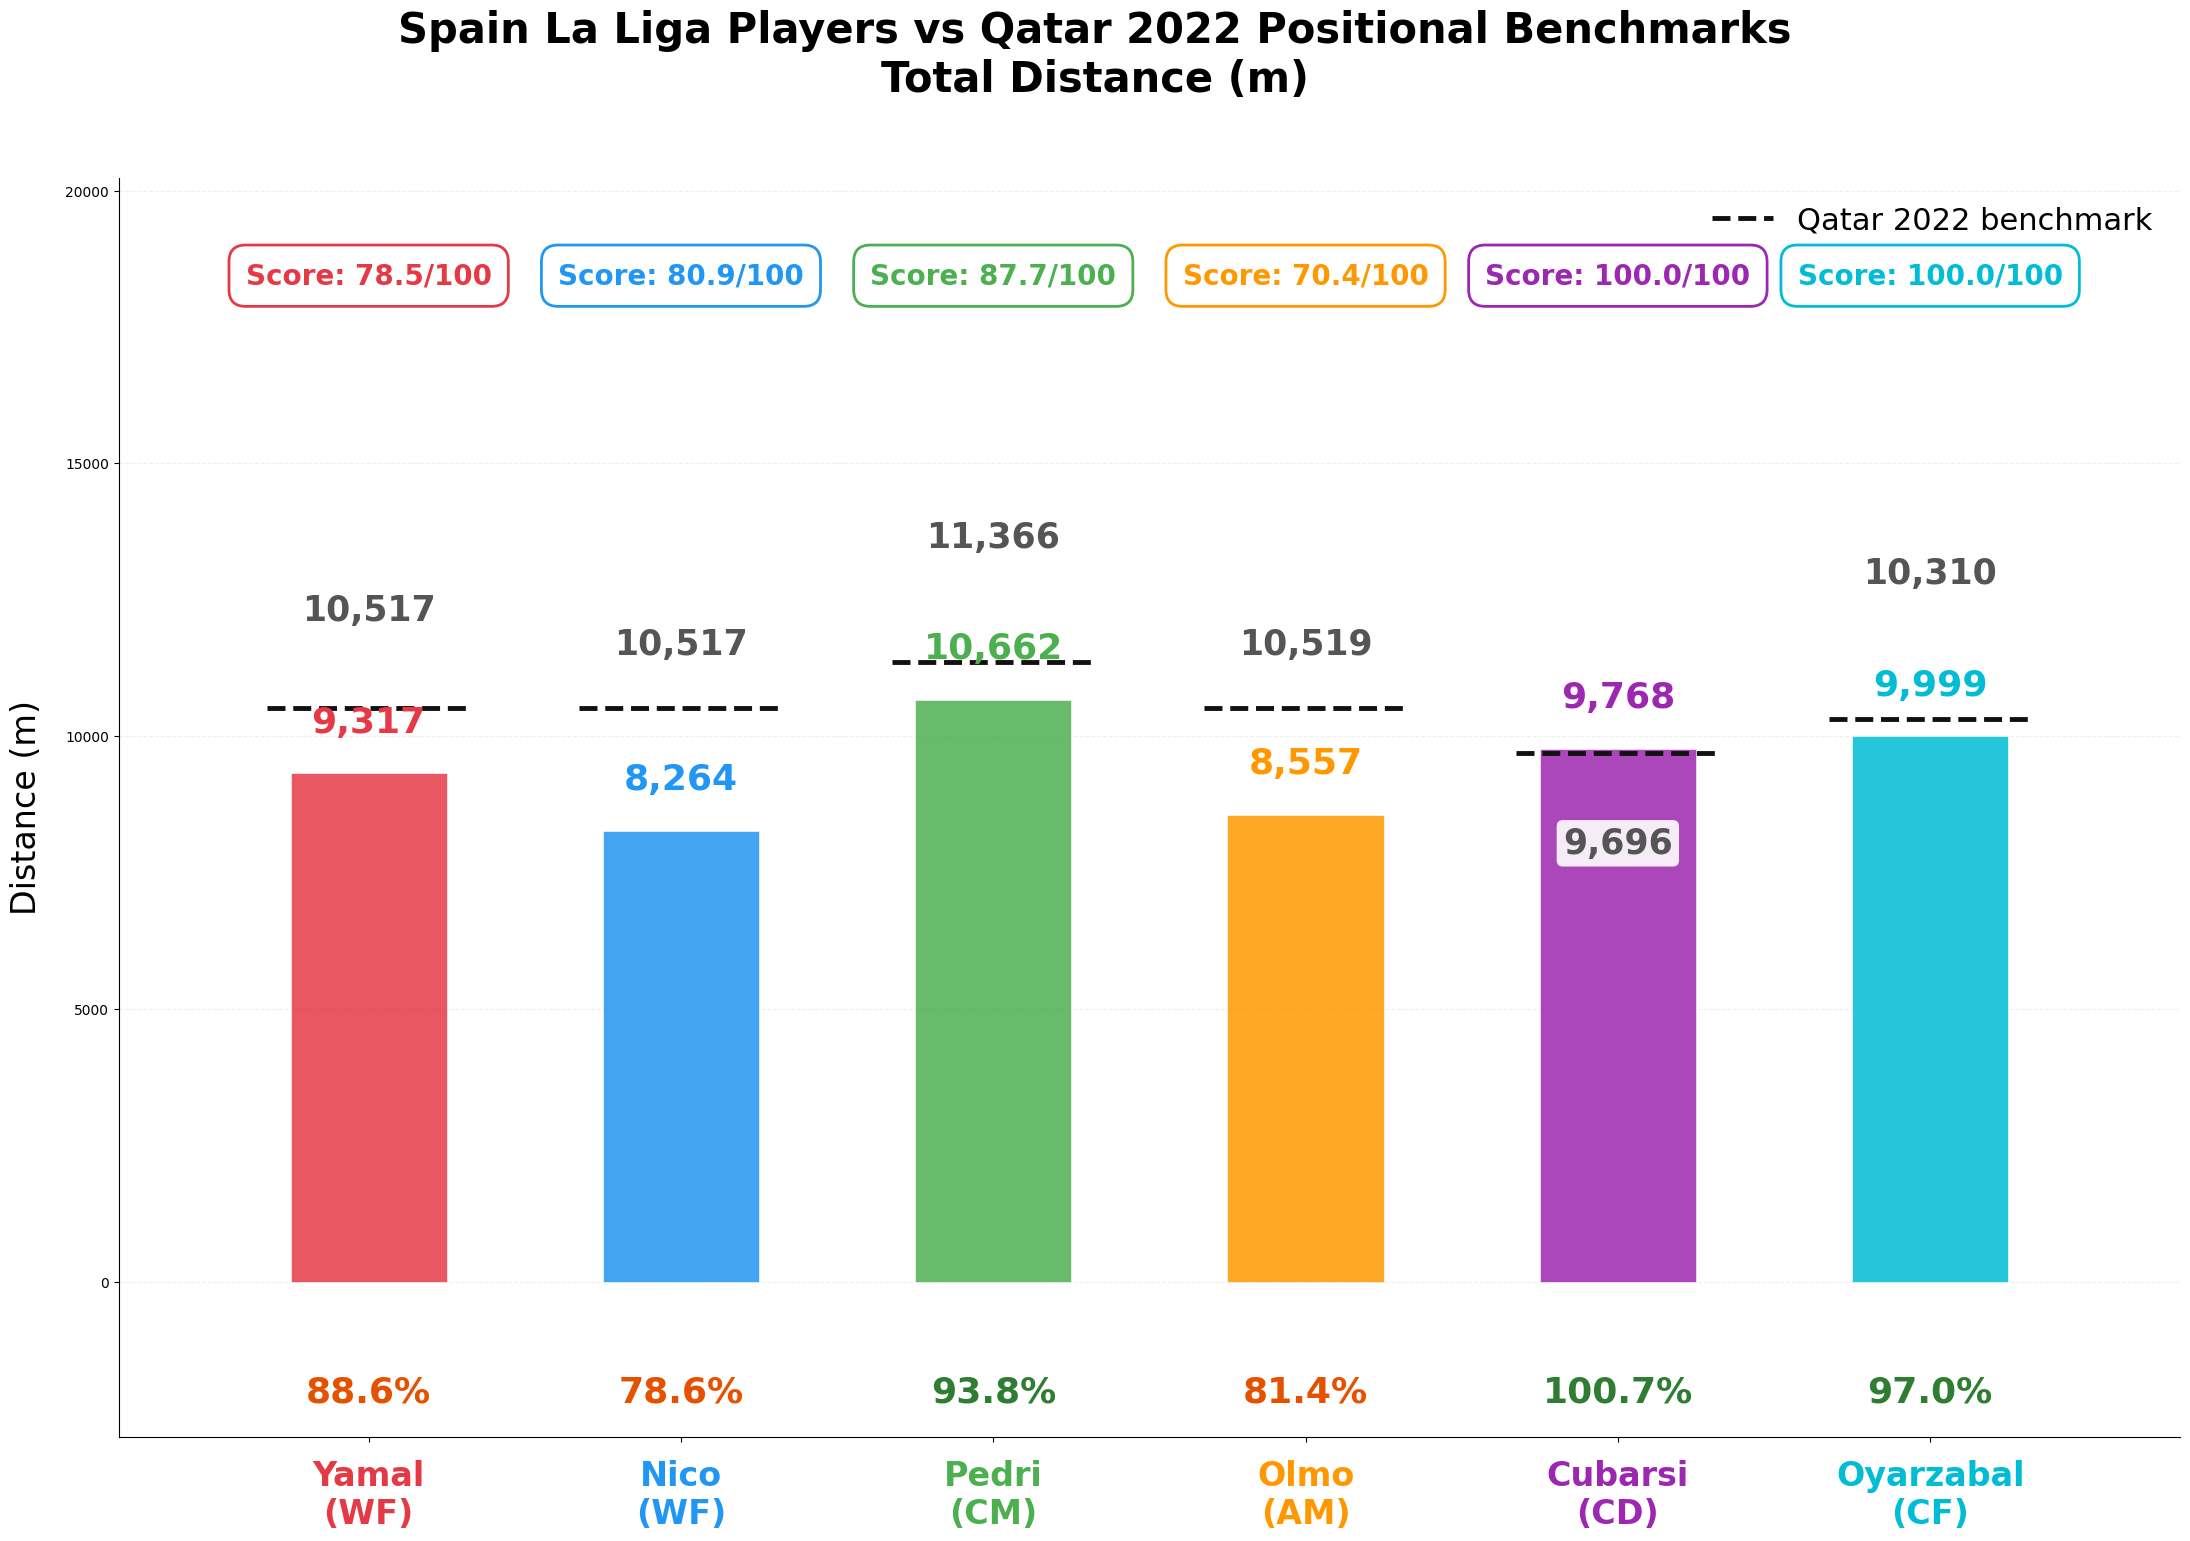

Saved: layer1_total_distance.png


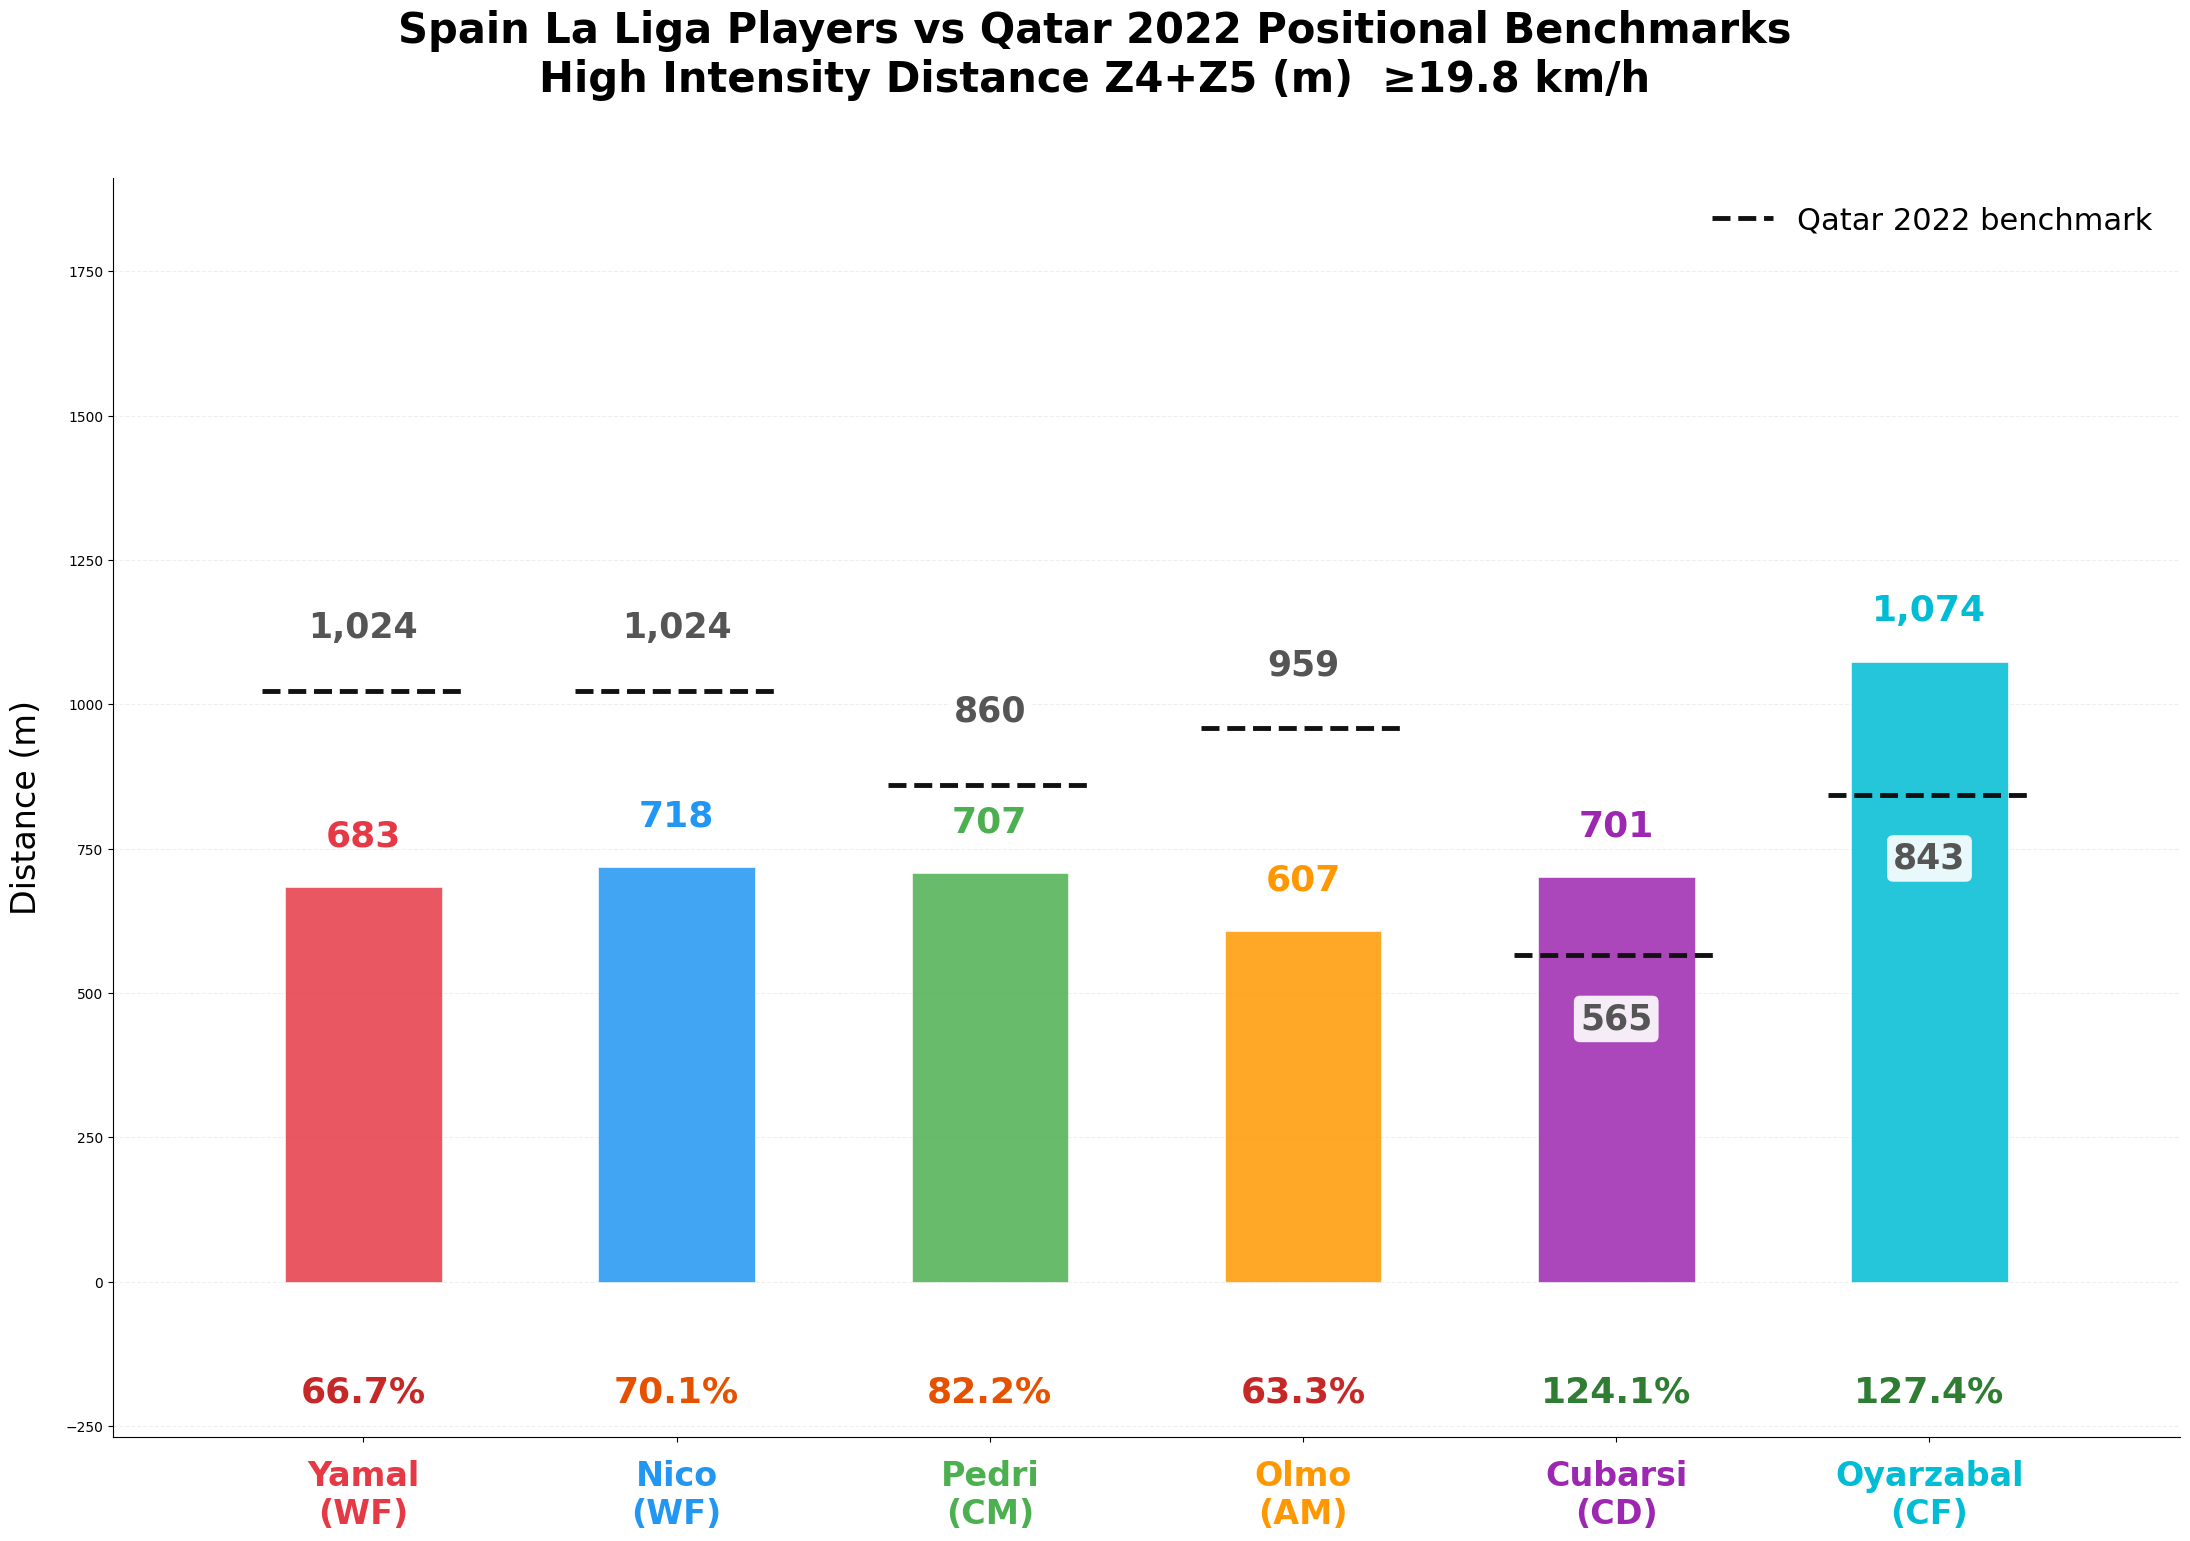

Saved: layer1_z4z5.png


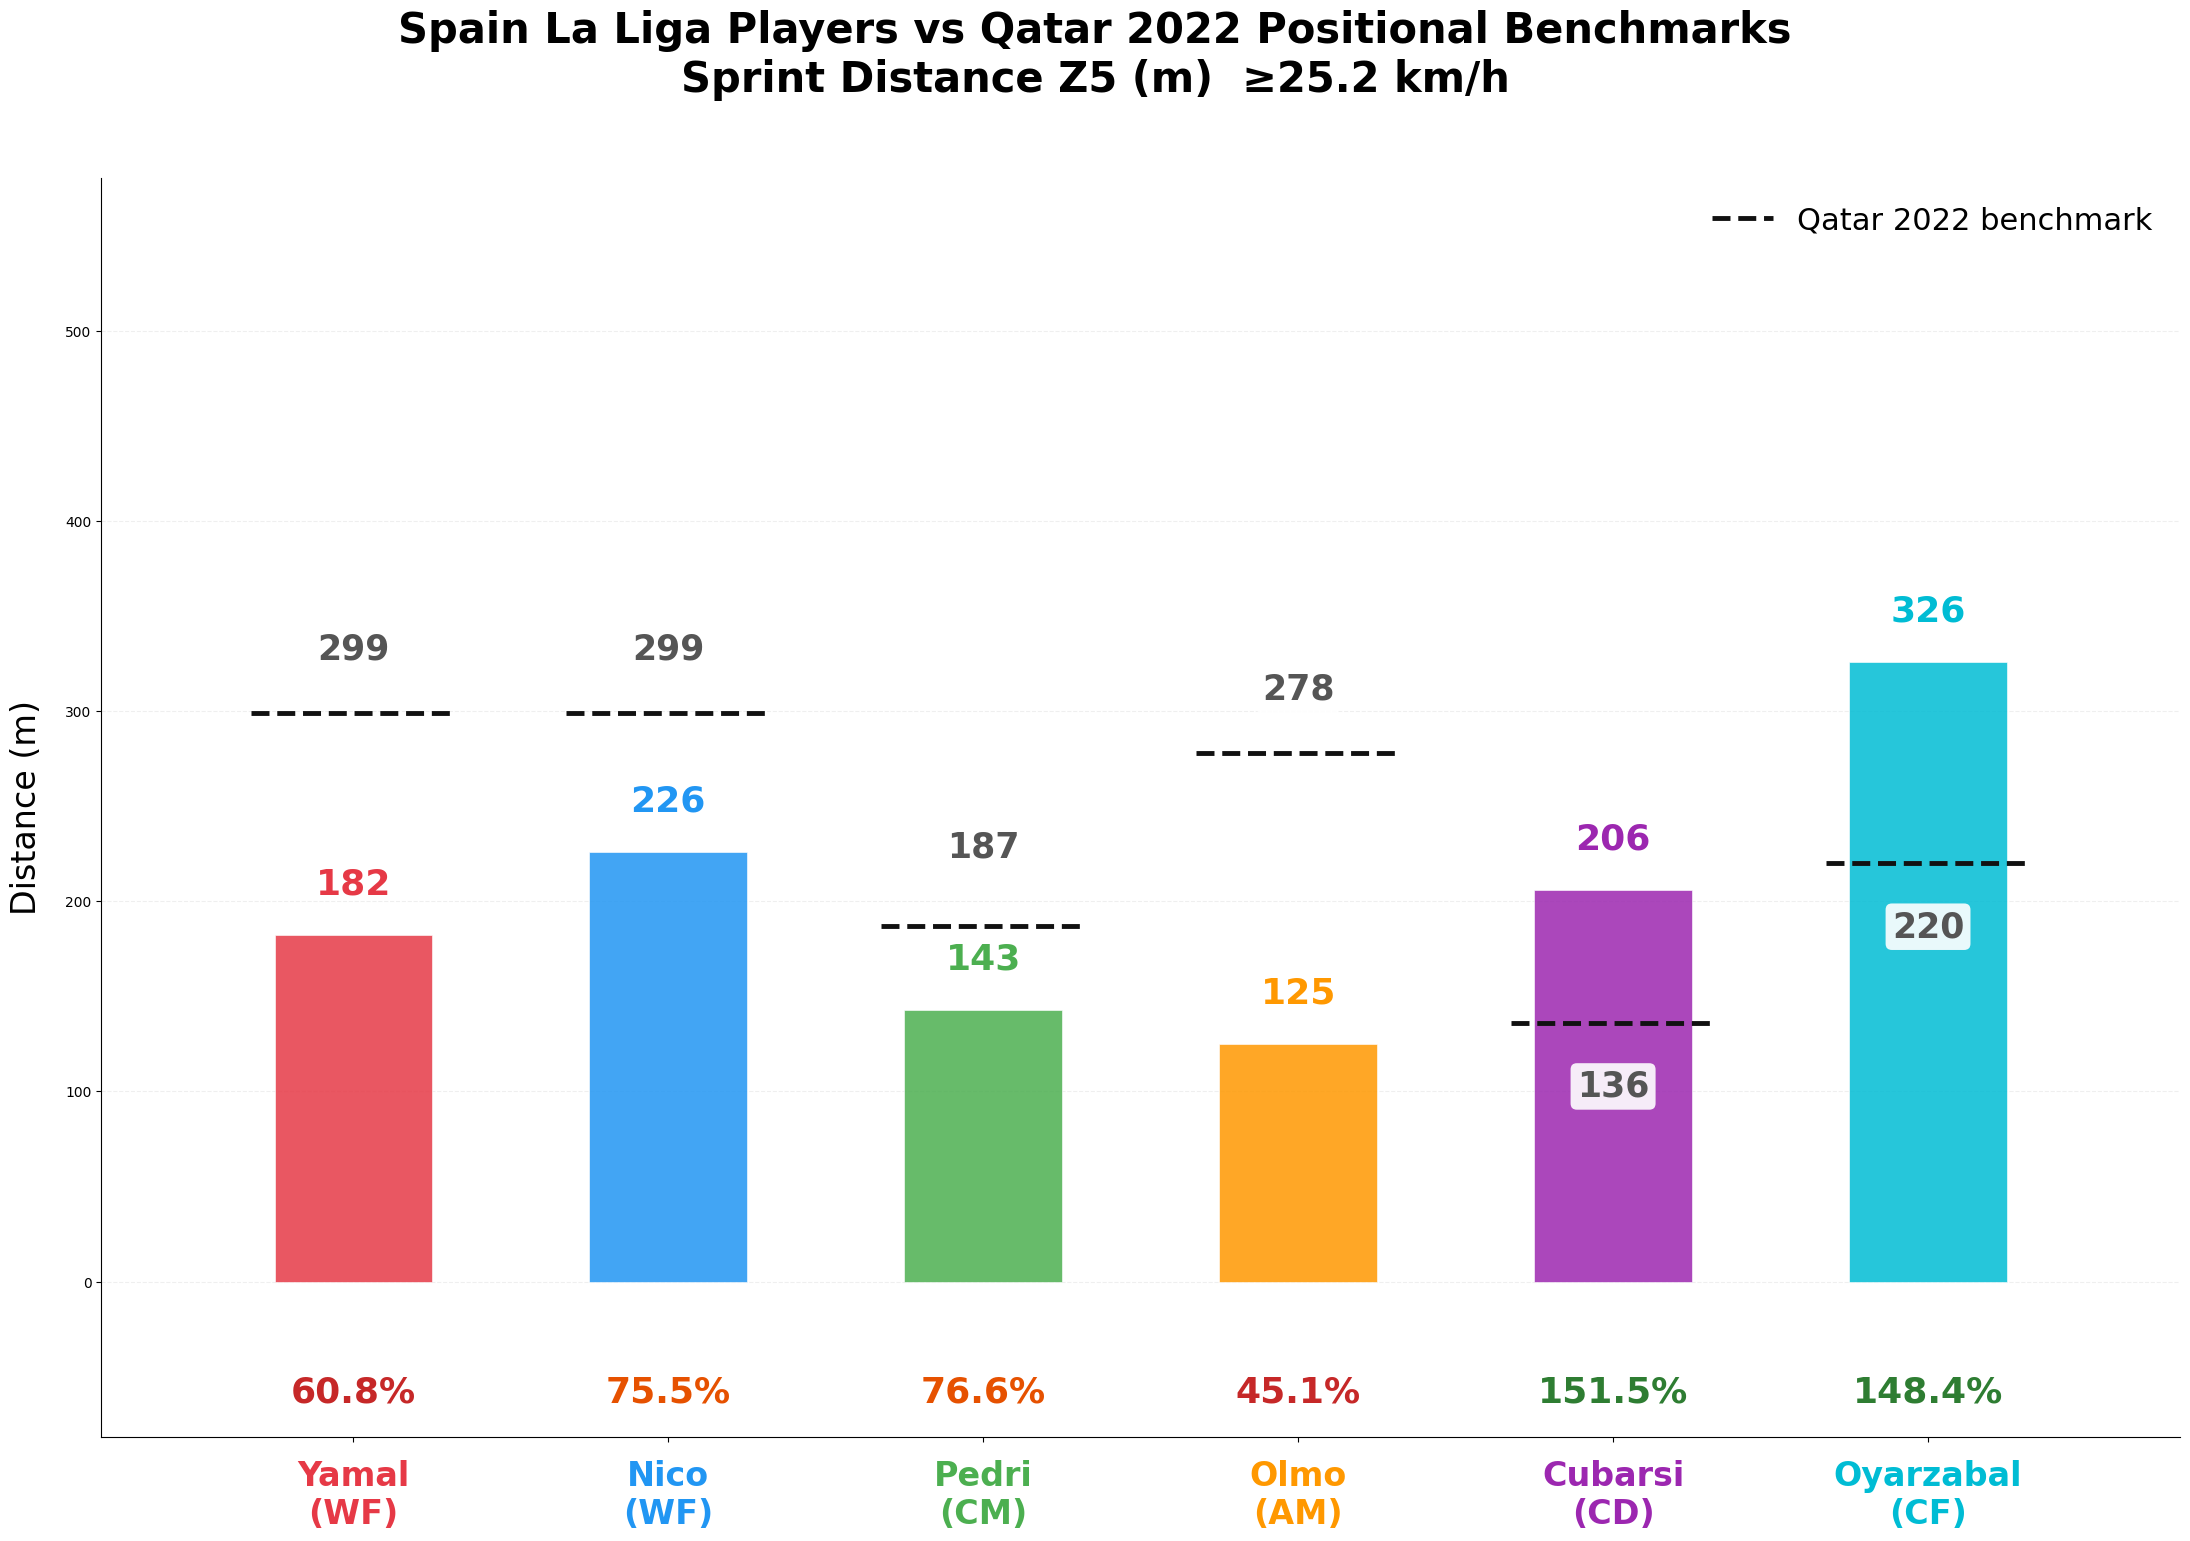

Saved: layer1_sprint.png


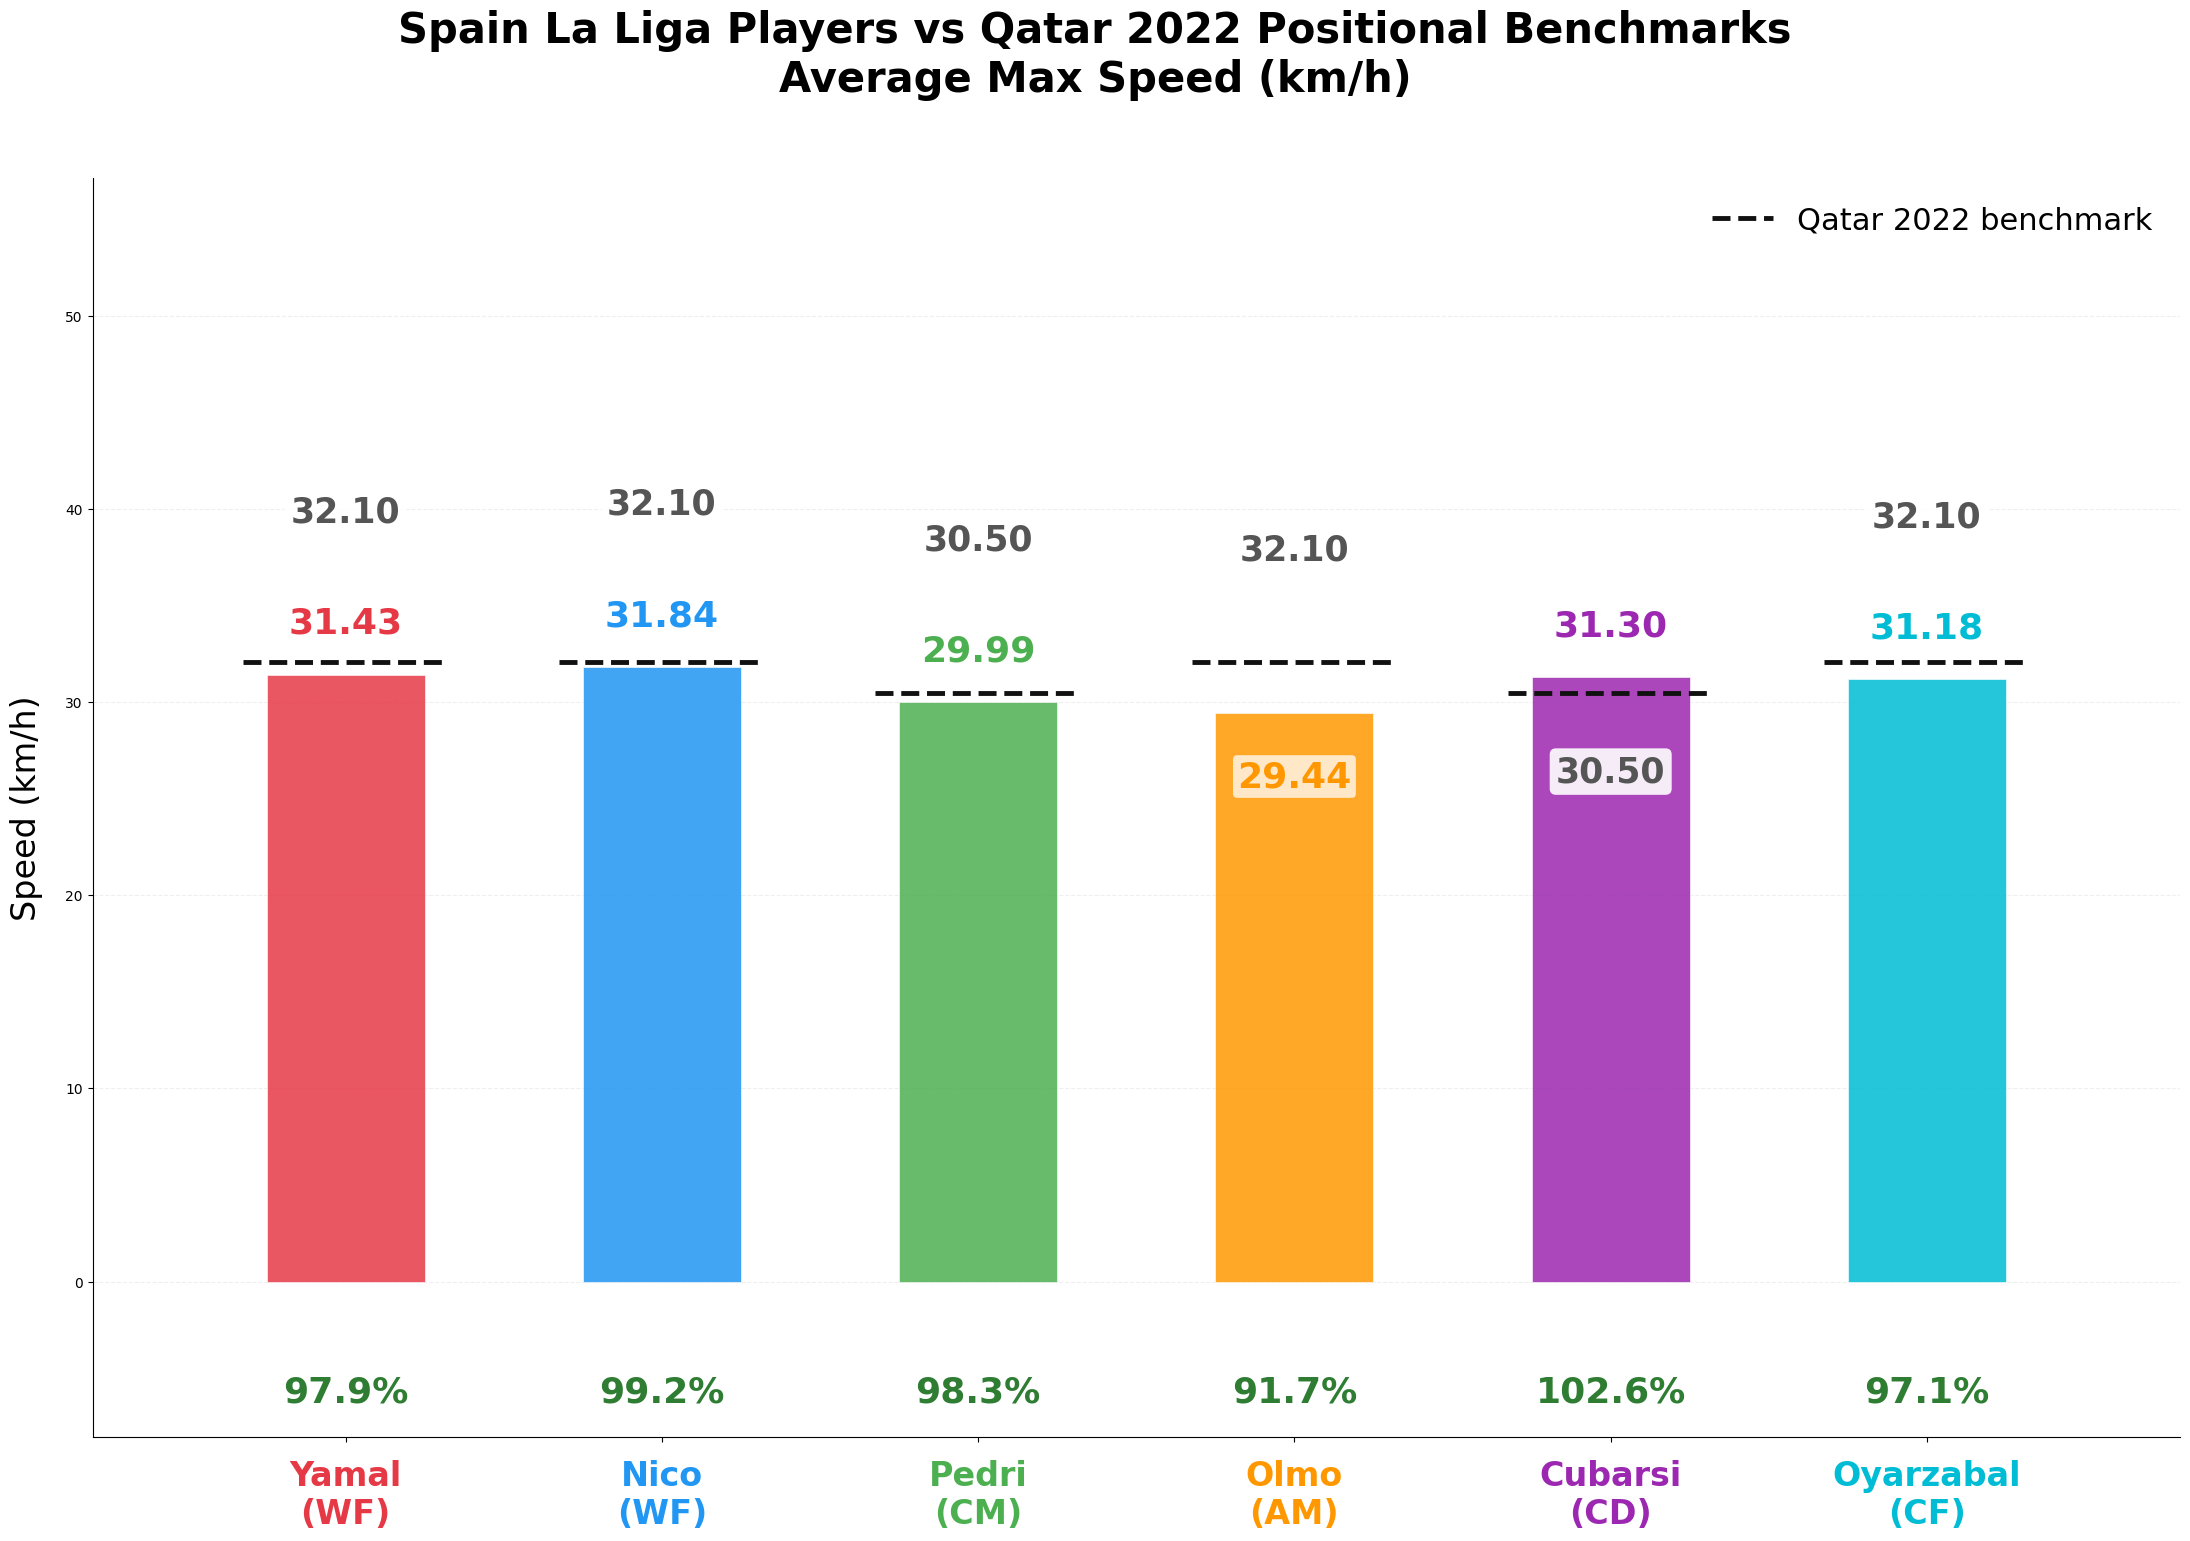

Saved: layer1_maxspeed.png


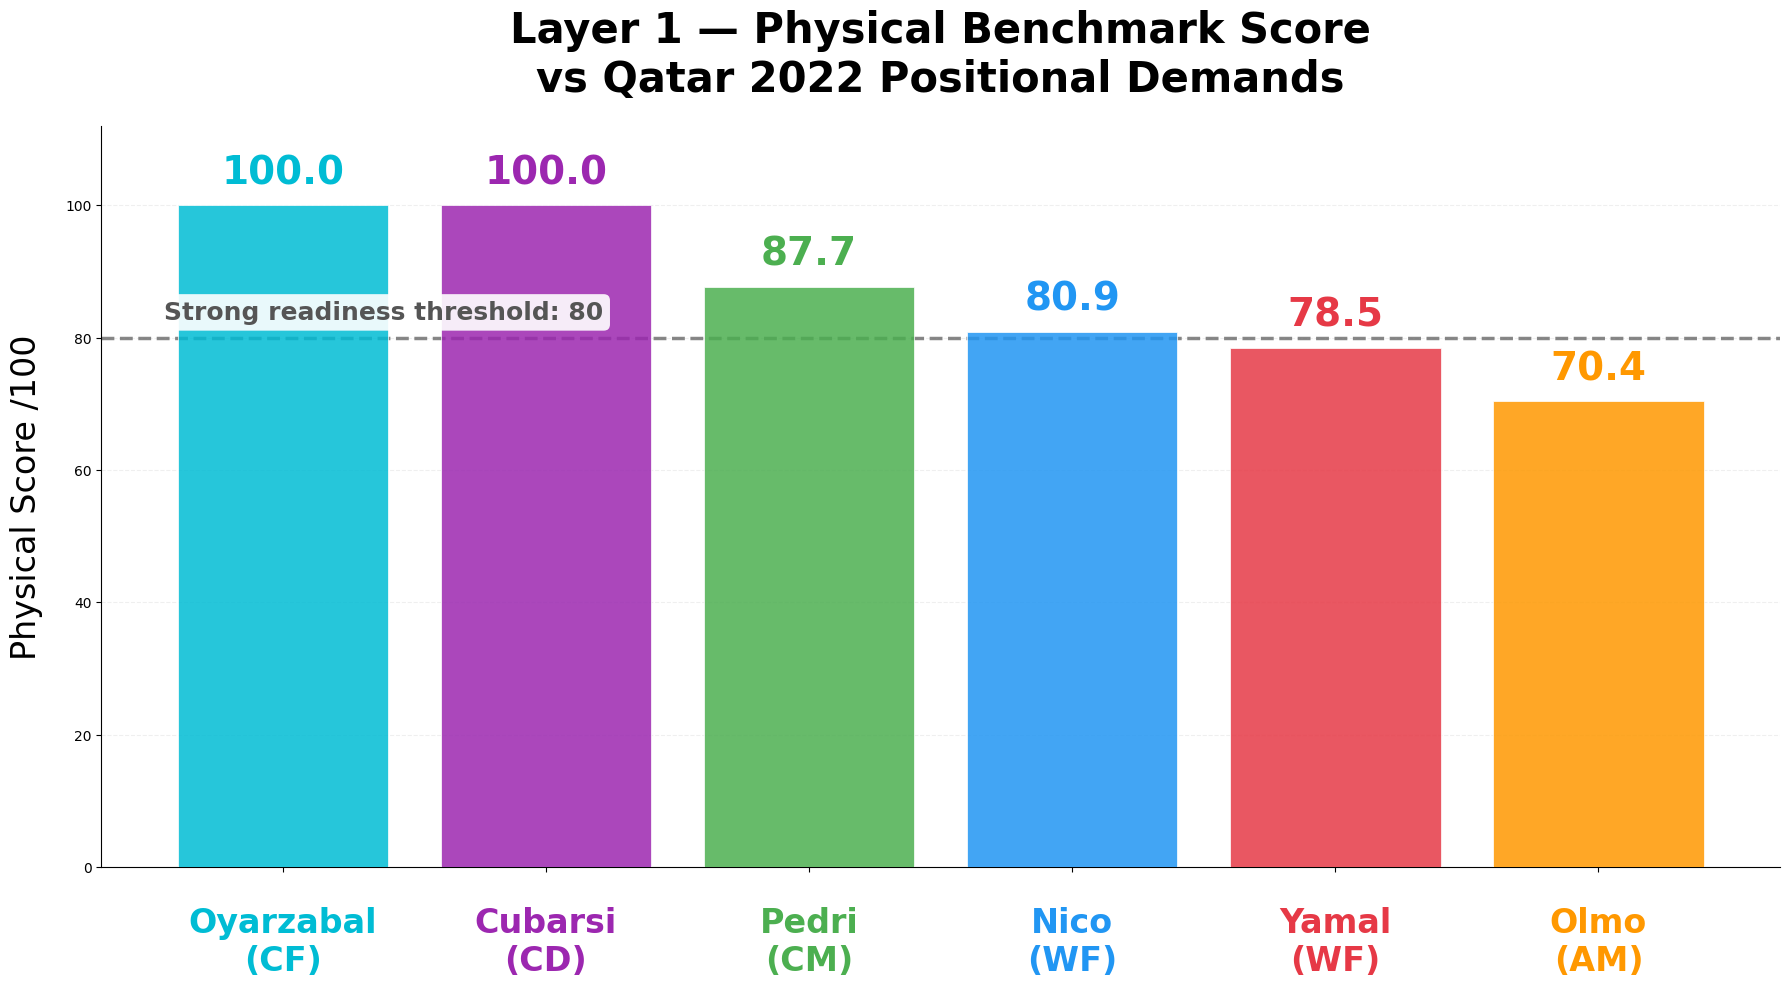

Saved: layer1_physical_score_ranking.png

All Layer 1 charts saved.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

players = ["Yamal", "Nico", "Pedri", "Olmo", "Cubarsi", "Oyarzabal"]
positions = ["WF", "WF", "CM", "AM", "CD", "CF"]
labels = [f"{p}\n({pos})" for p, pos in zip(players, positions)]

player_colors = [
    "#E63946", "#2196F3", "#4CAF50",
    "#FF9800", "#9C27B0", "#00BCD4"
]

physical_scores = [78.5, 80.9, 87.7, 70.4, 100.0, 100.0]

metrics = [
    ([9317, 8264, 10662, 8557, 9768, 9999],
     [10517, 10517, 11366, 10519, 9696, 10310],
     [88.6, 78.6, 93.8, 81.4, 100.7, 97.0],
     "Total Distance (m)", "Distance (m)", "layer1_total_distance.png"),

    ([683, 718, 707, 607, 701, 1074],
     [1024, 1024, 860, 959, 565, 843],
     [66.7, 70.1, 82.2, 63.3, 124.1, 127.4],
     "High Intensity Distance Z4+Z5 (m)  ≥19.8 km/h",
     "Distance (m)", "layer1_z4z5.png"),

    ([182, 226, 143, 125, 206, 326],
     [299, 299, 187, 278, 136, 220],
     [60.8, 75.5, 76.6, 45.1, 151.5, 148.4],
     "Sprint Distance Z5 (m)  ≥25.2 km/h",
     "Distance (m)", "layer1_sprint.png"),

    ([31.43, 31.84, 29.99, 29.44, 31.30, 31.18],
     [32.10, 32.10, 30.50, 32.10, 30.50, 32.10],
     [97.9, 99.2, 98.3, 91.7, 102.6, 97.1],
     "Average Max Speed (km/h)",
     "Speed (km/h)", "layer1_maxspeed.png"),
]

x = np.arange(len(players))
width = 0.5


def fmt_value(v, is_speed):
    return f"{v:.2f}" if is_speed else f"{v:,.0f}"


def pct_colour(p):
    if p >= 90:
        return "#2E7D32"
    elif p >= 70:
        return "#E65100"
    else:
        return "#C62828"


def get_label_positions(a, b, max_val):
    player_gap = max_val * 0.055
    bench_gap = max_val * 0.075
    min_separation = max_val * 0.18

    player_y = a + player_gap
    player_va = "bottom"

    if a >= b:
        bench_y = b - bench_gap
        bench_va = "top"

        if player_y - bench_y < min_separation:
            bench_y = player_y - min_separation
    else:
        bench_y = b + bench_gap
        bench_va = "bottom"

        if bench_y - player_y < min_separation:
            bench_y = player_y + min_separation

    return player_y, player_va, bench_y, bench_va


for metric_idx, (avg, bench, pcts, title, ylabel, filename) in enumerate(metrics):

    fig, ax = plt.subplots(figsize=(22, 16))

    is_speed = max(bench) < 100
    max_val = max(max(avg), max(bench))

    y_top = max_val * 1.78
    y_bottom = -max_val * 0.25

    fig.suptitle(
        f"Spain La Liga Players vs Qatar 2022 Positional Benchmarks\n{title}",
        fontsize=30,
        fontweight="bold",
        y=0.98
    )

    if metric_idx == 0:
        for i, (score, c) in enumerate(zip(physical_scores, player_colors)):
            ax.text(
                i,
                max_val * 1.60,
                f"Score: {score:.1f}/100",
                ha="center",
                va="bottom",
                fontsize=20,
                fontweight="bold",
                color=c,
                bbox=dict(
                    boxstyle="round,pad=0.6",
                    facecolor="white",
                    edgecolor=c,
                    linewidth=2.0
                )
            )

    for i, (a, b, p, c) in enumerate(zip(avg, bench, pcts, player_colors)):

        ax.bar(
            i,
            a,
            width,
            color=c,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.5,
            zorder=3
        )

        ax.plot(
            [i - width * 0.65, i + width * 0.65],
            [b, b],
            color="#111111",
            linewidth=3.5,
            linestyle="--",
            zorder=4
        )

        player_y, player_va, bench_y, bench_va = get_label_positions(a, b, max_val)

        # Manual fix for Olmo on Average Max Speed:
        # place player value inside/below bar, away from benchmark line.
        if title == "Average Max Speed (km/h)" and players[i] == "Olmo":
            player_y = a - max_val * 0.075
            player_va = "top"

        ax.text(
            i,
            player_y,
            fmt_value(a, is_speed),
            ha="center",
            va=player_va,
            fontsize=26,
            fontweight="bold",
            color=c,
            zorder=6,
            bbox=dict(
                boxstyle="round,pad=0.12",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            ) if title == "Average Max Speed (km/h)" and players[i] == "Olmo" else None
        )

        ax.text(
            i,
            bench_y,
            fmt_value(b, is_speed),
            ha="center",
            va=bench_va,
            fontsize=25,
            fontweight="bold",
            color="#555555",
            zorder=6,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.9
            )
        )

        ax.text(
            i,
            y_bottom * 0.60,
            f"{p:.1f}%",
            ha="center",
            va="top",
            fontsize=26,
            fontweight="bold",
            color=pct_colour(p),
            zorder=5
        )

    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.tick_params(axis="x", pad=22)

    for i, (lbl, c) in enumerate(zip(labels, player_colors)):
        ax.text(
            i,
            y_bottom * 1.15,
            lbl,
            ha="center",
            va="top",
            fontsize=24,
            fontweight="bold",
            color=c
        )

    ax.set_ylabel(ylabel, fontsize=24, labelpad=16)
    ax.set_ylim(bottom=y_bottom, top=y_top)
    ax.set_xlim(-0.8, len(players) - 0.2)

    ax.grid(axis="y", alpha=0.2, linestyle="--", zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_elements = [
        plt.Line2D(
            [0],
            [0],
            color="#111111",
            linewidth=3.5,
            linestyle="--",
            label="Qatar 2022 benchmark"
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=22,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {filename}")


# Physical Score Ranking Chart

score_order = np.argsort(physical_scores)[::-1]

sorted_labels = [f"{players[i]}\n({positions[i]})" for i in score_order]
sorted_scores = [physical_scores[i] for i in score_order]
sorted_colors = [player_colors[i] for i in score_order]

fig, ax = plt.subplots(figsize=(18, 10))

x_score = np.arange(len(sorted_scores))

ax.bar(
    x_score,
    sorted_scores,
    color=sorted_colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.6,
    zorder=3
)

for i, (score, c) in enumerate(zip(sorted_scores, sorted_colors)):
    ax.text(
        i,
        score + 2,
        f"{score:.1f}",
        ha="center",
        va="bottom",
        fontsize=28,
        fontweight="bold",
        color=c
    )

ax.set_title(
    "Layer 1 — Physical Benchmark Score\nvs Qatar 2022 Positional Demands",
    fontsize=30,
    fontweight="bold",
    pad=25
)

ax.set_ylabel("Physical Score /100", fontsize=24, labelpad=16)
ax.set_ylim(0, 112)

ax.set_xticks(x_score)
ax.set_xticklabels([])

for i, (lbl, c) in enumerate(zip(sorted_labels, sorted_colors)):
    ax.text(
        i,
        -6,
        lbl,
        ha="center",
        va="top",
        fontsize=24,
        fontweight="bold",
        color=c
    )

ax.axhline(
    80,
    color="#555555",
    linestyle="--",
    linewidth=2.5,
    alpha=0.7,
    zorder=2
)

ax.text(
    -0.45,
    82.0,
    "Strong readiness threshold: 80",
    ha="left",
    va="bottom",
    fontsize=18,
    fontweight="bold",
    color="#555555",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        alpha=0.9
    )
)

ax.grid(axis="y", alpha=0.2, linestyle="--", zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("layer1_physical_score_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: layer1_physical_score_ranking.png")
print("\nAll Layer 1 charts saved.")

The Physical score ranking combines the four benchmark comparisons into a single score out of 100. Higher scores indicate greater alignment with the positional physical demands observed at Qatar 2022.

This provides an overall measure of tournament-level physical preparedness while preserving the positional context established by Bradley's benchmarks.

In [ ]:
# Save Layer 1 complete dataframe
df_complete.to_csv('layer1_physical_profile.csv', index=False)

# Confirm save
print("Layer 1 data saved to layer1_physical_profile.csv")
print(f"Rows: {len(df_complete)}")
print(f"Columns: {list(df_complete.columns)}")
print("\nPhysical Benchmark Scores:")
for _, row in df_complete.iterrows():
    print(f"  {row['Player']}: {row['Physical Score (/100)']}/100")

Layer 1 data saved to layer1_physical_profile.csv
Rows: 6
Columns: ['Player', 'Position', 'Games', 'Avg Total (m)', 'Qatar 2022 Total (m)', '% Total', 'CV Total (%)', 'Avg HSR only (m)', 'Avg Z4+Z5 (m)', 'Qatar 2022 Z4+Z5 (m)', '% Z4+Z5', 'CV Z4+Z5 (%)', 'Avg Sprint (m)', 'Qatar 2022 Sprint (m)', '% Sprint', 'CV Sprint (%)', 'Avg HSR Qty', 'Avg Sprint Qty', 'Avg Max Speed (km/h)', 'Qatar 2022 Max Speed (km/h)', '% Max Speed', 'Peak Max Speed (km/h)', 'Physical Score (/100)']

Physical Benchmark Scores:
  Lamine Yamal: 78.5/100
  Nico Williams: 80.9/100
  Pedri: 87.7/100
  Dani Olmo: 70.4/100
  Pau Cubarsi: 100.0/100
  Mikel Oyarzabal: 100.0/100


### Layer 1 Key Findings

The physical benchmarking reveals a generally positive picture for Spain's core group of La Liga internationals. Five of the six players analysed achieved scores above 75, suggesting that their domestic physical output is broadly consistent with the demands observed at Qatar 2022.

Cubarsi and Oyarzabal were the standout performers, meeting or exceeding the positional benchmarks across all measured variables and achieving the maximum Physical Readiness Score. Pedri also performed strongly, producing a profile that closely matches the physical demands of elite international midfielders.

Nico Williams and Lamine Yamal recorded solid scores, although both remained slightly below the World Cup benchmarks for high-intensity and sprint distance. This is not necessarily surprising given their roles and the tactical context in which they operate at club level.

Dani Olmo produced the lowest score in the sample, primarily due to lower high-intensity and sprint outputs relative to the attacking midfielder benchmark. However, his score should be interpreted as a relative comparison against World Cup standards rather than an assessment of overall quality or importance to Spain.

Overall, the findings suggest that the majority of the sample already possess the physical capacity required to compete at World Cup level, providing a strong foundation for the second layer of the analysis.


In [ ]:
import requests
import json
import time
from urllib.parse import quote

API_TOKEN = ""
BASE_URL = "https://apidriblab.com"

# Encode token to handle special characters
headers = {
    "Authorization": f"Bearer {API_TOKEN.strip()}"
}

# Test connection
response = requests.get(
    f"{BASE_URL}/countries",
    headers=headers
)
print(f"Status: {response.status_code}")
print(f"Response: {response.text[:200]}")

Status: 200
Response: {"statusCode":200,"body":[{"id":1,"name":"Spain","code":"es","alpha3code":"ESP"},{"id":2,"name":"England","code":"gb-eng","alpha3code":"XEN"},{"id":3,"name":"Germany","code":"de","alpha3code":"DEU"},{


In [ ]:
# Confirm session is active
test = call_api("/countries")
if test:
    print("Session active. Ready for Layer 2.")
else:
    print("Session expired. Refresh token.")

Session active. Ready for Layer 2.


# Layer 2 — Spain Physical Identity Fit Score

## What this code does

Calculates how closely each player's La Liga
physical profile aligns with Spain's specific
physical identity at Qatar 2022.

## Why this is different from Layer 1

Layer 1 compared each player against the average
World Cup player in their position across all
32 teams. Layer 2 narrows the lens to Spain
specifically — not what the average wide forward
produced at Qatar 2022 but what a Spain wide
forward would be expected to produce given
Spain's confirmed physical identity.

## How we build Spain-specific estimated positional benchmarks

This is the methodological connection between
the two Bradley papers.

Part 1 gives us positional benchmarks — what
the average wide forward, central midfielder
and centre back produced physically at Qatar
2022 across all 32 teams.

Part 2 gives us Spain's physical ratios —
how Spain compared to the tournament average:

Total Distance ratio: 107,700 / 108,100 = 0.996
Z4+Z5 ratio: 8,716 / 9,001 = 0.968
Sprint ratio: 2,149 / 2,345 = 0.916

We multiply the Part 1 positional benchmarks
by Spain's Part 2 ratios. This produces
Spain-adjusted positional benchmarks — not the
average Qatar 2022 wide forward standard, not
Spain's generic team average, but what a Spain
wide forward would be expected to produce
given Spain's confirmed physical identity.

For example — the wide forward Z4+Z5 benchmark
from Part 1 is 1,024m. Multiplying by Spain's
Z4+Z5 ratio of 0.968 gives 991m. That is the
Spain-adjusted wide forward Z4+Z5 benchmark
used in Layer 2.

This approach uses both papers simultaneously —
Part 1 for positional precision, Part 2 for
Spain specificity. It is the original
methodological contribution of Layer 2.

This method does not attempt to reconstruct
Spain's exact positional outputs at Qatar 2022.
Instead, it estimates Spain-adjusted positional
expectations by applying Spain's team-level
physical profile to Bradley's positional
benchmarks. The objective is to preserve
positional differences while accounting for
Spain's distinctive physical identity.


## The three metrics

Total Distance, Z4+Z5 Combined and Sprint
Distance — the same three metrics Bradley
presents as team benchmarks in Part 2. Max
Speed is excluded from Layer 2 because it
is a positional individual metric from Part 1
not a team identity metric from Part 2.
Keeping Layer 2 clean to Part 2's framework
maintains methodological separation between
the two layers.

## Scoring method

Each player's La Liga per 90 average is
expressed as a percentage of their
position-specific Spain benchmark. The three
percentages are averaged and capped at 100.

Score = (% Total + % Z4+Z5 + % Sprint) / 3
Capped at 100.

## Limitation

Spain's team-level ratios are applied uniformly across positions.
This assumes that Spain's physical identity influenced each position
proportionally. While this preserves positional differences from
Part 1, true position-specific Spain outputs are unavailable in
Part 2 and therefore cannot be directly verified.

In [ ]:
import pandas as pd
import numpy as np
import time

# Spain Qatar 2022 physical ratios from Part 2
# Spain team totals vs tournament averages
# Total: 107,700 / 108,100 = 0.996
# Z4+Z5: 8,716 / 9,001 = 0.968
# Sprint: 2,149 / 2,345 = 0.916

spain_ratios = {
    "total": 107700 / 108100,
    "z4z5":  8716 / 9001,
    "sprint": 2149 / 2345
}

# Part 1 positional benchmarks
part1_benchmarks = {
    "WF": {"total": 10517, "z4z5": 1024, "sprint": 299},
    "CM": {"total": 11366, "z4z5": 860,  "sprint": 187},
    "AM": {"total": 10519, "z4z5": 959,  "sprint": 278},
    "CD": {"total": 9696,  "z4z5": 565,  "sprint": 136},
    "CF": {"total": 10310, "z4z5": 843,  "sprint": 220}
}

# Spain adjusted positional benchmarks
# Part 1 benchmark × Spain ratio
spain_benchmarks = {}
for pos, metrics in part1_benchmarks.items():
    spain_benchmarks[pos] = {
        "total": round(metrics["total"] * spain_ratios["total"]),
        "z4z5":  round(metrics["z4z5"]  * spain_ratios["z4z5"]),
        "sprint": round(metrics["sprint"] * spain_ratios["sprint"])
    }

print("Spain-adjusted positional benchmarks:")
for pos, vals in spain_benchmarks.items():
    print(f"  {pos}: Total={vals['total']}m, Z4+Z5={vals['z4z5']}m, Sprint={vals['sprint']}m")

# Confirmed player details
player_details = {
    "Lamine Yamal":    {"id": 1776309, "team_id": 4279, "position": "WF", "minutes": 2563},
    "Nico Williams":   {"id": 1533082, "team_id": 5543, "position": "WF", "minutes": 1819},
    "Pedri":           {"id": 1477163, "team_id": 4279, "position": "CM", "minutes": 2377},
    "Dani Olmo":       {"id": 1221869, "team_id": 4279, "position": "AM", "minutes": 2306},
    "Pau Cubarsi":     {"id": 1746425, "team_id": 4279, "position": "CD", "minutes": 3049},
    "Mikel Oyarzabal": {"id": 273054,  "team_id": 5543, "position": "CF", "minutes": 3046}
}

season_id = 818687
all_players_layer2 = []

for player_name, details in player_details.items():

    physical_data = call_api(
        f"/player/{details['id']}/season/{season_id}/physical-stats"
    )

    if not physical_data:
        print(f"No data for {player_name}")
        continue

    rows = []
    for game in physical_data:
        hsr = game['stats']['distance']['hsrDistance']
        sprint = game['stats']['distance']['sprintDistance']
        rows.append({
            'total_distance': game['stats']['distance']['totalDistance'],
            'hsr_z4z5': hsr + sprint,
            'sprint_distance': sprint
        })

    df = pd.DataFrame(rows)

    # Player specific threshold — 70% of personal median
    median_dist = df['total_distance'].median()
    threshold = median_dist * 0.70
    df_full = df[df['total_distance'] >= threshold]

    # Season averages
    avg_total = df_full['total_distance'].mean()
    avg_z4z5 = df_full['hsr_z4z5'].mean()
    avg_sprint = df_full['sprint_distance'].mean()

    # Spain adjusted benchmarks for this position
    bench = spain_benchmarks[details['position']]

    # Percentage vs Spain benchmark
    pct_total  = (avg_total  / bench['total'])  * 100
    pct_z4z5   = (avg_z4z5   / bench['z4z5'])   * 100
    pct_sprint = (avg_sprint / bench['sprint']) * 100

    # Spain Identity Fit Score — capped at 100
    raw_score = (pct_total + pct_z4z5 + pct_sprint) / 3
    identity_score = min(round(raw_score, 1), 100)

    all_players_layer2.append({
        'Player': player_name,
        'Position': details['position'],
        'Games': len(df_full),
        'Avg Total (m)': round(avg_total),
        'Spain Total (m)': bench['total'],
        '% Total': round(pct_total, 1),
        'Avg Z4+Z5 (m)': round(avg_z4z5),
        'Spain Z4+Z5 (m)': bench['z4z5'],
        '% Z4+Z5': round(pct_z4z5, 1),
        'Avg Sprint (m)': round(avg_sprint),
        'Spain Sprint (m)': bench['sprint'],
        '% Sprint': round(pct_sprint, 1),
        'Spain Identity Fit Score': identity_score
    })

    print(f"\n{player_name} ({details['position']}) — {len(df_full)} games")
    print(f"  Total:   {round(avg_total)}m vs {bench['total']}m ({round(pct_total,1)}%)")
    print(f"  Z4+Z5:   {round(avg_z4z5)}m vs {bench['z4z5']}m ({round(pct_z4z5,1)}%)")
    print(f"  Sprint:  {round(avg_sprint)}m vs {bench['sprint']}m ({round(pct_sprint,1)}%)")
    print(f"  SPAIN IDENTITY FIT SCORE: {identity_score}/100")

    time.sleep(3)

df_layer2 = pd.DataFrame(all_players_layer2)
print("\n\nLayer 2 Summary Table:")
print(df_layer2.to_string(index=False))

Spain-adjusted positional benchmarks:
  WF: Total=10478m, Z4+Z5=992m, Sprint=274m
  CM: Total=11324m, Z4+Z5=833m, Sprint=171m
  AM: Total=10480m, Z4+Z5=929m, Sprint=255m
  CD: Total=9660m, Z4+Z5=547m, Sprint=125m
  CF: Total=10272m, Z4+Z5=816m, Sprint=202m

Lamine Yamal (WF) — 24 games
  Total:   9317m vs 10478m (88.9%)
  Z4+Z5:   683m vs 992m (68.9%)
  Sprint:  182m vs 274m (66.4%)
  SPAIN IDENTITY FIT SCORE: 74.7/100

Nico Williams (WF) — 18 games
  Total:   8264m vs 10478m (78.9%)
  Z4+Z5:   718m vs 992m (72.4%)
  Sprint:  226m vs 274m (82.4%)
  SPAIN IDENTITY FIT SCORE: 77.9/100

Pedri (CM) — 20 games
  Total:   10662m vs 11324m (94.2%)
  Z4+Z5:   707m vs 833m (84.8%)
  Sprint:  143m vs 171m (83.7%)
  SPAIN IDENTITY FIT SCORE: 87.6/100

Dani Olmo (AM) — 24 games
  Total:   8557m vs 10480m (81.7%)
  Z4+Z5:   607m vs 929m (65.4%)
  Sprint:  125m vs 255m (49.2%)
  SPAIN IDENTITY FIT SCORE: 65.4/100

Pau Cubarsi (CD) — 29 games
  Total:   9768m vs 9660m (101.1%)
  Z4+Z5:   701m vs 547m

## Output Explanation - Layer 2 Spain Physical Identity Fit Score

The score should be interpreted as a measure of alignment rather than performance. A high score indicates that a player's physical output resembles the profile associated with Spain's Qatar 2022 World Cup campaign, while a lower score suggests a weaker match with that specific identity.

Because the score is based on Spain-adjusted positional benchmarks, players are evaluated relative to the physical demands expected from their position within Spain's playing style rather than against a generic World Cup standard.

The charts below allow us to compare how closely each player matches Spain's physical profile and identify which players appear most naturally suited to the demands of Spain's international game model.


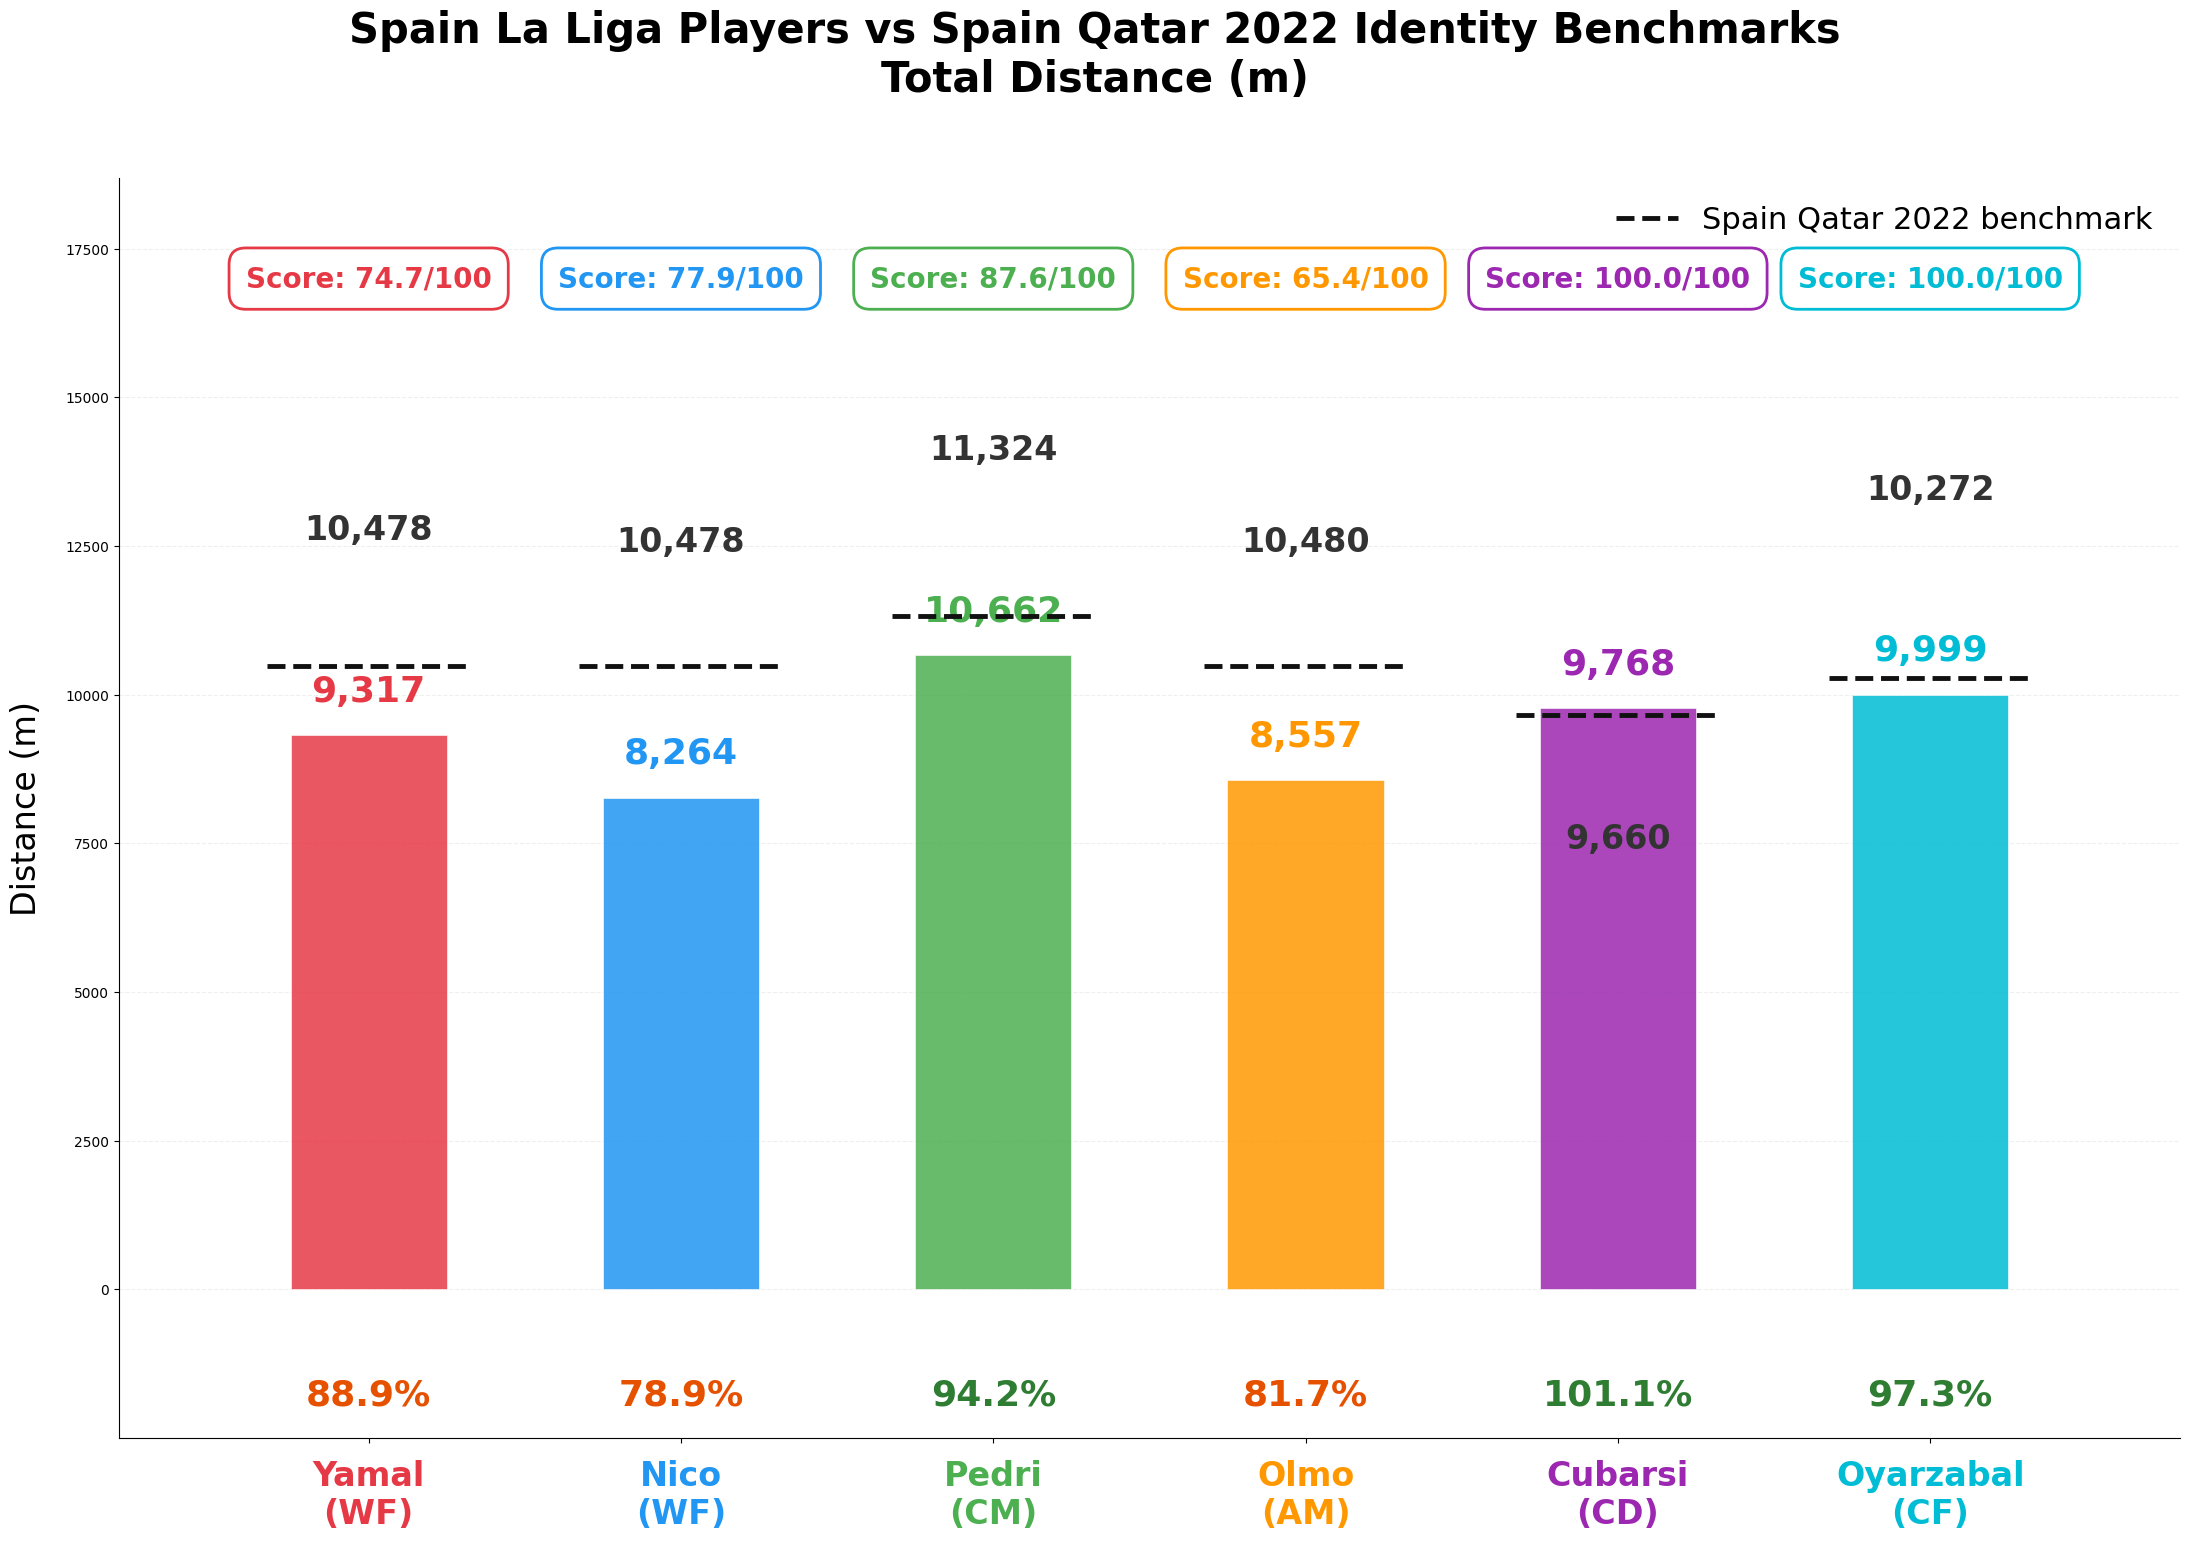

Saved: layer2_total_distance.png


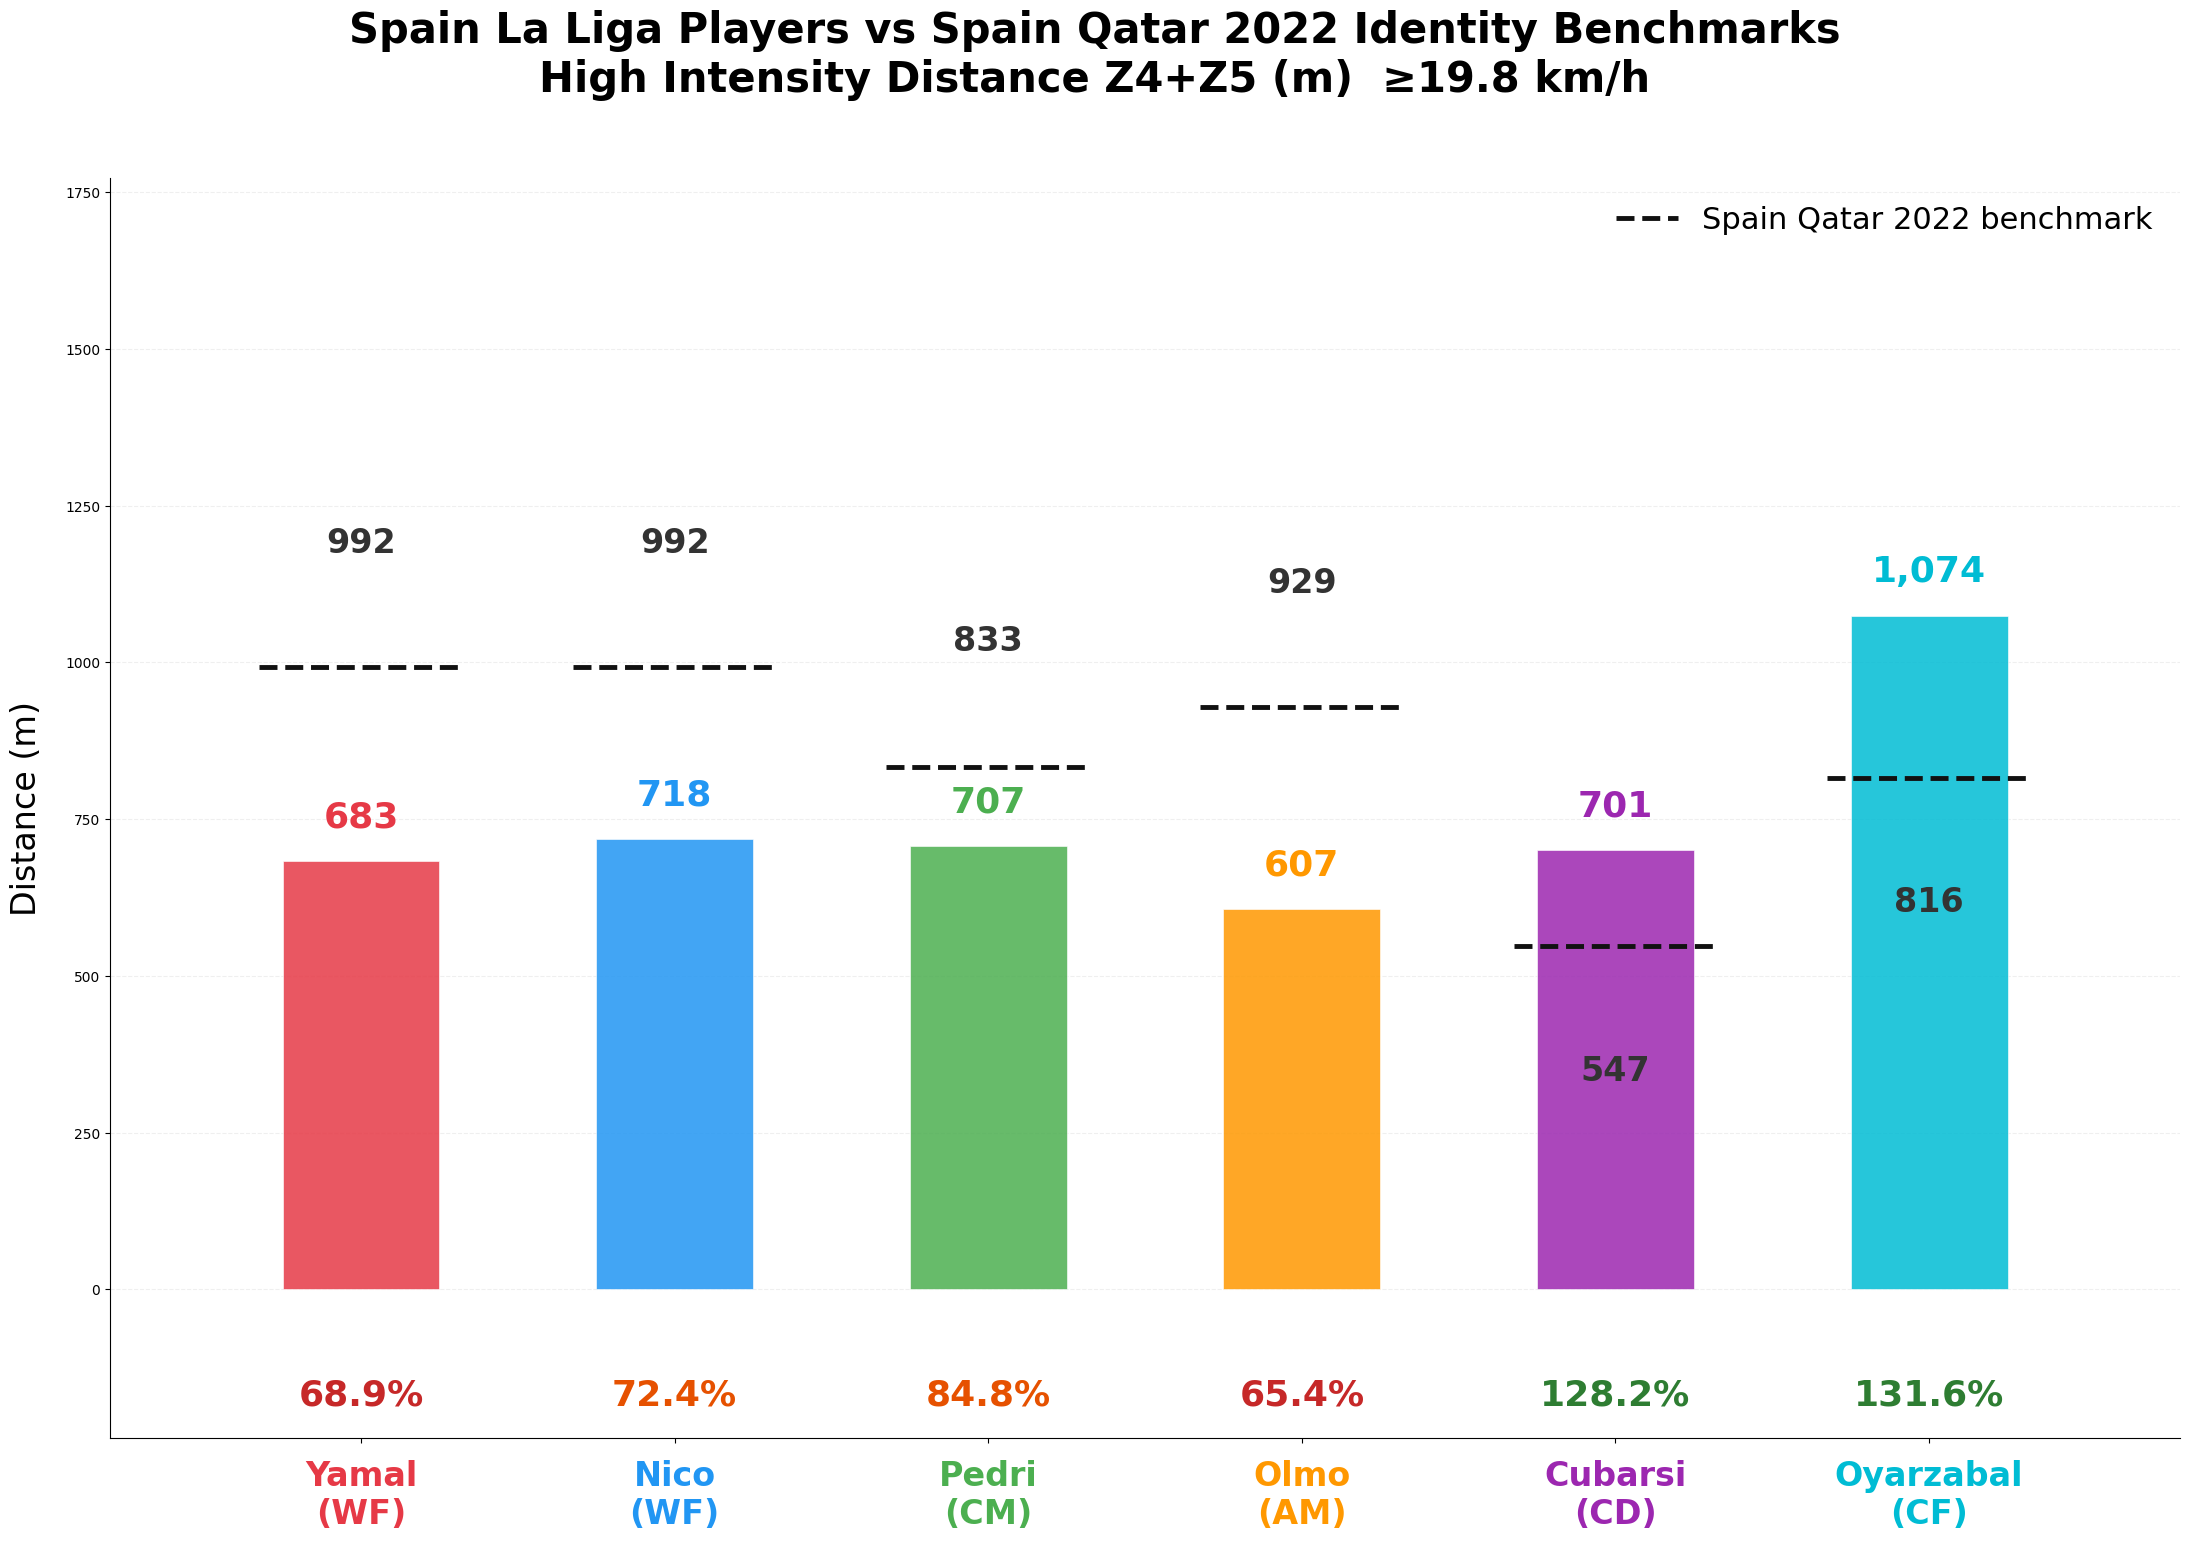

Saved: layer2_z4z5.png


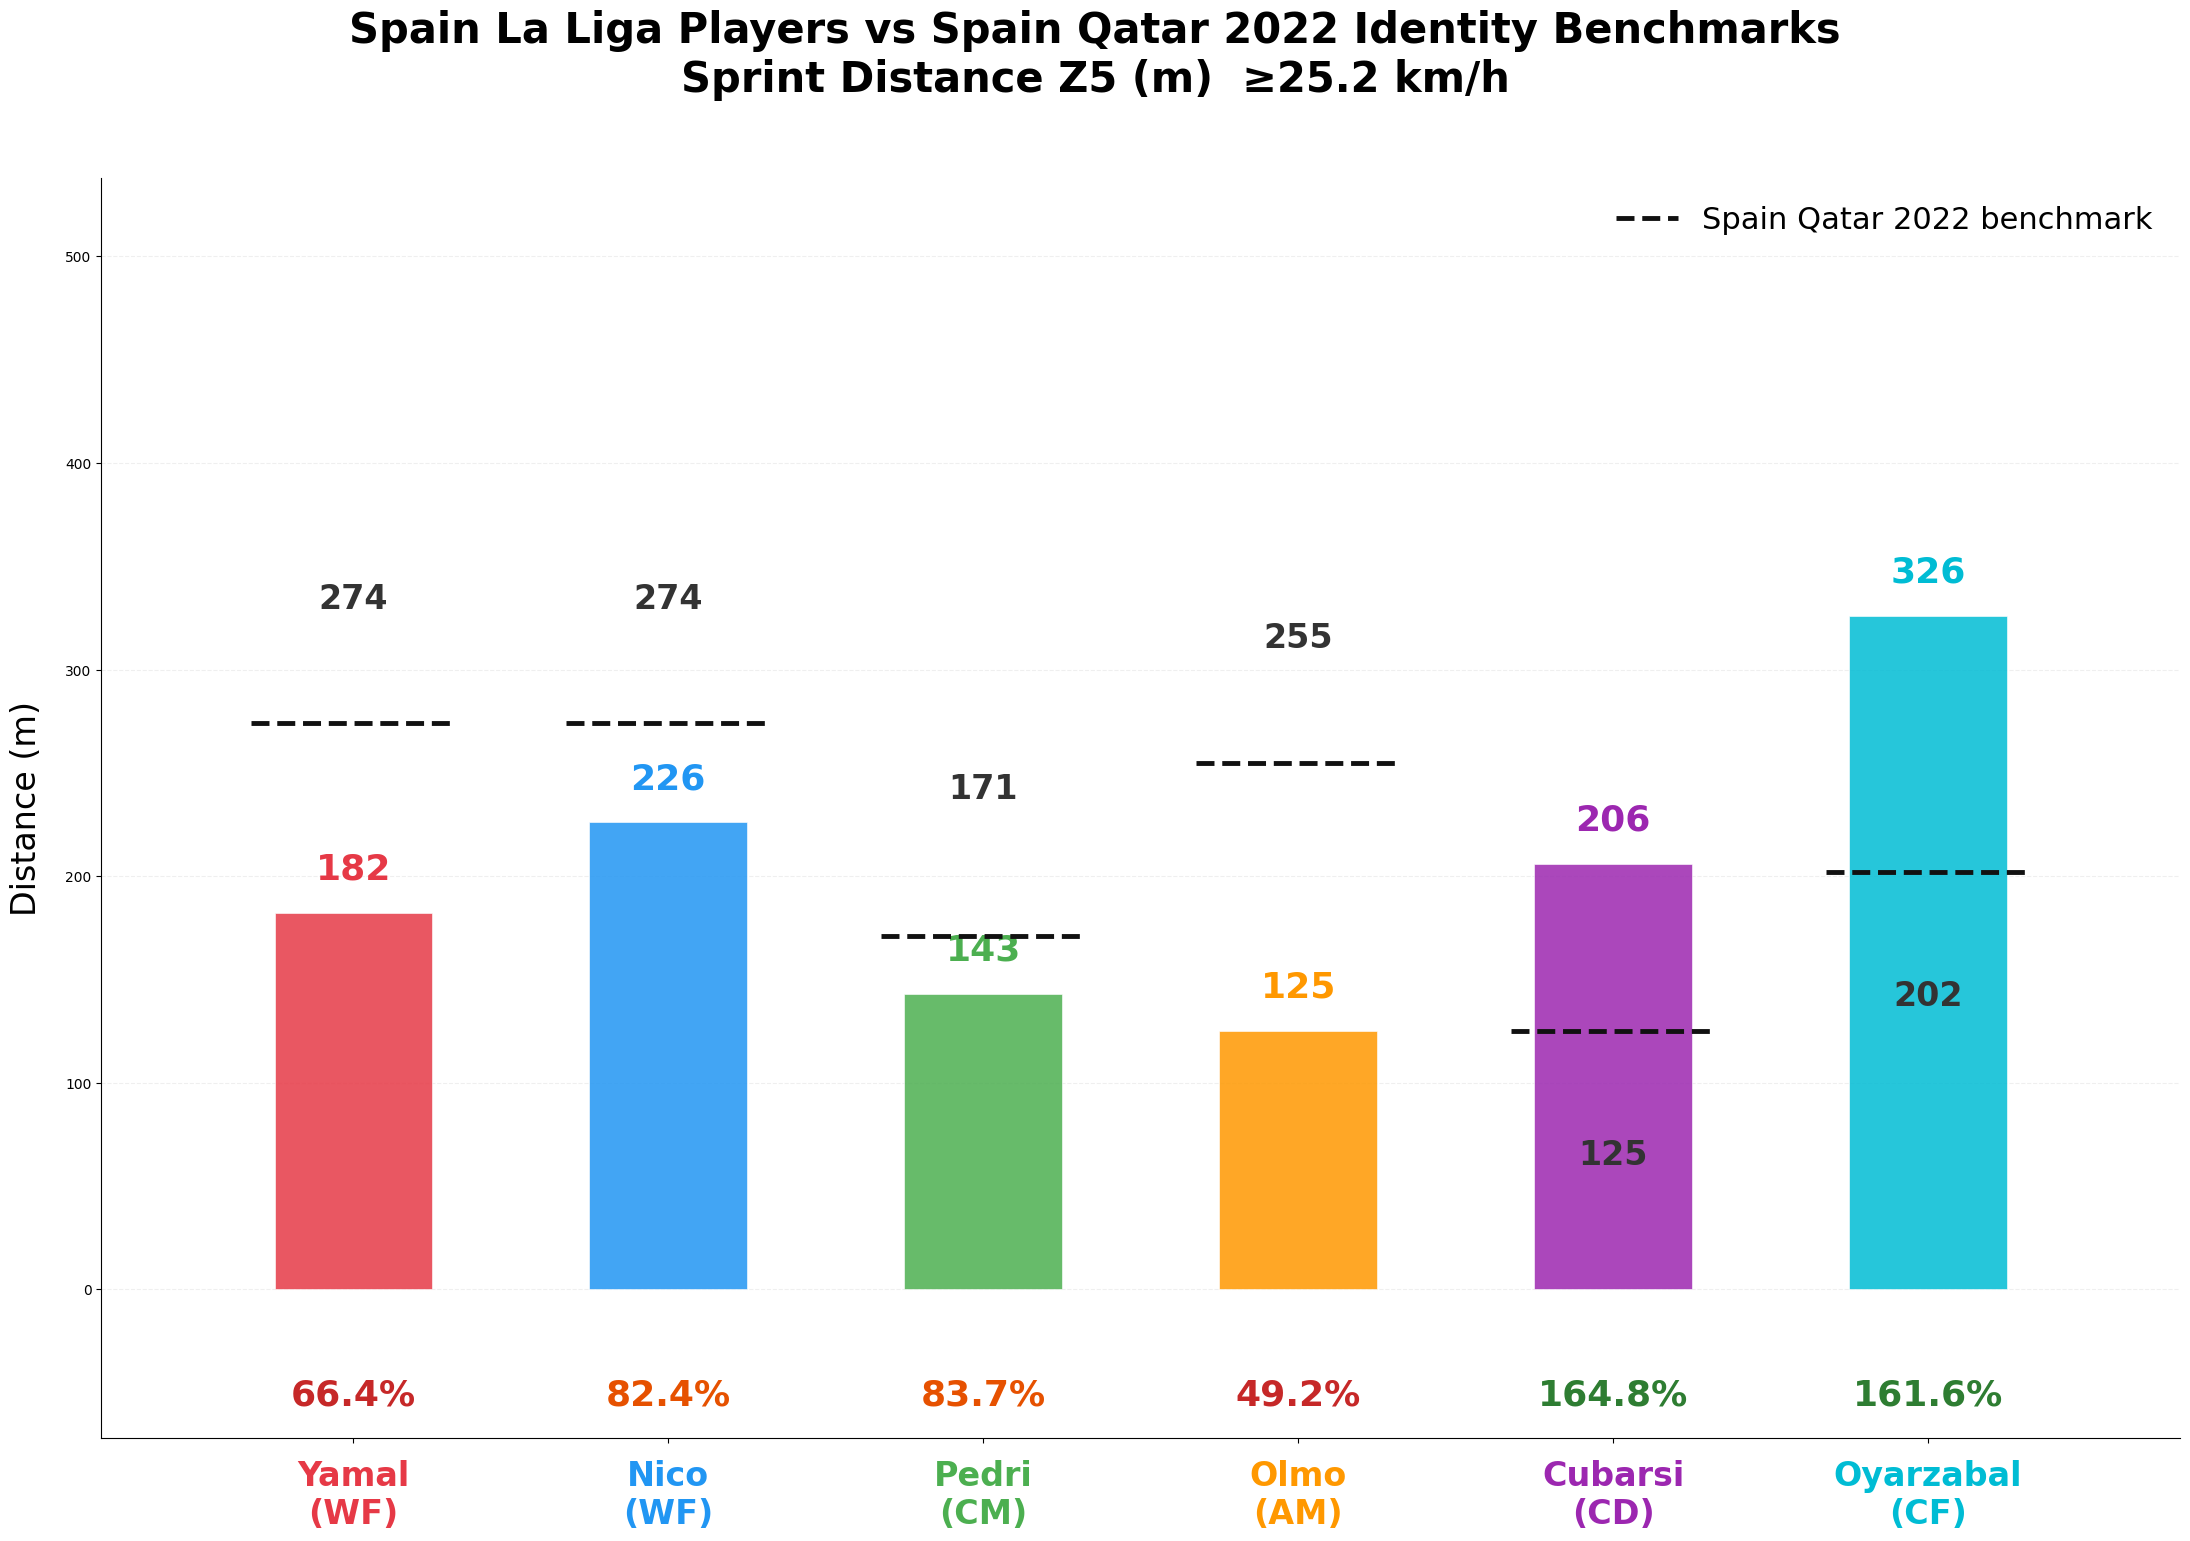

Saved: layer2_sprint.png

Layer 2 charts complete.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

players = ["Yamal", "Nico", "Pedri", "Olmo", "Cubarsi", "Oyarzabal"]
positions = ["WF", "WF", "CM", "AM", "CD", "CF"]
labels = [f"{p}\n({pos})" for p, pos in zip(players, positions)]

player_colors = [
    '#E63946', '#2196F3', '#4CAF50',
    '#FF9800', '#9C27B0', '#00BCD4'
]

# Layer 2 data
avg_total =   [9317, 8264, 10662, 8557, 9768, 9999]
bench_total = [10478, 10478, 11324, 10480, 9660, 10272]
pct_total =   [88.9, 78.9, 94.2, 81.7, 101.1, 97.3]

avg_z4z5 =   [683, 718, 707, 607, 701, 1074]
bench_z4z5 = [992, 992, 833, 929, 547, 816]
pct_z4z5 =   [68.9, 72.4, 84.8, 65.4, 128.2, 131.6]

avg_sprint =   [182, 226, 143, 125, 206, 326]
bench_sprint = [274, 274, 171, 255, 125, 202]
pct_sprint =   [66.4, 82.4, 83.7, 49.2, 164.8, 161.6]

identity_scores = [74.7, 77.9, 87.6, 65.4, 100.0, 100.0]

metrics = [
    (avg_total, bench_total, pct_total,
     "Total Distance (m)",
     "layer2_total_distance.png"),
    (avg_z4z5, bench_z4z5, pct_z4z5,
     "High Intensity Distance Z4+Z5 (m)  ≥19.8 km/h",
     "layer2_z4z5.png"),
    (avg_sprint, bench_sprint, pct_sprint,
     "Sprint Distance Z5 (m)  ≥25.2 km/h",
     "layer2_sprint.png"),
]

x = np.arange(len(players))
width = 0.5

def get_label_positions(a, b, max_val):
    min_gap = max_val * 0.16
    player_label_y = a + max_val * 0.04
    above = a >= b
    if above:
        bench_label_y = b - min_gap
        bench_va = 'top'
    else:
        bench_label_y = max(
            b + min_gap,
            player_label_y + min_gap * 1.5
        )
        bench_va = 'bottom'
    return player_label_y, bench_label_y, bench_va

# Layer 2 charts
for metric_idx, (avg, bench, pcts, title, filename) in enumerate(metrics):

    fig, ax = plt.subplots(figsize=(22, 16))
    max_val = max(max(avg), max(bench))
    y_top = max_val * 1.65
    y_bottom = -max_val * 0.22

    fig.suptitle(
        f"Spain La Liga Players vs Spain Qatar 2022 Identity Benchmarks\n{title}",
        fontsize=30, fontweight='bold', y=0.98
    )

    # Identity score badges on first chart
    if metric_idx == 0:
        for i, (score, c) in enumerate(zip(identity_scores, player_colors)):
            ax.text(
                i, max_val * 1.48,
                f"Score: {score}/100",
                ha='center', va='bottom',
                fontsize=20, fontweight='bold',
                color=c,
                bbox=dict(
                    boxstyle='round,pad=0.6',
                    facecolor='white',
                    edgecolor=c,
                    linewidth=2.0
                )
            )

    for i, (a, b, p, c) in enumerate(zip(avg, bench, pcts, player_colors)):

        ax.bar(i, a, width, color=c, alpha=0.85,
               edgecolor='white', linewidth=0.5, zorder=3)

        fmt = lambda v: f"{v:,}"
        player_label_y, bench_label_y, bench_va = get_label_positions(
            a, b, max_val
        )

        ax.text(i, player_label_y, fmt(a),
                ha='center', va='bottom',
                fontsize=26, fontweight='bold', color=c)

        ax.plot([i - width * 0.65, i + width * 0.65],
                [b, b], color='#111111', linewidth=3.5,
                linestyle='--', zorder=4)

        ax.text(i, bench_label_y, fmt(b),
                ha='center', va=bench_va,
                fontsize=24, fontweight='bold', color='#333333')

        pct_color = '#2E7D32' if p >= 90 else '#E65100' if p >= 70 else '#C62828'
        ax.text(i, y_bottom * 0.60, f"{p:.1f}%",
                ha='center', va='top',
                fontsize=26, fontweight='bold', color=pct_color)

    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.tick_params(axis='x', pad=22)

    for i, (lbl, c) in enumerate(zip(labels, player_colors)):
        ax.text(i, y_bottom * 1.15, lbl,
                ha='center', va='top',
                fontsize=24, fontweight='bold', color=c)

    ax.set_ylabel("Distance (m)", fontsize=24, labelpad=16)
    ax.set_ylim(bottom=y_bottom, top=y_top)
    ax.set_xlim(-0.8, len(players) - 0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2, linestyle='--', zorder=0)

    legend_elements = [
        plt.Line2D([0], [0], color='#111111', linewidth=3.5,
                   linestyle='--', label='Spain Qatar 2022 benchmark')
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=22, frameon=False)

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

print("\nLayer 2 charts complete.")

### Layer 2 Key Findings

Layer 2 shifts the focus from general World Cup demands to Spain's specific physical identity. Rather than asking whether a player can meet tournament standards, the question becomes whether their profile aligns with how Spain physically approached Qatar 2022.

The differences between Layer 1 and Layer 2 are relatively modest, which is an encouraging finding in itself. Players who performed strongly against the general World Cup benchmarks also tended to fit Spain's physical identity well. This suggests that Spain's success in Qatar was not built on extreme physical outputs, but on a profile that remained close to international standards while operating at slightly lower high-intensity and sprint volumes.

The Spain-adjusted benchmarks particularly favour players whose game is built around sustained work rate, positional discipline and efficient movement rather than repeated explosive actions. Cubarsi, Oyarzabal and Pedri remain among the strongest profiles in the sample, maintaining excellent alignment with Spain's physical identity despite representing very different positions.

For Nico Williams and Lamine Yamal, the reduction in Spain's high-intensity and sprint benchmarks narrows the gap to the target profile, reflecting the fact that Spain's physical identity has historically relied more on collective control than continuous vertical intensity. Dani Olmo again records the lowest score in the sample, although the differences are relatively small and should be interpreted within the context of role-specific demands.

Overall, the findings suggest that the majority of the sample are not only physically capable of competing at World Cup level, but are also well suited to the specific physical profile that characterised Spain's Qatar 2022 campaign.


# Readiness Index — Final Calculation

## What this code does

Combines Layer 1 Physical Readiness Score and
Layer 2 Spain Physical Identity Fit Score into the final
Readiness Index for each player.

Readiness Index = (Physical Score + Identity Score) / 2

Equal weights , transparent , grounded in
Bradley's peer-reviewed research framework.

Both layer dataframes are already in memory
from the previous steps. This code merges them
and produces the final index table ready for
visualisation.

In [ ]:
# Save Layer 2
df_layer2.to_csv('layer2_spain_identity.csv', index=False)
print("Layer 2 saved to layer2_spain_identity.csv")

Layer 2 saved to layer2_spain_identity.csv


In [ ]:
# Calculate Readiness Index

# Extract scores from each layer
layer1 = df_complete[['Player', 'Position', 'Physical Score (/100)']].copy()
layer1.columns = ['Player', 'Position', 'Physical Score']

layer2 = df_layer2[['Player', 'Spain Identity Fit Score']].copy()

# Merge on Player name
df_index = layer1.merge(layer2, on='Player')

# Calculate Readiness Index
df_index['Readiness Index'] = (
    (df_index['Physical Score'] + df_index['Spain Identity Fit Score']) / 2
).round(1)

# Sort by Readiness Index descending
df_index = df_index.sort_values(
    'Readiness Index', ascending=False
).reset_index(drop=True)

# Print results
print("=" * 60)
print("SPAIN WORLD CUP 2026 — READINESS INDEX")
print("=" * 60)
print(f"\nReadiness Index = (Physical Score + Identity Score) / 2\n")

for _, row in df_index.iterrows():
    print(f"{row['Player']} ({row['Position']})")
    print(f"  Physical Score:       {row['Physical Score']}/100")
    print(f"  Identity Fit Score:   {row['Spain Identity Fit Score']}/100")
    print(f"  READINESS INDEX:      {row['Readiness Index']}/100")
    print()

print("\nFull Summary Table:")
print(df_index.to_string(index=False))

# Save to CSV
df_index.to_csv('readiness_index_final.csv', index=False)
print("\nSaved to readiness_index_final.csv")

SPAIN WORLD CUP 2026 — READINESS INDEX

Readiness Index = (Physical Score + Identity Score) / 2

Pau Cubarsi (CD)
  Physical Score:       100.0/100
  Identity Fit Score:   100.0/100
  READINESS INDEX:      100.0/100

Mikel Oyarzabal (CF)
  Physical Score:       100.0/100
  Identity Fit Score:   100.0/100
  READINESS INDEX:      100.0/100

Pedri (CM)
  Physical Score:       87.7/100
  Identity Fit Score:   87.6/100
  READINESS INDEX:      87.6/100

Nico Williams (WF)
  Physical Score:       80.9/100
  Identity Fit Score:   77.9/100
  READINESS INDEX:      79.4/100

Lamine Yamal (WF)
  Physical Score:       78.5/100
  Identity Fit Score:   74.7/100
  READINESS INDEX:      76.6/100

Dani Olmo (AM)
  Physical Score:       70.4/100
  Identity Fit Score:   65.4/100
  READINESS INDEX:      67.9/100


Full Summary Table:
         Player Position  Physical Score  Spain Identity Fit Score  Readiness Index
    Pau Cubarsi       CD           100.0                     100.0            100.0
Mikel O

## World Cup Readiness Index

The final stage of the analysis brings together the two layers developed throughout the project into a single World Cup Readiness Index.

The purpose of the index is not to predict future performance or selection decisions. Instead, it provides a transparent benchmark of how closely each player's current physical profile aligns with both the demands of World Cup football and Spain's specific physical identity at Qatar 2022.

The index combines two complementary components.

**Physical Readiness Score** measures whether a player's La Liga physical output meets the positional standards observed across the 2022 World Cup.

**Spain Physical Identity Fit Score** measures how closely a player's physical profile aligns with the style and physical characteristics that defined Spain's performances at Qatar 2022.

Both scores are expressed on a 0–100 scale and combined using equal weighting:

**Readiness Index = (Physical Readiness Score + Spain Physical Identity Fit Score) / 2**

A high score therefore reflects more than physical capacity alone. It indicates that a player is not only capable of meeting international tournament demands, but also appears well suited to the specific physical profile associated with Spain's game model.

The visualisations that follow provide the clearest summary of the project's central question:

**Are Spain's key La Liga players physically prepared to reproduce the demands and identity associated with Spain's Qatar 2022 World Cup campaign?**

## Squad Availability Note

At the time of publication Lamine Yamal and
Nico Williams are both carrying injuries and
their participation in Spain's opening games
is uncertain.

The Readiness Index scores presented above
reflect their season-long physical output
across La Liga 2025/26. They describe the
physical levels both players demonstrated
when available and match fit — not their
current injury status or tournament
availability.

If either player misses significant game
time the progression and final third profiles
on the right and left flanks would require
reassessment. Yamal's 100th percentile for
line breaking carries and elite space receipt
profile and Nico's 92nd percentile for line
breaking carries and 85th for cross receiver
runs represent what both players contribute
when fit. The tournament context may differ
significantly from those baselines.

This limitation is acknowledged in the
article and in the full limitations section
below.


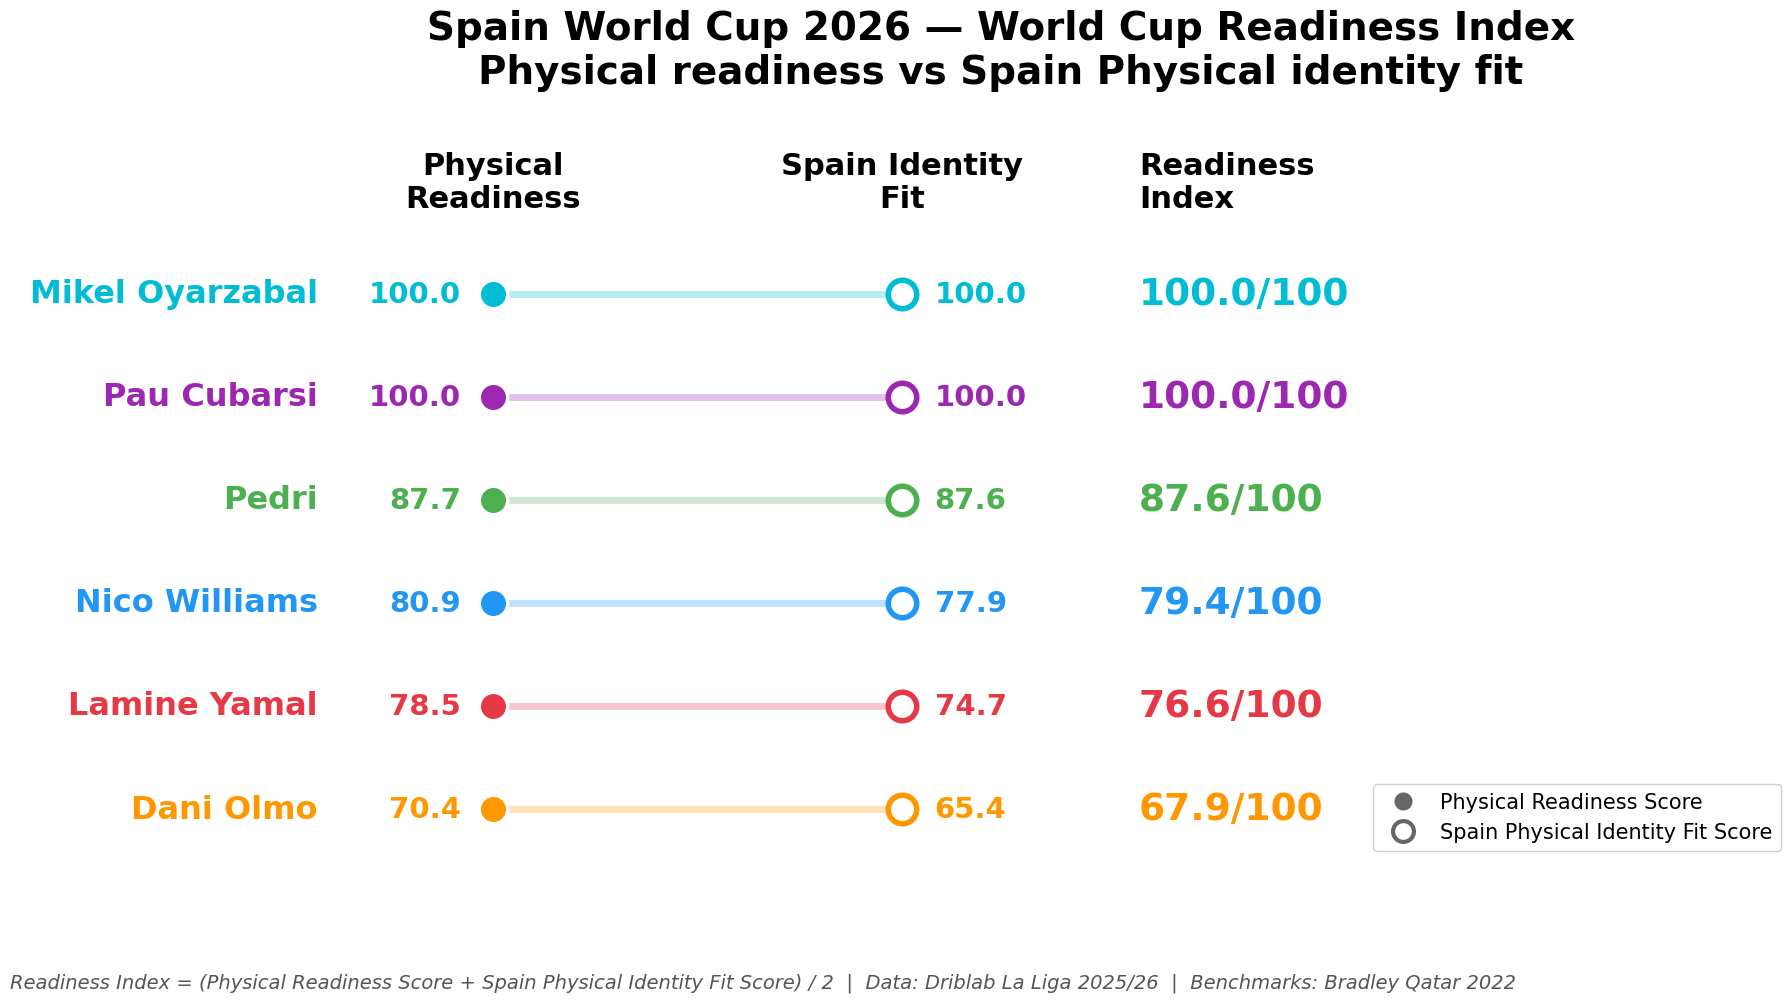

Saved: world_cup_readiness_index_slope_chart.png


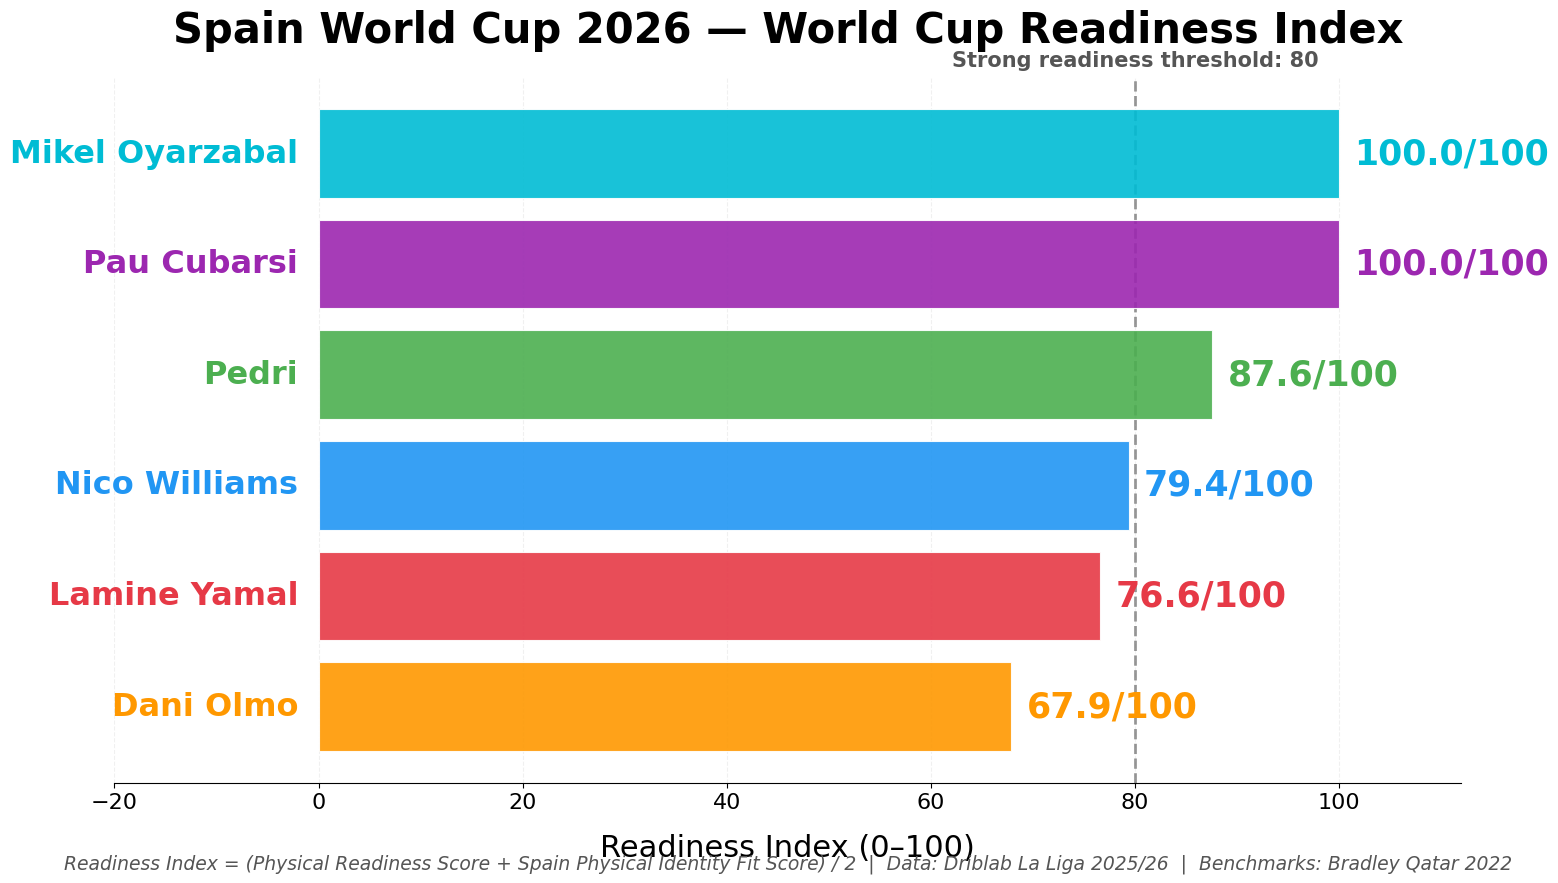

Saved: world_cup_readiness_index_hero_ranking.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

# Expected existing lists:
# labels_s, phys_s, ident_s, index_s, colors_s

# Initialize missing variables from df_index and player_colors
labels_s = df_index['Player'].tolist()
phys_s = df_index['Physical Score'].tolist()
ident_s = df_index['Spain Identity Fit Score'].tolist()
index_s = df_index['Readiness Index'].tolist()

# The player_colors list was defined in a previous cell (h48CPZ8uWfT8) and is in the kernel state.
# Need to map colors to the order of players in df_index.
# Update 'players' list to match full names in df_index for correct color mapping.
players = ["Lamine Yamal", "Nico Williams", "Pedri", "Dani Olmo", "Pau Cubarsi", "Mikel Oyarzabal"]
player_names_in_df_index = df_index['Player'].tolist()
player_name_to_color = dict(zip(players, player_colors))
colors_s = [player_name_to_color[p] for p in player_names_in_df_index]

# ----------------------------------------------------
# 1. Supporting Chart — Physical vs Identity Slope Chart
# ----------------------------------------------------

order = np.argsort(index_s)[::-1]

labels_plot = [labels_s[i] for i in order]
phys_plot = np.array([phys_s[i] for i in order], dtype=float)
ident_plot = np.array([ident_s[i] for i in order], dtype=float)
index_plot = np.array([index_s[i] for i in order], dtype=float)
colors_plot = [colors_s[i] for i in order]

y = np.arange(len(labels_plot))

fig, ax = plt.subplots(figsize=(19, 11))

fig.suptitle(
    "Spain World Cup 2026 — World Cup Readiness Index\n"
    "Physical readiness vs Spain Physical identity fit",
    fontsize=28,
    fontweight="bold",
    y=0.98
)

x_phys = 0
x_ident = 1

for i, (label, phys, ident, idx, c) in enumerate(
    zip(labels_plot, phys_plot, ident_plot, index_plot, colors_plot)
):
    ax.plot(
        [x_phys, x_ident],
        [i, i],
        color=c,
        linewidth=5,
        alpha=0.28,
        solid_capstyle="round",
        zorder=2
    )

    ax.scatter(
        x_phys,
        i,
        s=420,
        color=c,
        edgecolor="white",
        linewidth=2.5,
        zorder=4
    )

    ax.scatter(
        x_ident,
        i,
        s=420,
        facecolor="white",
        edgecolor=c,
        linewidth=4,
        zorder=5
    )

    ax.text(
        x_phys - 0.08,
        i,
        f"{phys:.1f}",
        ha="right",
        va="center",
        fontsize=21,
        fontweight="bold",
        color=c
    )

    ax.text(
        x_ident + 0.08,
        i,
        f"{ident:.1f}",
        ha="left",
        va="center",
        fontsize=21,
        fontweight="bold",
        color=c
    )

    ax.text(
        1.58,
        i,
        f"{idx:.1f}/100",
        ha="left",
        va="center",
        fontsize=27,
        fontweight="bold",
        color=c
    )

    ax.text(
        -0.43,
        i,
        label,
        ha="right",
        va="center",
        fontsize=23,
        fontweight="bold",
        color=c
    )

ax.text(
    x_phys,
    -0.78,
    "Physical\nReadiness",
    ha="center",
    va="bottom",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    x_ident,
    -0.78,
    "Spain Identity\nFit",
    ha="center",
    va="bottom",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    1.58,
    -0.78,
    "Readiness\nIndex",
    ha="left",
    va="bottom",
    fontsize=22,
    fontweight="bold"
)

ax.set_xlim(-0.78, 2.10)

# Extra bottom space so Olmo's score does not overlap legend/header
ax.set_ylim(-0.95, len(labels_plot) - 0.10)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

physical_handle = mlines.Line2D(
    [],
    [],
    marker="o",
    linestyle="None",
    markersize=15,
    markerfacecolor="#666666",
    markeredgecolor="white",
    markeredgewidth=2,
    label="Physical Readiness Score"
)

identity_handle = mlines.Line2D(
    [],
    [],
    marker="o",
    linestyle="None",
    markersize=15,
    markerfacecolor="white",
    markeredgecolor="#666666",
    markeredgewidth=3,
    label="Spain Physical Identity Fit Score"
)

# Move legend outside so it does not cover Dani Olmo's Readiness Index
ax.legend(
    handles=[physical_handle, identity_handle],
    loc="center left",
    bbox_to_anchor=(1.01, 0.12),
    fontsize=15,
    frameon=True,
    framealpha=0.95
)

ax.text(
    0.5,
    -0.10,
    "Readiness Index = (Physical Readiness Score + Spain Physical Identity Fit Score) / 2  "
    "|  Data: Driblab La Liga 2025/26  |  Benchmarks: Bradley Qatar 2022",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=14,
    color="#555555",
    style="italic"
)

plt.tight_layout(rect=[0, 0.06, 0.92, 0.95])
plt.savefig("world_cup_readiness_index_slope_chart.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: world_cup_readiness_index_slope_chart.png")


# ----------------------------------------------------
# 2. Hero Chart — World Cup Readiness Index Ranking
# ----------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 10))

hero_order = np.argsort(index_s)
labels_hero = [labels_s[i] for i in hero_order]
index_hero = np.array([index_s[i] for i in hero_order], dtype=float)
colors_hero = [colors_s[i] for i in hero_order]

y_hero = np.arange(len(labels_hero))

bars = ax.barh(
    y_hero,
    index_hero,
    color=colors_hero,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

for i, (score, c) in enumerate(zip(index_hero, colors_hero)):
    ax.text(
        score + 1.5,
        i,
        f"{score:.1f}/100",
        ha="left",
        va="center",
        fontsize=25,
        fontweight="bold",
        color=c
    )

ax.set_yticks(y_hero)
ax.set_yticklabels([])

for i, (lbl, c) in enumerate(zip(labels_hero, colors_hero)):
    ax.text(
        -2,
        i,
        lbl,
        ha="right",
        va="center",
        fontsize=23,
        fontweight="bold",
        color=c
    )

ax.set_title(
    "Spain World Cup 2026 — World Cup Readiness Index",
    fontsize=30,
    fontweight="bold",
    pad=25
)

ax.set_xlabel("Readiness Index (0–100)", fontsize=22, labelpad=15)

ax.set_xlim(-20, 112)

ax.axvline(
    80,
    color="#555555",
    linestyle="--",
    linewidth=2.0,
    alpha=0.6,
    zorder=2
)

ax.text(
    80,
    len(labels_hero) - 0.25,
    "Strong readiness threshold: 80",
    ha="center",
    va="bottom",
    fontsize=15,
    fontweight="bold",
    color="#555555",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        alpha=0.85
    )
)

ax.grid(axis="x", alpha=0.18, linestyle="--", zorder=0)

ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.text(
    0.5,
    -0.10,
    "Readiness Index = (Physical Readiness Score + Spain Physical Identity Fit Score) / 2  "
    "|  Data: Driblab La Liga 2025/26  |  Benchmarks: Bradley Qatar 2022",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=13.5,
    color="#555555",
    style="italic"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("world_cup_readiness_index_hero_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: world_cup_readiness_index_hero_ranking.png")

### Final Interpretation

The objective of this project was not to identify Spain's best players, but to assess whether a selected group of key La Liga internationals currently possess the physical profile required to reproduce the demands and identity associated with Spain's Qatar 2022 World Cup campaign.

The findings suggest that the answer is largely yes for this sample of players. Across both layers of the framework, the majority of players demonstrated strong alignment with international tournament standards and with Spain's specific physical identity. Cubarsi and Oyarzabal emerged as the strongest overall profiles, while Pedri recorded the highest score among midfielders. Nico Williams and Lamine Yamal also produced encouraging results, suggesting that their physical output is already approaching the levels associated with elite international competition.

Perhaps the most important finding is that the differences between the Physical Readiness Score and the Spain Physical Identity Fit Score were relatively small across the sample. Players capable of meeting general World Cup demands also tended to align well with Spain's distinctive physical profile. This suggests that Spain's success is not dependent on exceptional physical outputs alone, but on a balanced combination of work volume, controlled intensity and tactical organisation.

These results should not be interpreted as predictions of future tournament performance. Football performance is influenced by many factors beyond physical output, including tactical role, team context, opposition quality and decision-making. Instead, the Readiness Index should be viewed as an objective benchmark of current physical preparedness and physical fit within Spain's established World Cup identity.

The next stage of the analysis moves beyond physical readiness and into football intelligence, exploring how these players create value through space occupation, pressure, progression and line-breaking actions using Driblab's Arrigo framework.


# Layer 3 — Step 1: Explore Full Arrigo Structure

## What this code does
Pulls the full Season Arrigo Metrics for all
611 La Liga players and prints the complete
field structure for one player per position
from our six. This tells us exactly which
metrics are available and how they are named
before we write any analysis code.

In [ ]:
import requests
import json

API_TOKEN = ""
BASE_URL = "https://apidriblab.com"
headers = {"Authorization": f"Bearer {API_TOKEN.strip()}"}

season_id = 818687

# Pull full Arrigo dataset — one call for all 611 players
print("Pulling Arrigo data...")
response = requests.get(
    f"{BASE_URL}/season/{season_id}/arrigo-metrics",
    headers=headers
)

data = response.json()
if isinstance(data, dict) and 'body' in data:
    arrigo_all = data['body']
elif isinstance(data, list):
    arrigo_all = data
else:
    arrigo_all = data

print(f"Total records: {len(arrigo_all)}")

# Our six player IDs
target_players = {
    "Lamine Yamal":    1776309,
    "Nico Williams":   1533082,
    "Pedri":           1477163,
    "Dani Olmo":       1221869,
    "Pau Cubarsi":     1746425,
    "Mikel Oyarzabal": 273054
}

# Print complete Arrigo structure for each player
print("\nFull Arrigo structure per player:\n")

for player_name, player_id in target_players.items():
    for record in arrigo_all:
        if record['player']['id'] == player_id:
            print(f"\n{'='*60}")
            print(f"{player_name} ({record['player']['position']})")
            print(f"Minutes: {record['player']['minutes_played']}")
            print(f"{'='*60}")
            print(json.dumps(record['stats'], indent=2))
            break

Pulling Arrigo data...
Total records: 611

Full Arrigo structure per player:


Lamine Yamal (AMR)
Minutes: 2563
{
  "off_ball runs": {
    "offBallRuns": 411,
    "offBallRunsOverlap": 7,
    "offBallRunsUnderlap": 13,
    "offBallRunsRunAhead": 173,
    "offBallRunsRunBehind": 88,
    "offBallRunsCrossReceiver": 19,
    "offBallRunsSupport": 66,
    "offBallRunsComingShort": 45
  },
  "out_play": {
    "timesBypassedByActions": 268,
    "timesBypassedByCarries": 28,
    "timesBypassedByPasses": 240,
    "bypassedDefendersByPasses": 98,
    "bypassedDefendersByActions": 140,
    "bypassedDefendersByCarries": 42,
    "bypassedPlayersByPasses": 261,
    "bypassedPlayersByActions": 345,
    "bypassedPlayersByCarries": 84,
    "carriesBypassingDefenders": 35,
    "passesBypassingDefenders": 56,
    "passesBypassingPlayers": 99,
    "bypassedPlayersPerPass": 0.2,
    "bypassedDefendersPerPass": 0.1,
    "carriesBypassingPlayers": 55,
    "bypassedPlayersPerCarry": 0.5,
    "bypassedDefender

# Layer 3 — Game Intelligence Profiles
## Who Creates the Progressions Spain's
## Physical Identity Is Designed to Serve?

---

## The Question

Bradley's Part 2 found that Spain's physical
intensity in possession correlated most
strongly with progression events (r=0.73)
and final third entries (r=0.75). Layer 3
asks who actually delivers those actions
at player level.

---

## Why Not Scored

Arrigo metrics are season totals without
phase of play or opponent context. Scoring
them would imply precision the data cannot
support. Percentile profiles and football
interpretation are more honest and more
useful.

---

## Metric Categories

Two categories reflecting Bradley's findings:

**Progression** — actions that advance
possession through defensive structures:
lineBreakingPasses, lineBreakingPassesMD,
lineBreakingThroughBalls, lineBreakingCarriesD,
bypassedDefendersByPasses,
passingUnderStrongPressure,
offBallRunsComingShort

**Final Third Access** — actions that create
or exploit dangerous space in advanced areas:
passReceiptsInSpaceCompleted,
offBallRunsRunBehind, offBallRunsCrossReceiver,
offBallRunsRunAhead

---

## Observed Behaviours

Spain's matches against Egypt, France,
Portugal and Turkey were studied directly.
Cubarsi was absent — his profile is projected
from Barcelona where he consistently initiates
with line breaking passes from deep.

Pedri receives short under pressure and plays
forward immediately. Olmo lives between the
lines — drops, combines, unlocks. Yamal and
Nico come short against deep blocks then
attack space. Oyarzabal runs behind and drops
to link — a complete modern striker profile.

Every metric reflects these observed
behaviours.

---

## Spain's Attacking Mechanism

The profiles should not be read in isolation.
Cubarsi initiates from deep. Pedri advances
through midfield. Olmo links progression to
final third access. Yamal and Nico attack
space on the flanks. Oyarzabal occupies
central finishing spaces. The objective is
not to rank players but to understand how
each contributes to the progression and
final third actions most associated with
Spain's physical identity.

---

## Player Profiles

**Cubarsi — Initiator (DC)**
Progression only.
lineBreakingPasses, lineBreakingPassesMD,
bypassedDefendersByPasses,
passingUnderStrongPressure

**Pedri — Connector (DMC)**
Progression dominant.
lineBreakingPasses, lineBreakingPassesMD,
lineBreakingThroughBalls,
bypassedDefendersByPasses,
passingUnderStrongPressure,
offBallRunsComingShort, offBallRunsRunAhead

Note: Pedri is classified DMC in Driblab's
system. His percentiles reflect that peer
group — defensive and central midfielders —
rather than a pure attacking midfielder
comparison.

**Dani Olmo — Link (AMC)**
Progression: lineBreakingPasses,
lineBreakingThroughBalls,
passingUnderStrongPressure,
offBallRunsComingShort
Final third: offBallRunsRunAhead,
offBallRunsRunBehind,
passReceiptsInSpaceCompleted

**Lamine Yamal — Finisher (AMR)**
Progression: offBallRunsComingShort,
lineBreakingCarriesD
Final third: passReceiptsInSpaceCompleted,
offBallRunsRunBehind, offBallRunsCrossReceiver,
offBallRunsRunAhead

**Nico Williams — Finisher (AML)**
Same structure as Yamal mirrored on left.
Progression: offBallRunsComingShort,
lineBreakingCarriesD
Final third: passReceiptsInSpaceCompleted,
offBallRunsRunBehind, offBallRunsCrossReceiver,
offBallRunsRunAhead

**Oyarzabal — Target (FW)**
Progression: offBallRunsComingShort
Final third: passReceiptsInSpaceCompleted,
offBallRunsRunBehind, offBallRunsCrossReceiver,
offBallRunsRunAhead

---

## Positional Peer Groups

Percentiles calculated against Arrigo
positional classifications with minimum
900 minutes. Cubarsi DC, Pedri DMC,
Olmo AMC, Yamal AMR, Nico AML,
Oyarzabal FW.

---

## Limitation

Arrigo season totals identify actions but
not the spatial sequence or phase context
leading to them. All metrics are proxies
for progression and final third entry
behaviour — directionally valid but not
phase-filtered.

# Layer 3 — Step 2: Build Arrigo Percentile Profiles

## What this code does
Pulls the full 611 player Arrigo dataset,
converts all counting metrics to per 90,
filters positional peer groups with minimum
900 minutes, calculates percentile rankings
for each player's relevant metrics and
produces the final Layer 3 profiles.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
import json

# Pull full Arrigo dataset
print("Pulling Arrigo data...")
response = requests.get(
    f"{BASE_URL}/season/{season_id}/arrigo-metrics",
    headers=headers
)
data = response.json()
if isinstance(data, dict) and 'body' in data:
    arrigo_all = data['body']
else:
    arrigo_all = data

print(f"Total records: {len(arrigo_all)}")

# Convert to dataframe
rows = []
for record in arrigo_all:
    player = record['player']
    player_stats = record['stats']
    minutes = player['minutes_played']

    if minutes < 1:
        continue

    p90 = 90 / minutes

    row = {
        'player_id': player['id'],
        'player_name': player['name'],
        'position': player['position'],
        'minutes': minutes,
        'lineBreakingPasses_p90': player_stats['line_breaking passes']['lineBreakingPasses'] * p90,
        'lineBreakingPassesMD_p90': player_stats['line_breaking passes']['lineBreakingPassesMD'] * p90,
        'lineBreakingThroughBalls_p90': player_stats['line_breaking passes']['lineBreakingThroughBalls'] * p90,
        'lineBreakingCarriesD_p90': player_stats['line_breaking carries']['lineBreakingCarriesD'] * p90,
        'bypassedDefendersByPasses_p90': player_stats['out_play']['bypassedDefendersByPasses'] * p90,
        'passingUnderStrongPressure_pct': player_stats['pass_under pressure']['passingUnderStrongPressure'],
        'offBallRunsComingShort_p90': player_stats['off_ball runs']['offBallRunsComingShort'] * p90,
        'passReceiptsInSpaceCompleted_p90': player_stats['ball_received']['passReceiptsInSpaceCompleted'] * p90,
        'offBallRunsRunBehind_p90': player_stats['off_ball runs']['offBallRunsRunBehind'] * p90,
        'offBallRunsCrossReceiver_p90': player_stats['off_ball runs']['offBallRunsCrossReceiver'] * p90,
        'offBallRunsRunAhead_p90': player_stats['off_ball runs']['offBallRunsRunAhead'] * p90,
    }
    rows.append(row)

df_arrigo = pd.DataFrame(rows)
print(f"Dataframe built: {len(df_arrigo)} players")

# Player configuration
player_config = {
    "Pau Cubarsi": {
        "id": 1746425,
        "position": "DC",
        "role": "The Initiator",
        "progression": [
            'lineBreakingPasses_p90',
            'lineBreakingPassesMD_p90',
            'bypassedDefendersByPasses_p90',
            'passingUnderStrongPressure_pct'
        ],
        "final_third": []
    },
    "Pedri": {
        "id": 1477163,
        "position": "DMC",
        "role": "The Connector",
        "progression": [
            'lineBreakingPasses_p90',
            'lineBreakingPassesMD_p90',
            'lineBreakingThroughBalls_p90',
            'bypassedDefendersByPasses_p90',
            'passingUnderStrongPressure_pct',
            'offBallRunsComingShort_p90'
        ],
        "final_third": [
            'offBallRunsRunAhead_p90'
        ]
    },
    "Dani Olmo": {
        "id": 1221869,
        "position": "AMC",
        "role": "The Link",
        "progression": [
            'lineBreakingPasses_p90',
            'lineBreakingThroughBalls_p90',
            'passingUnderStrongPressure_pct',
            'offBallRunsComingShort_p90'
        ],
        "final_third": [
            'offBallRunsRunAhead_p90',
            'offBallRunsRunBehind_p90',
            'passReceiptsInSpaceCompleted_p90'
        ]
    },
    "Lamine Yamal": {
        "id": 1776309,
        "position": "AMR",
        "role": "The Finisher",
        "progression": [
            'offBallRunsComingShort_p90',
            'lineBreakingCarriesD_p90'
        ],
        "final_third": [
            'passReceiptsInSpaceCompleted_p90',
            'offBallRunsRunBehind_p90',
            'offBallRunsCrossReceiver_p90',
            'offBallRunsRunAhead_p90'
        ]
    },
    "Nico Williams": {
        "id": 1533082,
        "position": "AML",
        "role": "The Finisher",
        "progression": [
            'offBallRunsComingShort_p90',
            'lineBreakingCarriesD_p90'
        ],
        "final_third": [
            'passReceiptsInSpaceCompleted_p90',
            'offBallRunsRunBehind_p90',
            'offBallRunsCrossReceiver_p90',
            'offBallRunsRunAhead_p90'
        ]
    },
    "Mikel Oyarzabal": {
        "id": 273054,
        "position": "FW",
        "role": "The Target",
        "progression": [
            'offBallRunsComingShort_p90'
        ],
        "final_third": [
            'passReceiptsInSpaceCompleted_p90',
            'offBallRunsRunBehind_p90',
            'offBallRunsCrossReceiver_p90',
            'offBallRunsRunAhead_p90'
        ]
    }
}

# Calculate percentiles per player
results = []

for player_name, config in player_config.items():

    player_row = df_arrigo[df_arrigo['player_id'] == config['id']]
    if player_row.empty:
        print(f"Player not found: {player_name}")
        continue

    player_data = player_row.iloc[0]

    peers = df_arrigo[
        (df_arrigo['position'] == config['position']) &
        (df_arrigo['minutes'] >= 900)
    ]

    print(f"\n{player_name} ({config['position']}) — {config['role']}")
    print(f"  Peer group size: {len(peers)} players")
    print(f"  Minutes: {player_data['minutes']}")

    all_metrics = config['progression'] + config['final_third']
    metric_results = []

    for metric in all_metrics:
        player_value = player_data[metric]
        peer_values = peers[metric].dropna()
        percentile = scipy_stats.percentileofscore(peer_values, player_value)
        category = 'Progression' if metric in config['progression'] else 'Final Third'

        metric_results.append({
            'metric': metric,
            'value': round(player_value, 2),
            'percentile': round(percentile, 1),
            'category': category
        })

        print(f"  {category} | {metric}: {round(player_value,2)} — {round(percentile,1)}th percentile")

    results.append({
        'player': player_name,
        'position': config['position'],
        'role': config['role'],
        'metrics': metric_results
    })

print("\n\nLayer 3 profiles complete.")

Pulling Arrigo data...
Total records: 611
Dataframe built: 611 players

Pau Cubarsi (DC) — The Initiator
  Peer group size: 73 players
  Minutes: 3049
  Progression | lineBreakingPasses_p90: 3.34 — 74.0th percentile
  Progression | lineBreakingPassesMD_p90: 0.3 — 79.5th percentile
  Progression | bypassedDefendersByPasses_p90: 2.6 — 38.4th percentile
  Progression | passingUnderStrongPressure_pct: 78.3 — 46.6th percentile

Pedri (DMC) — The Connector
  Peer group size: 22 players
  Minutes: 2377
  Progression | lineBreakingPasses_p90: 8.41 — 100.0th percentile
  Progression | lineBreakingPassesMD_p90: 0.72 — 100.0th percentile
  Progression | lineBreakingThroughBalls_p90: 2.23 — 100.0th percentile
  Progression | bypassedDefendersByPasses_p90: 5.53 — 100.0th percentile
  Progression | passingUnderStrongPressure_pct: 91.1 — 81.8th percentile
  Progression | offBallRunsComingShort_p90: 2.76 — 63.6th percentile
  Final Third | offBallRunsRunAhead_p90: 7.19 — 81.8th percentile

Dani Olmo (

# Layer 3 — Internal Validation
## Average Percentile Summary and Peer Group Check

## What this code does

Before writing the Layer 3 player profiles two
internal checks are performed.

First — average progression and final third
percentiles are calculated per player. This
produces a summary table that sharpens the
narrative before writing by showing each
player's dominant category at a glance.
This table is not published in the final
article — it is an analytical tool to ensure
the written profiles accurately reflect what
the data shows.

Second — the FW peer group composition is
checked for Oyarzabal. His raw counts for
runs behind (154 across the season) are the
highest of all six players yet his percentile
ranking is surprisingly low. Checking who is
in his peer group explains this discrepancy
and determines whether it reflects a data
issue or a genuine analytical finding.

In [ ]:
# Internal summary — average percentiles per category

player_summary = {}

for result in results:
    player = result['player']
    prog_pcts = [m['percentile'] for m in result['metrics']
                 if m['category'] == 'Progression']
    ft_pcts = [m['percentile'] for m in result['metrics']
               if m['category'] == 'Final Third']

    avg_prog = round(sum(prog_pcts) / len(prog_pcts), 1) if prog_pcts else None
    avg_ft = round(sum(ft_pcts) / len(ft_pcts), 1) if ft_pcts else None

    player_summary[player] = {
        'avg_progression': avg_prog,
        'avg_final_third': avg_ft
    }

    print(f"{player}")
    print(f"  Avg Progression Percentile:  {avg_prog}")
    print(f"  Avg Final Third Percentile:  {avg_ft}")
    print()

# Also check Oyarzabal FW peer group composition
print("\nFW peer group sample — top 10 by minutes:")
fw_peers = df_arrigo[
    (df_arrigo['position'] == 'FW') &
    (df_arrigo['minutes'] >= 900)
].sort_values('minutes', ascending=False)
print(fw_peers[['player_name', 'minutes',
                'offBallRunsRunBehind_p90',
                'offBallRunsRunAhead_p90']].head(10).to_string())

Pau Cubarsi
  Avg Progression Percentile:  59.6
  Avg Final Third Percentile:  None

Pedri
  Avg Progression Percentile:  90.9
  Avg Final Third Percentile:  81.8

Dani Olmo
  Avg Progression Percentile:  85.0
  Avg Final Third Percentile:  86.7

Lamine Yamal
  Avg Progression Percentile:  87.5
  Avg Final Third Percentile:  68.8

Nico Williams
  Avg Progression Percentile:  57.7
  Avg Final Third Percentile:  63.5

Mikel Oyarzabal
  Avg Progression Percentile:  66.7
  Avg Final Third Percentile:  51.5


FW peer group sample — top 10 by minutes:
           player_name  minutes  offBallRunsRunBehind_p90  offBallRunsRunAhead_p90
527       Vedat Muriqi     3474                  4.948187                 5.051813
187       Ante Budimir     3242                  6.162862                 6.051820
126    Vinicius Junior     3116                  5.112323                 4.707959
272    Mikel Oyarzabal     3046                  4.550230                 5.170716
593      Toni Martinez     2958  

## Findings from Internal Validation

The summary table reveals three important
patterns before writing the profiles.

Pedri and Olmo are elite in both categories
simultaneously — the only two players with
average percentiles above 80 in progression
and final third access combined.

Yamal is stronger in progression than final
third access — the opposite of the typical
wide forward expectation. His value comes
from carrying and progressing rather than
pure movement into dangerous spaces.

Nico is moderate across both categories —
his value comes from specific explosive
moments rather than consistent elite output.

The FW peer group check explains Oyarzabal's
low percentiles. His peer group includes
Vinicius Junior, Mbappe, Muriqi and Budimir —
some of the most movement-intensive forwards
in La Liga. His absolute values for runs
behind are comparable to elite forwards.
His relative ranking is suppressed by the
composition of his peer group. This is a
genuine positional context finding not a
data error. Oyarzabal's profile is that of
a complete striker — linking play, occupying
central spaces and arriving to finish —
rather than a pure movement forward.

# Layer 3 — Visualisations

## What this code does
Produces two types of visualisations for
Layer 3. First — one horizontal percentile
bar chart per player showing their metrics
split by Progression and Final Third Access
categories. Second — one radar chart
comparing Yamal and Nico Williams directly
across their shared metrics.

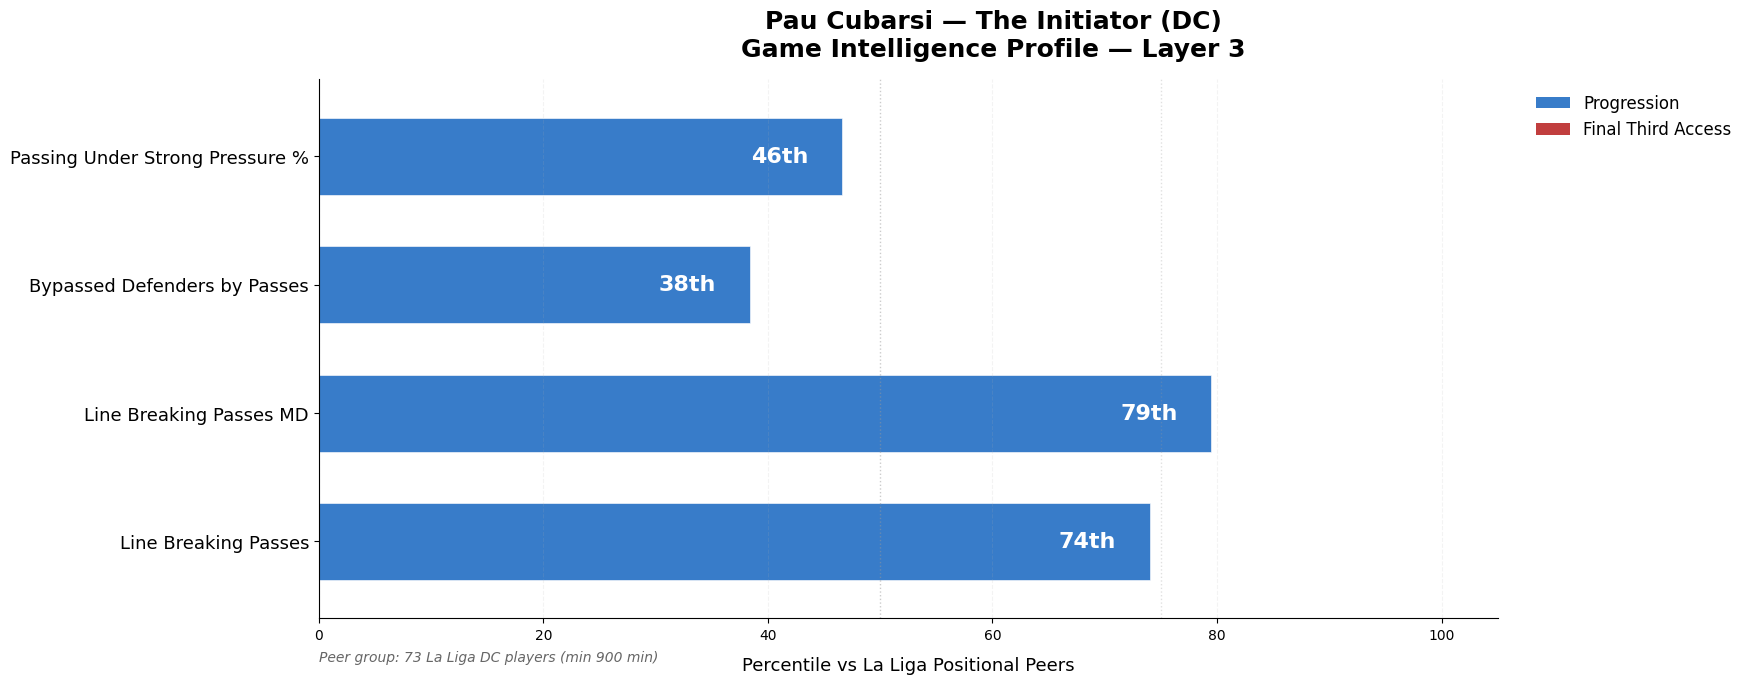

Saved: layer3_pau_cubarsi.png


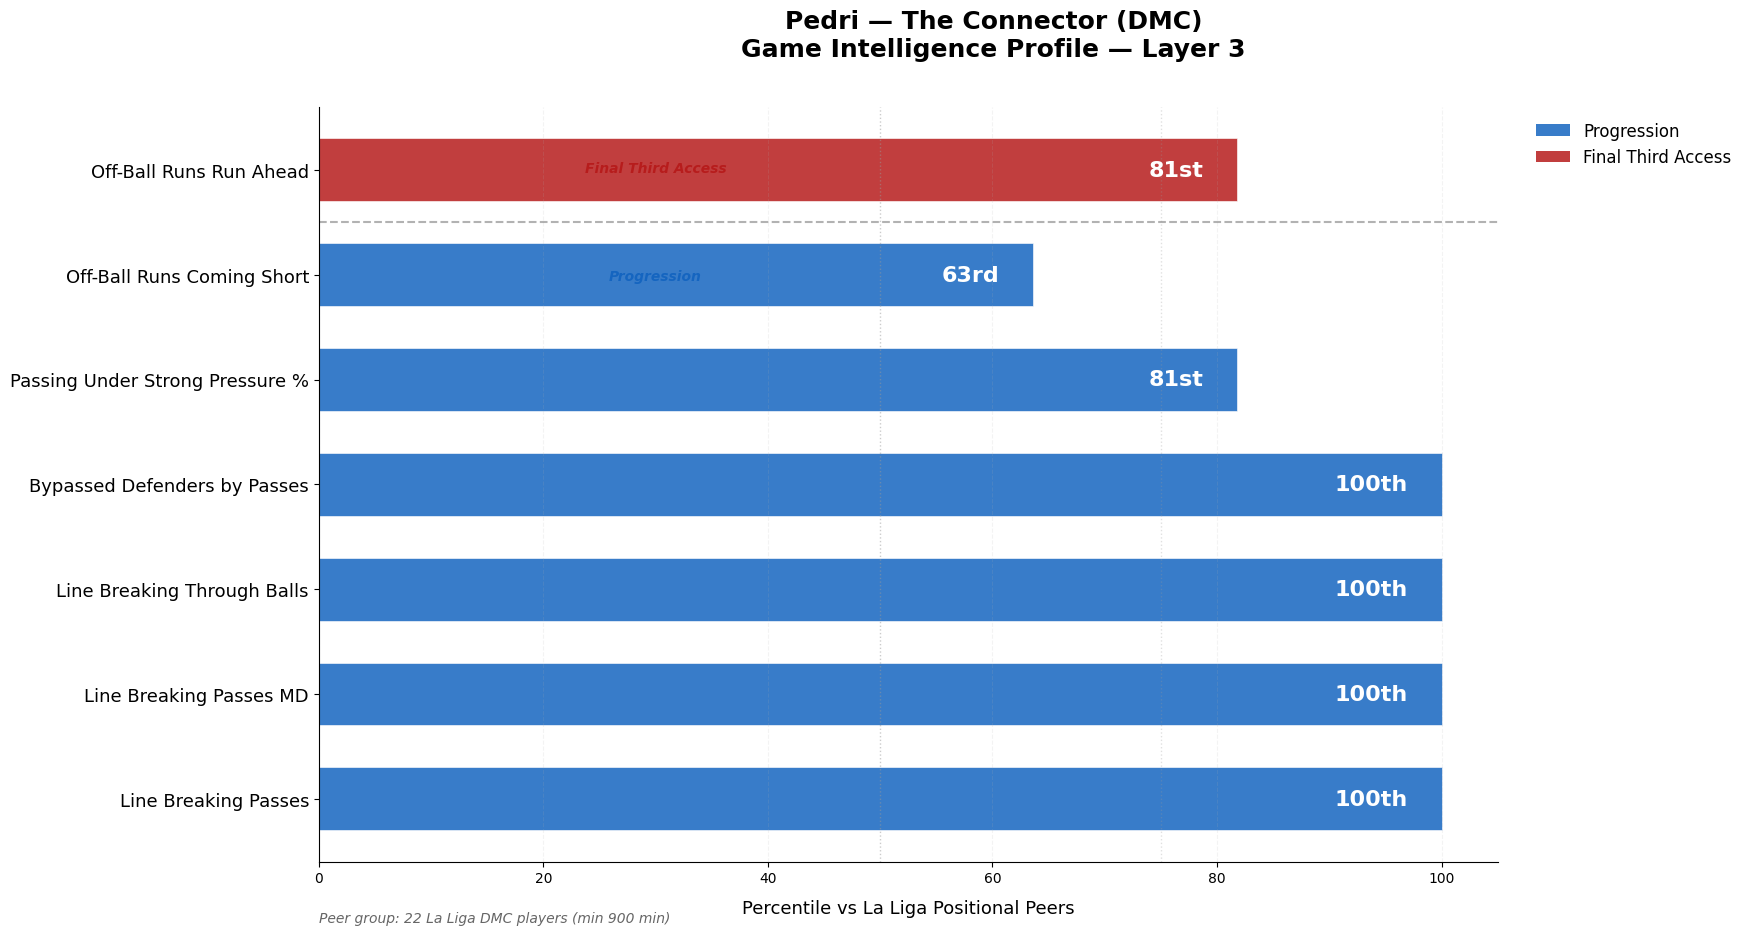

Saved: layer3_pedri.png


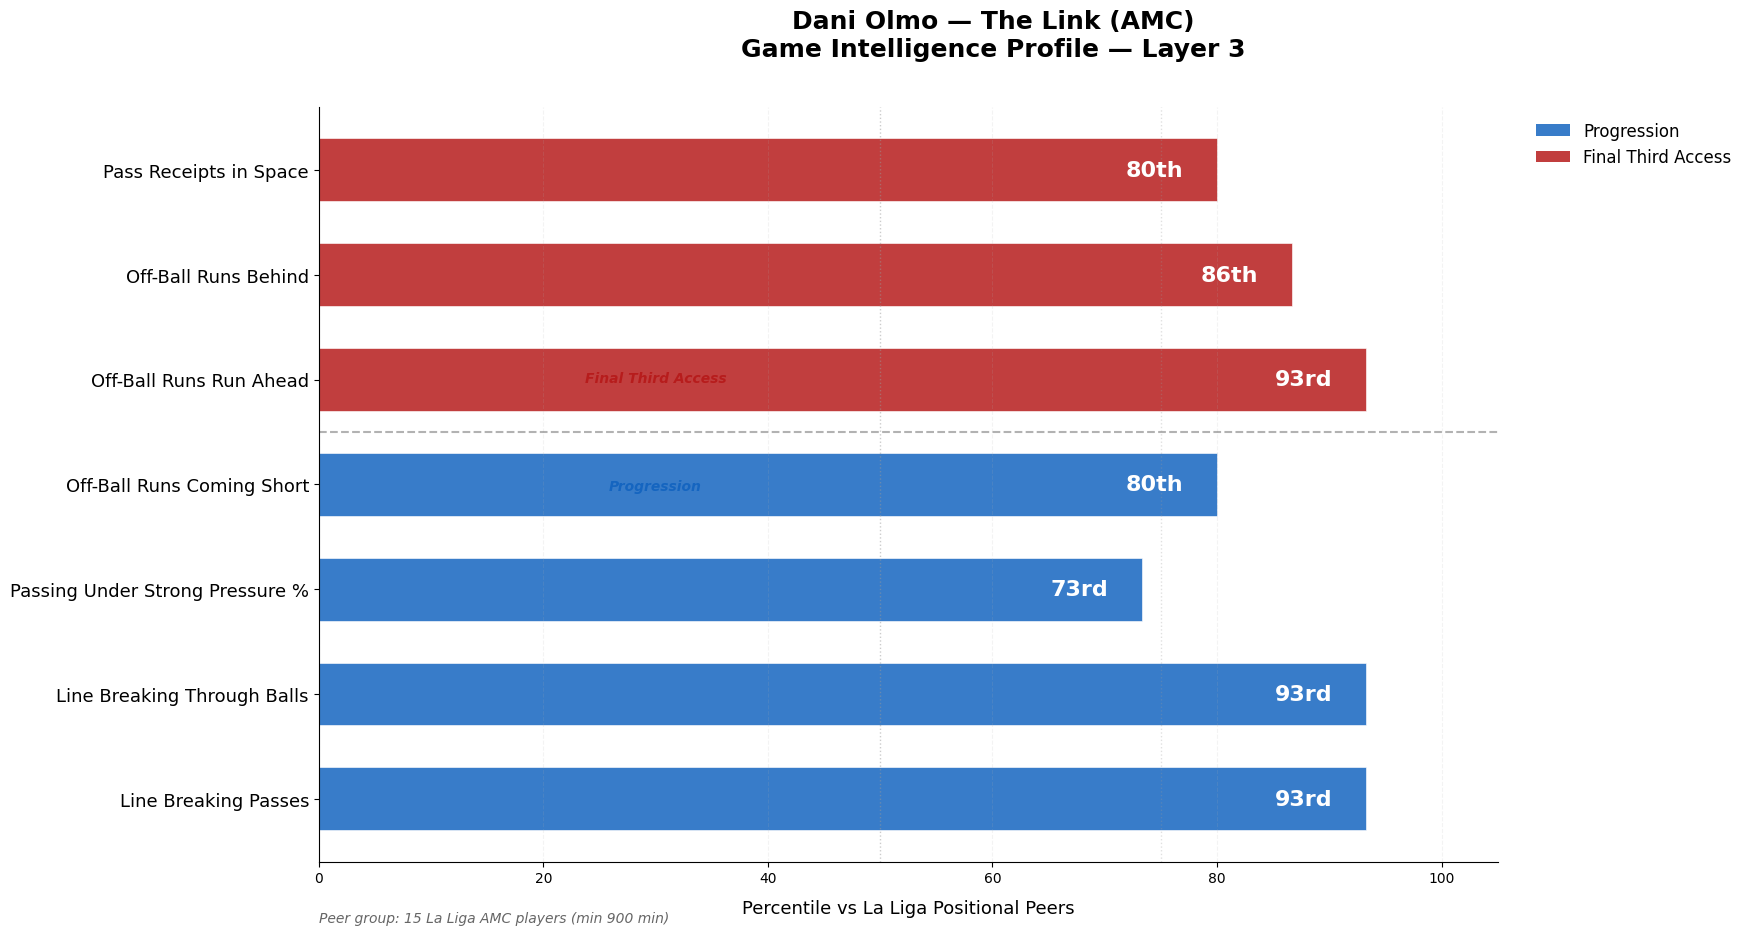

Saved: layer3_dani_olmo.png


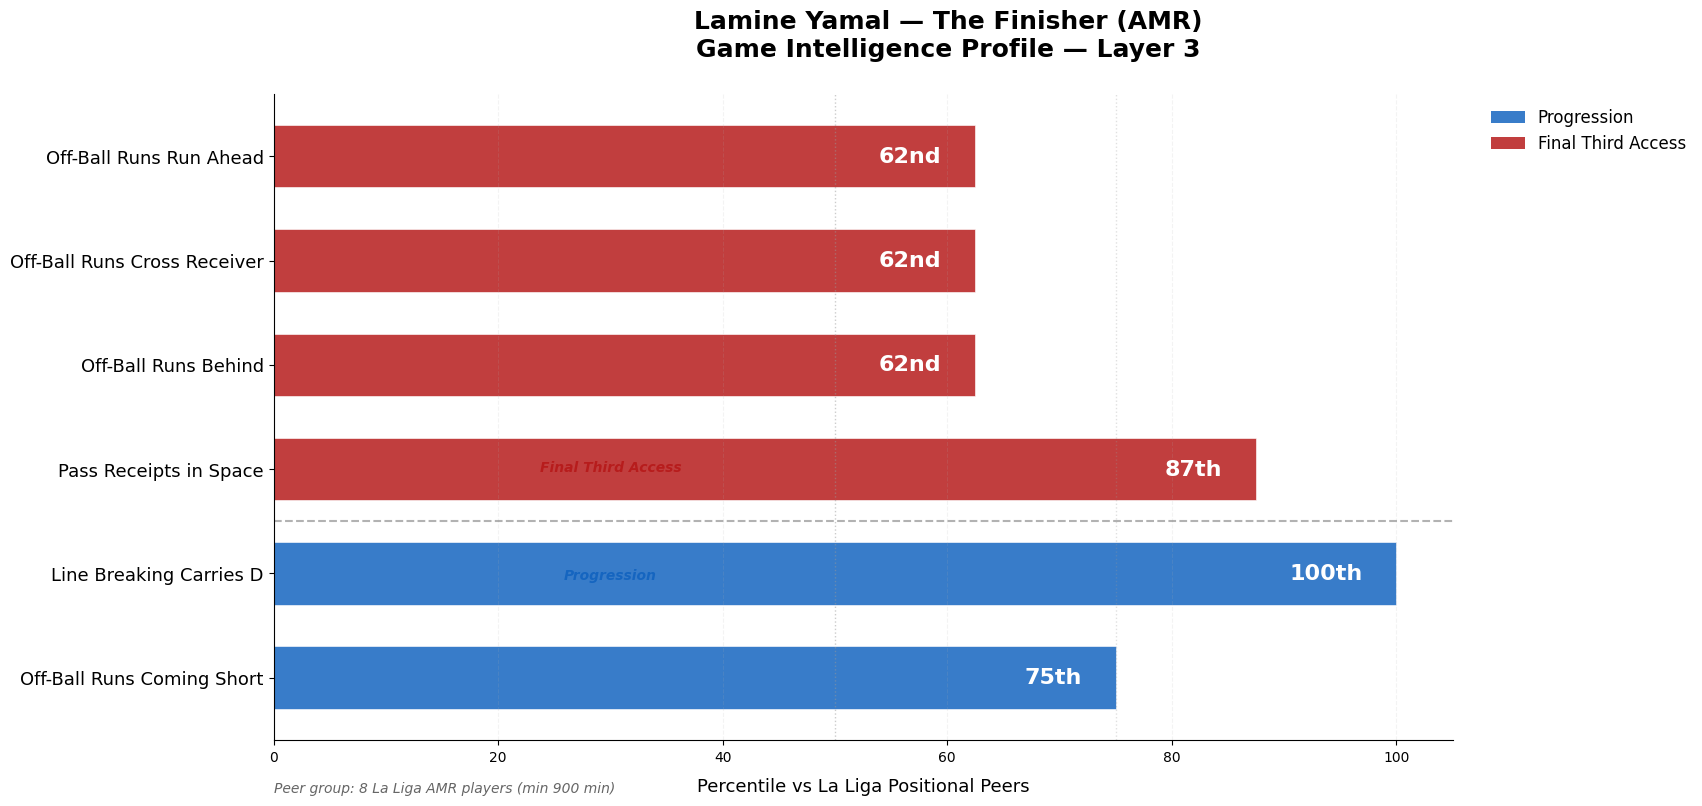

Saved: layer3_lamine_yamal.png


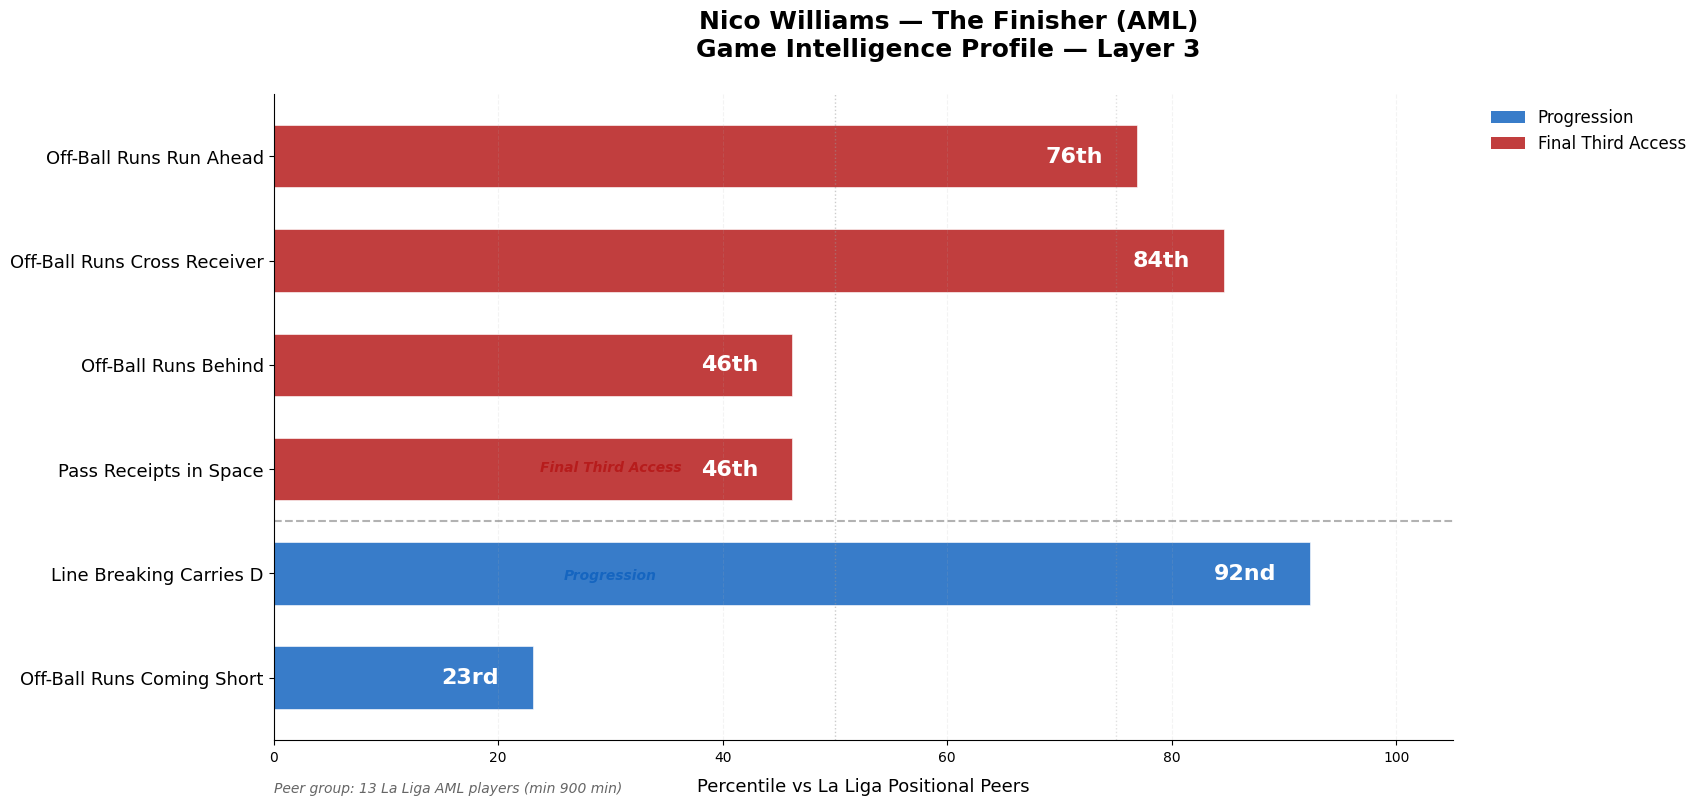

Saved: layer3_nico_williams.png


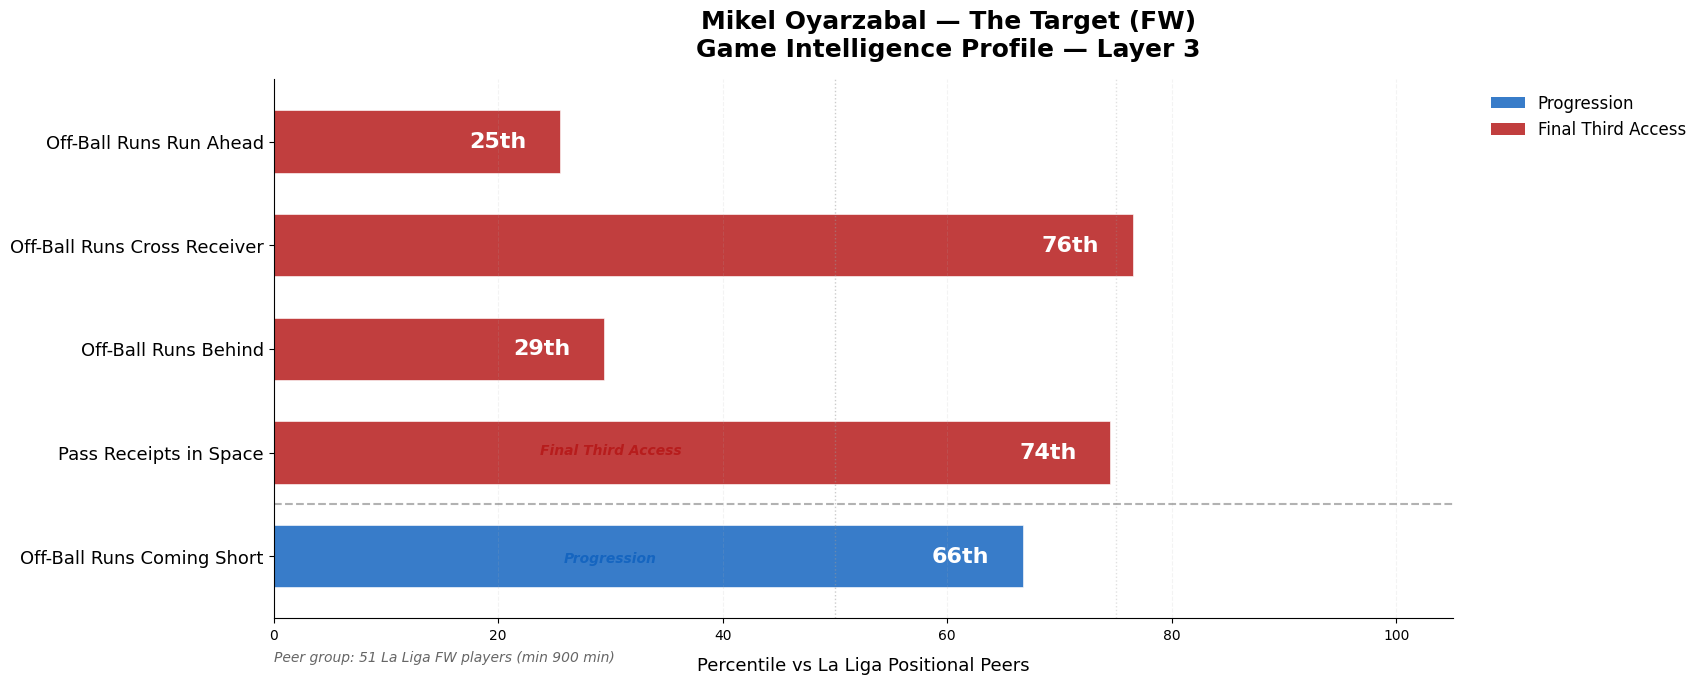

Saved: layer3_mikel_oyarzabal.png

All individual profiles saved.

Building Yamal vs Nico radar chart...


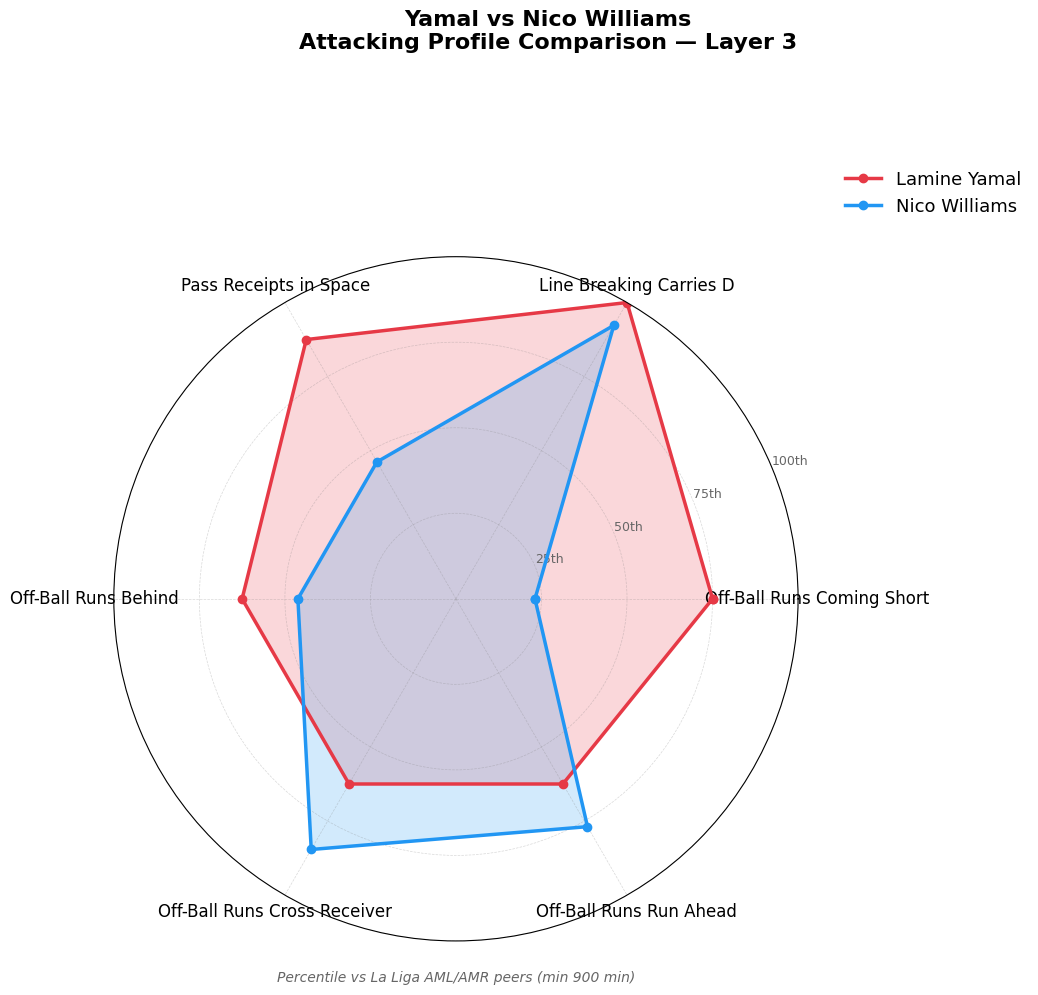

Saved: layer3_yamal_vs_nico_radar.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metric_labels = {
    'lineBreakingPasses_p90': 'Line Breaking Passes',
    'lineBreakingPassesMD_p90': 'Line Breaking Passes MD',
    'lineBreakingThroughBalls_p90': 'Line Breaking Through Balls',
    'lineBreakingCarriesD_p90': 'Line Breaking Carries D',
    'bypassedDefendersByPasses_p90': 'Bypassed Defenders by Passes',
    'passingUnderStrongPressure_pct': 'Passing Under Strong Pressure %',
    'offBallRunsComingShort_p90': 'Off-Ball Runs Coming Short',
    'passReceiptsInSpaceCompleted_p90': 'Pass Receipts in Space',
    'offBallRunsRunBehind_p90': 'Off-Ball Runs Behind',
    'offBallRunsCrossReceiver_p90': 'Off-Ball Runs Cross Receiver',
    'offBallRunsRunAhead_p90': 'Off-Ball Runs Run Ahead',
}

progression_color = '#1565C0'
final_third_color = '#B71C1C'

peer_sizes = {
    'Pau Cubarsi': 73, 'Pedri': 22, 'Dani Olmo': 15,
    'Lamine Yamal': 8, 'Nico Williams': 13, 'Mikel Oyarzabal': 51
}

def ordinal(n):
    n = int(n)
    if 11 <= (n % 100) <= 13:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

for result in results:
    player = result['player']
    role = result['role']
    position = result['position']
    metrics = result['metrics']

    if not metrics:
        continue

    prog_metrics = [m for m in metrics if m['category'] == 'Progression']
    ft_metrics = [m for m in metrics if m['category'] == 'Final Third']
    all_metrics = prog_metrics + ft_metrics

    labels = [metric_labels.get(m['metric'], m['metric'])
              for m in all_metrics]
    percentiles = [m['percentile'] for m in all_metrics]
    colors = [progression_color if m['category'] == 'Progression'
              else final_third_color for m in all_metrics]

    n = len(all_metrics)

    fig, ax = plt.subplots(figsize=(18, max(7, n * 1.4)))
    plt.subplots_adjust(right=0.78)

    fig.suptitle(
        f"{player} — {role} ({position})\n"
        f"Game Intelligence Profile — Layer 3",
        fontsize=18, fontweight='bold', y=0.98
    )

    y_pos = np.arange(n)
    bars = ax.barh(
        y_pos, percentiles,
        color=colors, alpha=0.85,
        edgecolor='white', linewidth=0.5,
        height=0.6
    )

    for i, (bar, pct) in enumerate(zip(bars, percentiles)):
        label_x = pct - 3 if pct > 15 else pct + 2
        label_ha = 'right' if pct > 15 else 'left'
        label_color = 'white' if pct > 15 else '#222222'
        ax.text(
            label_x, i,
            ordinal(pct),
            va='center', ha=label_ha,
            fontsize=16, fontweight='bold',
            color=label_color
        )

    if prog_metrics and ft_metrics:
        divider_y = len(prog_metrics) - 0.5
        ax.axhline(
            y=divider_y,
            color='#666666', linewidth=1.5,
            linestyle='--', alpha=0.5
        )
        ax.text(
            30, divider_y + 0.45,
            'Final Third Access',
            ha='center', va='bottom',
            fontsize=10, color=final_third_color,
            fontstyle='italic', fontweight='bold'
        )
        ax.text(
            30, divider_y - 0.45,
            'Progression',
            ha='center', va='top',
            fontsize=10, color=progression_color,
            fontstyle='italic', fontweight='bold'
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel(
        'Percentile vs La Liga Positional Peers',
        fontsize=13, labelpad=10
    )
    ax.set_xlim(0, 105)
    ax.set_ylim(-0.6, n - 0.4)

    ax.axvline(x=50, color='#999999', linewidth=1.0,
               linestyle=':', alpha=0.5)
    ax.axvline(x=75, color='#999999', linewidth=1.0,
               linestyle=':', alpha=0.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.15, linestyle='--')

    prog_patch = mpatches.Patch(
        facecolor=progression_color, alpha=0.85,
        label='Progression'
    )
    ft_patch = mpatches.Patch(
        facecolor=final_third_color, alpha=0.85,
        label='Final Third Access'
    )
    ax.legend(
        handles=[prog_patch, ft_patch],
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        fontsize=12, frameon=False
    )

    ax.text(
        0.0, -0.08,
        f"Peer group: {peer_sizes[player]} La Liga "
        f"{position} players (min 900 min)",
        transform=ax.transAxes,
        fontsize=10, color='#666666',
        style='italic'
    )

    filename = f"layer3_{player.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

print("\nAll individual profiles saved.")

# Radar chart — Yamal vs Nico Williams
print("\nBuilding Yamal vs Nico radar chart...")

radar_metrics = [
    'offBallRunsComingShort_p90',
    'lineBreakingCarriesD_p90',
    'passReceiptsInSpaceCompleted_p90',
    'offBallRunsRunBehind_p90',
    'offBallRunsCrossReceiver_p90',
    'offBallRunsRunAhead_p90'
]

radar_labels = [metric_labels[m] for m in radar_metrics]

def get_percentiles_for_radar(player_name, metrics_list):
    result = next(
        (r for r in results if r['player'] == player_name), None
    )
    if not result:
        return []
    pcts = []
    for m in metrics_list:
        found = next(
            (x for x in result['metrics'] if x['metric'] == m), None
        )
        pcts.append(found['percentile'] if found else 0)
    return pcts

yamal_pcts = get_percentiles_for_radar('Lamine Yamal', radar_metrics)
nico_pcts = get_percentiles_for_radar('Nico Williams', radar_metrics)

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

yamal_vals = yamal_pcts + yamal_pcts[:1]
nico_vals = nico_pcts + nico_pcts[:1]

fig, ax = plt.subplots(
    figsize=(11, 11),
    subplot_kw=dict(polar=True)
)

fig.suptitle(
    "Yamal vs Nico Williams\n"
    "Attacking Profile Comparison — Layer 3",
    fontsize=16, fontweight='bold', y=0.98
)

ax.plot(angles, yamal_vals, 'o-', linewidth=2.5,
        color='#E63946', label='Lamine Yamal')
ax.fill(angles, yamal_vals, alpha=0.2, color='#E63946')

ax.plot(angles, nico_vals, 'o-', linewidth=2.5,
        color='#2196F3', label='Nico Williams')
ax.fill(angles, nico_vals, alpha=0.2, color='#2196F3')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(
    ['25th', '50th', '75th', '100th'],
    fontsize=9, color='#666666'
)
ax.grid(color='grey', linestyle='--',
        linewidth=0.5, alpha=0.3)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.15),
    fontsize=13, frameon=False
)

ax.text(
    0.5, -0.06,
    "Percentile vs La Liga AML/AMR peers (min 900 min)",
    transform=ax.transAxes,
    ha='center', fontsize=10,
    color='#666666', style='italic'
)

plt.tight_layout()
plt.savefig(
    'layer3_yamal_vs_nico_radar.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: layer3_yamal_vs_nico_radar.png")

# Layer 3 — Output Explanation
## Game Intelligence Profiles

---

## Overview

The physical layers assessed whether these
players meet World Cup physical standards.
Layer 3 investigates a different question —
how do they contribute to the specific
tactical outcomes most associated with
Spain's physical identity?

Bradley's Part 2 found that Spain's high
intensity runs in possession correlated
most strongly with progression events
(r=0.73) and final third entries (r=0.75).
The profiles below map those outcomes at
player level using Driblab's Arrigo metrics
ranked against La Liga positional peers.

These are not rankings. They are profiles
of how six players contribute to one
attacking mechanism.

---

## Pau Cubarsi — The Initiator (DC)
### 74th percentile Line Breaking Passes
### 79th percentile Line Breaking Passes MD

Cubarsi's profile is consistent with what
Barcelona's build-up play has shown this
season. He contributes to progression not
just through safe distribution but through
passes that actively break defensive lines.

His 74th percentile for line breaking passes
and 79th for passes that simultaneously
penetrate both the midfield and defensive
line are strong numbers for a centre back
operating among 73 La Liga peers. The more
penetrating the pass the higher he ranks —
which suggests his progression value comes
from quality of action rather than volume.

His 38th percentile for bypassed defenders
and 46th percentile for passing under strong
pressure suggest that his strongest
progression actions occur in more structured
build-up situations than under sustained
defensive pressure. This appears more
descriptive of his role than a weakness
in his profile.

---

## Pedri — The Connector (DMC)
### 100th percentile Line Breaking Passes
### 100th percentile Line Breaking Passes MD
### 100th percentile Line Breaking Through Balls
### 100th percentile Bypassed Defenders by Passes

Pedri's progression profile is the most
dominant in the sample. Across every
progression metric tested he ranks first
among 22 La Liga defensive and central
midfielders — which is consistent with
what most observers already see when
watching him at Barcelona and Spain.

The four 100th percentile scores suggest
he is not just producing volume but
producing the most dangerous type of
progressive action in his positional
group. His 81st percentile for passing
under strong pressure indicates this
output is maintained even when pressed.
His 81st percentile for runs ahead adds
a further dimension — he creates
progressive sequences and then makes
the forward run to continue them.

Driblab classifies Pedri as DMC. His
percentiles reflect that peer group —
defensive and central midfielders whose
profiles differ significantly from his
attacking and creative role at Barcelona.
His percentiles should therefore be
interpreted within the context of
Driblab's DMC classification.

---

## Dani Olmo — The Link (AMC)
### 93rd percentile Line Breaking Passes
### 93rd percentile Line Breaking Through Balls
### 93rd percentile Off-Ball Runs Run Ahead
### 87th percentile Off-Ball Runs Behind

Olmo was the player that surprised me most
in this layer. His physical Readiness Index
of 67.9 was the lowest in the sample — yet
his Arrigo profile is consistently strong
across both progression and final third
metrics simultaneously.

Among 15 La Liga attacking midfielders he
ranks in the 93rd percentile for line
breaking passes, through balls and runs
ahead. He adds 87th percentile for runs
behind and 80th for both coming short
and receipts in space. His average
percentile is 85th for progression and
87th for final third access — the most
balanced profile across both categories
in the sample.

These characteristics appear consistent
with the role Spain typically ask their
advanced attacking midfielders to perform —
dropping to receive, progressing quickly
under pressure and arriving into the
spaces the progression creates.

The player whose physical scores indicated
least readiness shows the most complete
game intelligence profile in the sample.
That tension is probably the most
interesting finding in the project.

---

## Lamine Yamal — The Finisher (AMR)
### 100th percentile Line Breaking Carries D
### 87th percentile Pass Receipts in Space

Yamal's profile indicates that his primary
contribution in the final third is less
about movement into spaces others create
and more about receiving and then creating
danger through carrying.

His 100th percentile for line breaking
carries that penetrate the defensive line
is the standout figure. Among La Liga
right attacking midfielders with 900 or
more minutes he carries through defensive
lines more frequently than any peer per
90 minutes. His 87th percentile for pass
receipts in space supports the idea that
he finds dangerous areas to receive
consistently.

His 62nd percentile across runs behind,
runs ahead and cross receiver runs suggests
his movement profile is less focused on
running into the spaces progression creates
and more on receiving earlier and then
driving through those spaces himself.

Against deep defensive blocks — which
Spain are likely to face in the knockout
rounds — that carry profile appears well
suited to the demands of breaking
organised defences.

The peer group for this analysis is small
— eight La Liga AMR players with 900 or
more minutes. The direction of the findings
is clear but the precision of the
percentiles should be read with that
sample size in mind.

---

## Nico Williams — The Finisher (AML)
### 92nd percentile Line Breaking Carries D
### 84th percentile Off-Ball Runs Cross Receiver
### 76th percentile Off-Ball Runs Run Ahead

Nico and Yamal were expected to show
similar profiles given their comparable
roles. The data suggests they are similar
players with meaningfully different
approaches to the same function.

Nico's 92nd percentile for line breaking
carries is close to Yamal's 100th — he
also carries through defensive lines
frequently and effectively. His 84th
percentile for cross receiver runs is
notably higher than Yamal's 62nd,
indicating he arrives for crosses more
consistently.

Where the profiles diverge is in the
receipt and combination metrics. His
46th percentile for pass receipts in
space and 23rd for runs coming short
are considerably lower than Yamal's
equivalent figures. He appears to
create danger more through direct
running and arriving late into positions
than through dropping to receive,
combining and then attacking again.

For Spain this distinction may have
tactical implications depending on the
opponent. The radar chart makes the
profile difference visible — Yamal's
shape is broader across the receipt
and carry axes while Nico's is more
concentrated on the carry and cross
receiver dimensions.

---

## Mikel Oyarzabal — The Target (FW)
### 76th percentile Off-Ball Runs Cross Receiver
### 74th percentile Pass Receipts in Space
### 67th percentile Off-Ball Runs Coming Short

Oyarzabal's profile illustrates the
importance of reading percentiles alongside
raw outputs rather than in isolation.

His 29th percentile for runs behind and
25th for runs ahead appear low at first
glance. However his raw season total of
154 runs behind is the highest among all
six players in this sample — nearly double
Yamal's total of 88. The explanation lies
in his peer group. Among 51 La Liga
forwards his positional peers include
Vinicius Junior, Kylian Mbappe, Vedat
Muriqi and Ante Budimir — players whose
movement profiles are built almost
entirely on high volume forward running.
Relative to that group his output appears
average. In absolute terms it is not.

His 74th percentile for pass receipts in
space, 76th for cross receiver runs and
67th for coming short suggest a profile
more consistent with a complete striker —
one who links play, finds central spaces
and arrives at the right moment — than
a pure depth runner.

This appears consistent with what his
performances showed during Spain's games.
His value is less about being the highest
volume runner and more about the timing
and variety of his movement within the
attacking sequence.

Combined with the physical findings from
Layers 1 and 2, this profile suggests a
player capable of matching World Cup
physical demands while contributing
through intelligent occupation of
advanced spaces.

---

## The Complete Picture

Reading these profiles together suggests
a clearer picture of how Spain's attacking
mechanism is distributed across the squad.

Pedri's progression output stands clearly
above the rest of the sample. Olmo's
combined progression and final third
profile is the most complete. Yamal and
Nico create danger through different
mechanisms despite occupying comparable
roles. Cubarsi initiates in structured
situations. Oyarzabal arrives in the
right spaces at the right moments.

The finding that stands out most is the
gap between Olmo's physical scores and
his game intelligence profile. The data
consistently supports the idea that his
contribution to Spain's mechanism may
be understated by the physical layers
alone. Whether that translates directly
to World Cup performance involves context
the data cannot fully capture — opponent
organisation, game state, tournament
pressure — but the profile is clear.

What Bradley identified at team level
— that physical intensity in possession
serves progression and final third access
— these profiles attempt to map at
individual level. The chain from
initiation to finishing appears coherent
in the data.

The tournament will determine whether
it holds.

## Limitations

This analysis is based on club data rather
than national team data.

Arrigo metrics are season totals and cannot
currently be filtered by phase of play at
player level. Football remains contextual.
Opponent quality, game state and tactical
instructions all influence player behaviour
in ways that season-level data cannot fully
capture.

Squad availability adds further contextual
uncertainty. At the time of publication
Lamine Yamal and Nico Williams are carrying
injuries and their availability for Spain's
opening games is uncertain. Their profiles
reflect what they contribute when match fit
— not their current fitness status.

Full methodology and detailed caveats are
available in the GitHub repository and the
published article.

## Spain's Progressing Network

The individual profiles explain what each player contributes. This network brings those profiles together and illustrates how Spain's attacking structure may function as a collective mechanism.

The progression begins with Cubarsí, whose line-breaking distribution helps initiate attacks from deep. Pedri acts as the primary progression hub, advancing possession through midfield and consistently breaking opposition lines. Olmo operates between the lines, linking progression to final-third access and connecting different phases of the attack.

From there, the profile splits into two complementary wide threats. Yamal frequently drives progression through carrying and creation, while Nico provides a more direct threat through movement into space and attacking runs. Both offer different solutions to the same tactical problem.

At the end of the sequence is Oyarzabal. While often viewed primarily as a finisher, his profile also suggests an important connecting role before arriving in central scoring positions.

This should not be interpreted as a fixed passing pattern or an average positional map. Rather, it is a conceptual representation of how the progression and final-third profiles identified in Layer 3 interact within Spain's attacking framework.

Taken together, the physical and tactical intelligence layers suggest a team whose physical output serves a clear football purpose: progressing the ball, accessing dangerous areas and creating high-value attacking situations.

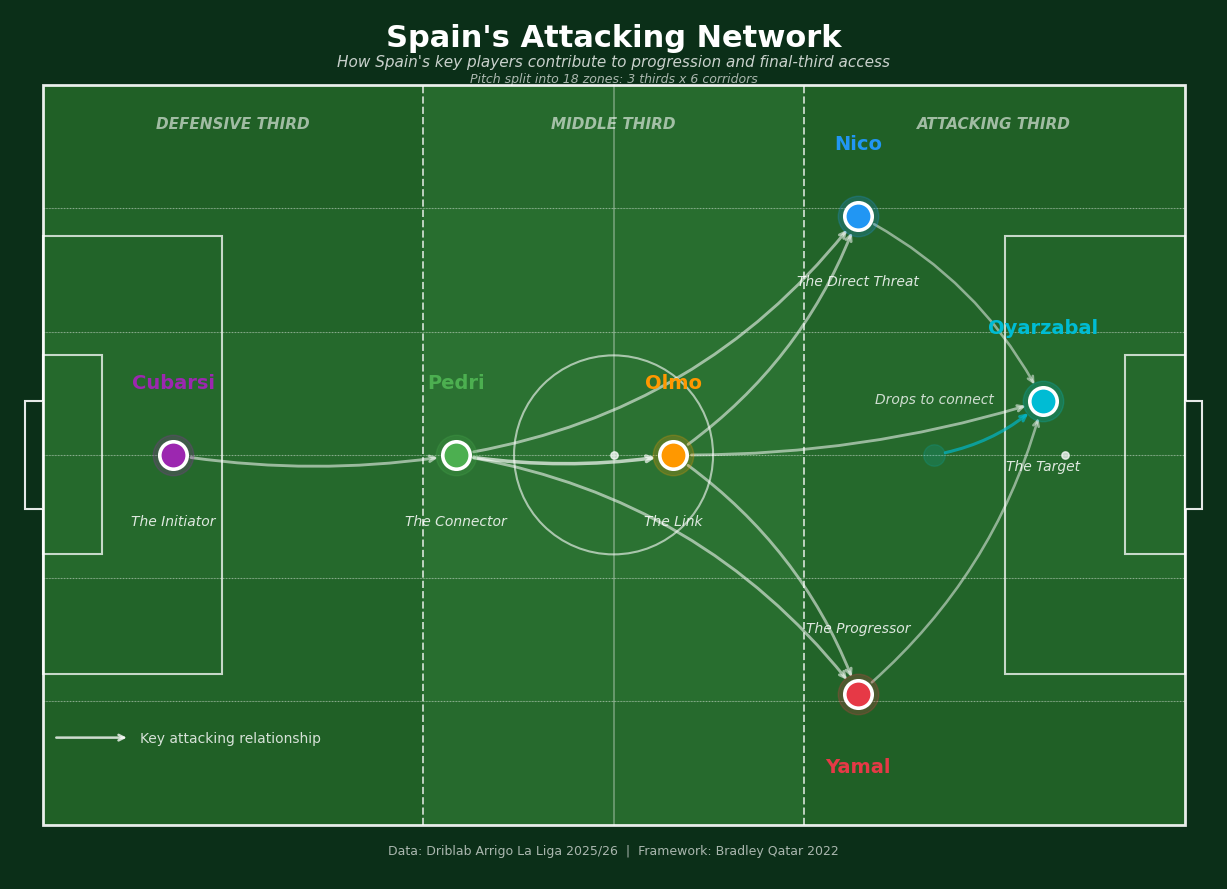

Saved: spain_attacking_network_final.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor("#0b2f18")
ax.set_facecolor("#2f7d32")

ax.set_xlim(-3, 108)
ax.set_ylim(-5, 75)
ax.set_aspect("equal")
ax.axis("off")

# -----------------------------
# Pitch dimensions
# -----------------------------
pitch_length = 105
pitch_width = 68

# 18-zone model: 3 thirds x 6 horizontal corridors
third_lines_x = [35, 70]
corridor_lines_y = [
    pitch_width / 6,
    pitch_width * 2 / 6,
    pitch_width * 3 / 6,
    pitch_width * 4 / 6,
    pitch_width * 5 / 6,
]

# -----------------------------
# Background thirds and corridors
# -----------------------------
third_colours = ["#2e7d32", "#388e3c", "#2e7d32"]

for i, colour in enumerate(third_colours):
    ax.add_patch(
        mpatches.Rectangle(
            (i * 35, 0),
            35,
            pitch_width,
            facecolor=colour,
            edgecolor="none",
            alpha=0.65,
            zorder=0
        )
    )

# Subtle corridor bands, no corridor labels
band_colours = [
    "#1b5e20",
    "#2e7d32",
    "#43a047",
    "#43a047",
    "#2e7d32",
    "#1b5e20",
]

for i, colour in enumerate(band_colours):
    y0 = i * pitch_width / 6

    ax.add_patch(
        mpatches.Rectangle(
            (0, y0),
            pitch_length,
            pitch_width / 6,
            facecolor=colour,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.13,
            zorder=1
        )
    )

# -----------------------------
# Pitch markings
# -----------------------------
ax.add_patch(
    mpatches.Rectangle(
        (0, 0),
        pitch_length,
        pitch_width,
        linewidth=2,
        edgecolor="white",
        facecolor="none",
        alpha=0.9,
        zorder=6
    )
)

# Third lines
for x in third_lines_x:
    ax.plot(
        [x, x],
        [0, pitch_width],
        color="white",
        linewidth=1.4,
        alpha=0.70,
        linestyle="--",
        zorder=6
    )

# Corridor lines
for y in corridor_lines_y:
    ax.plot(
        [0, pitch_length],
        [y, y],
        color="white",
        linewidth=0.8,
        alpha=0.35,
        linestyle=":",
        zorder=6
    )

# Halfway line
ax.plot(
    [pitch_length / 2, pitch_length / 2],
    [0, pitch_width],
    color="white",
    linewidth=1.2,
    alpha=0.35,
    zorder=6
)

# Centre circle
ax.add_patch(
    mpatches.Circle(
        (52.5, 34),
        9.15,
        linewidth=1.5,
        edgecolor="white",
        facecolor="none",
        alpha=0.60,
        zorder=6
    )
)

# Centre and penalty spots
for x, y in [(52.5, 34), (11, 34), (94, 34)]:
    ax.scatter(
        x,
        y,
        s=28,
        color="white",
        alpha=0.75,
        zorder=6
    )

# Penalty areas
for x in [0, 88.5]:
    ax.add_patch(
        mpatches.Rectangle(
            (x, 13.85),
            16.5,
            40.3,
            linewidth=1.5,
            edgecolor="white",
            facecolor="none",
            alpha=0.75,
            zorder=6
        )
    )

# Goal areas
for x in [0, 99.5]:
    ax.add_patch(
        mpatches.Rectangle(
            (x, 24.85),
            5.5,
            18.3,
            linewidth=1.5,
            edgecolor="white",
            facecolor="none",
            alpha=0.75,
            zorder=6
        )
    )

# Goals
ax.add_patch(
    mpatches.Rectangle(
        (-1.6, 29.0),
        1.6,
        10.0,
        linewidth=1.5,
        edgecolor="white",
        facecolor="#0b2f18",
        alpha=0.9,
        zorder=6
    )
)

ax.add_patch(
    mpatches.Rectangle(
        (105, 29.0),
        1.6,
        10.0,
        linewidth=1.5,
        edgecolor="white",
        facecolor="#0b2f18",
        alpha=0.9,
        zorder=6
    )
)

# -----------------------------
# Third labels only
# -----------------------------
third_labels = [
    (17.5, 64.5, "DEFENSIVE THIRD"),
    (52.5, 64.5, "MIDDLE THIRD"),
    (87.5, 64.5, "ATTACKING THIRD"),
]

for x, y, label in third_labels:
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        alpha=0.58,
        fontweight="bold",
        fontstyle="italic",
        zorder=7
    )

# -----------------------------
# Title and subtitle
# -----------------------------
ax.text(
    52.5,
    72.4,
    "Spain's Attacking Network",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color="white",
    zorder=10
)

ax.text(
    52.5,
    70.2,
    "How Spain's key players contribute to progression and final-third access",
    ha="center",
    va="center",
    fontsize=11,
    color="white",
    alpha=0.78,
    fontstyle="italic",
    zorder=10
)

ax.text(
    52.5,
    68.6,
    "Pitch split into 18 zones: 3 thirds x 6 corridors",
    ha="center",
    va="center",
    fontsize=9,
    color="white",
    alpha=0.65,
    fontstyle="italic",
    zorder=10
)

# -----------------------------
# Player positions
# -----------------------------
player_positions = {
    "Cubarsi": (12, 34),
    "Pedri": (38, 34),
    "Olmo": (58, 34),
    "Nico": (75, 56),
    "Yamal": (75, 12),
    "Oyarzabal": (92, 39),
}

player_colors = {
    "Cubarsi": "#9C27B0",
    "Pedri": "#4CAF50",
    "Olmo": "#FF9800",
    "Yamal": "#E63946",
    "Nico": "#2196F3",
    "Oyarzabal": "#00BCD4",
}

player_roles = {
    "Cubarsi": "The Initiator",
    "Pedri": "The Connector",
    "Olmo": "The Link",
    "Yamal": "The Progressor",
    "Nico": "The Direct Threat",
    "Oyarzabal": "The Target",
}

# -----------------------------
# Attacking relationships
# -----------------------------
connections = [
    ("Cubarsi", "Pedri", 0.66, 0.08),
    ("Pedri", "Olmo", 0.95, 0.08),
    ("Pedri", "Nico", 0.68, 0.20),
    ("Pedri", "Yamal", 0.68, -0.20),
    ("Olmo", "Nico", 0.66, 0.16),
    ("Olmo", "Yamal", 0.66, -0.16),
    ("Olmo", "Oyarzabal", 0.64, 0.08),
    ("Nico", "Oyarzabal", 0.54, -0.16),
    ("Yamal", "Oyarzabal", 0.54, 0.16),
]

for start, end, strength, curve in connections:
    x1, y1 = player_positions[start]
    x2, y2 = player_positions[end]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="white",
            lw=1.0 + strength * 1.6,
            alpha=0.25 + strength * 0.45,
            shrinkA=13,
            shrinkB=13,
            connectionstyle=f"arc3,rad={curve}",
        ),
        zorder=8
    )

# -----------------------------
# Oyarzabal dropping movement
# -----------------------------
drop_x, drop_y = 82, 34
oyarzabal_x, oyarzabal_y = player_positions["Oyarzabal"]

ax.scatter(
    drop_x,
    drop_y,
    s=240,
    color=player_colors["Oyarzabal"],
    alpha=0.16,
    zorder=7
)

ax.annotate(
    "",
    xy=(oyarzabal_x, oyarzabal_y),
    xytext=(drop_x, drop_y),
    arrowprops=dict(
        arrowstyle="->",
        color=player_colors["Oyarzabal"],
        lw=2.2,
        alpha=0.65,
        shrinkA=8,
        shrinkB=14,
        connectionstyle="arc3,rad=0.15"
    ),
    zorder=8
)

ax.text(
    drop_x,
    drop_y + 4.5,
    "Drops to connect",
    ha="center",
    va="bottom",
    fontsize=10,
    color="white",
    alpha=0.78,
    fontstyle="italic",
    zorder=9
)

# -----------------------------
# Player nodes and labels
# -----------------------------
name_offsets = {
    "Cubarsi": (0, 5.8),
    "Pedri": (0, 5.8),
    "Olmo": (0, 5.8),
    "Nico": (0, 5.8),
    "Yamal": (0, -5.8),
    "Oyarzabal": (0, 5.8),
}

role_offsets = {
    "Cubarsi": (0, -5.4),
    "Pedri": (0, -5.4),
    "Olmo": (0, -5.4),
    "Nico": (0, -5.4),
    "Yamal": (0, 5.4),
    "Oyarzabal": (0, -5.4),
}

for player, (x, y) in player_positions.items():
    colour = player_colors[player]

    ax.scatter(
        x,
        y,
        s=850,
        color=colour,
        alpha=0.22,
        zorder=9
    )

    ax.scatter(
        x,
        y,
        s=390,
        color=colour,
        edgecolor="white",
        linewidth=2.6,
        zorder=10
    )

    nox, noy = name_offsets[player]
    rox, roy = role_offsets[player]

    ax.text(
        x + nox,
        y + noy,
        player,
        ha="center",
        va="bottom" if noy > 0 else "top",
        fontsize=14,
        fontweight="bold",
        color=colour,
        zorder=11
    )

    ax.text(
        x + rox,
        y + roy,
        player_roles[player],
        ha="center",
        va="top" if roy < 0 else "bottom",
        fontsize=10,
        color="white",
        alpha=0.85,
        fontstyle="italic",
        zorder=11
    )

# -----------------------------
# Legend
# -----------------------------
ax.annotate(
    "",
    xy=(8, 8),
    xytext=(1, 8),
    arrowprops=dict(
        arrowstyle="->",
        color="white",
        lw=1.8,
        alpha=0.78
    ),
    zorder=11
)

ax.text(
    9,
    8,
    "Key attacking relationship",
    va="center",
    fontsize=10,
    color="white",
    alpha=0.82,
    zorder=11
)

# -----------------------------
# Data source
# -----------------------------
ax.text(
    52.5,
    -2.4,
    "Data: Driblab Arrigo La Liga 2025/26  |  Framework: Bradley Qatar 2022",
    ha="center",
    va="center",
    fontsize=9,
    color="white",
    alpha=0.65,
    zorder=11
)

plt.tight_layout()

plt.savefig(
    "spain_attacking_network_final.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="#0b2f18"
)

plt.show()

print("Saved: spain_attacking_network_final.png")

# The Physical-Tactical Tension Chart
## Readiness Index vs Game Intelligence Profile

## What this chart shows

Each player is plotted against two dimensions
simultaneously — their Readiness Index from
Layers 1 and 2 and their average Layer 3
percentile across all metrics.

The chart makes the project's central finding
immediately visible. The player with the
lowest physical readiness score produces
the strongest game intelligence profile
in the sample. That tension between physical
output and tactical intelligence is the
most interesting analytical finding in
the project.

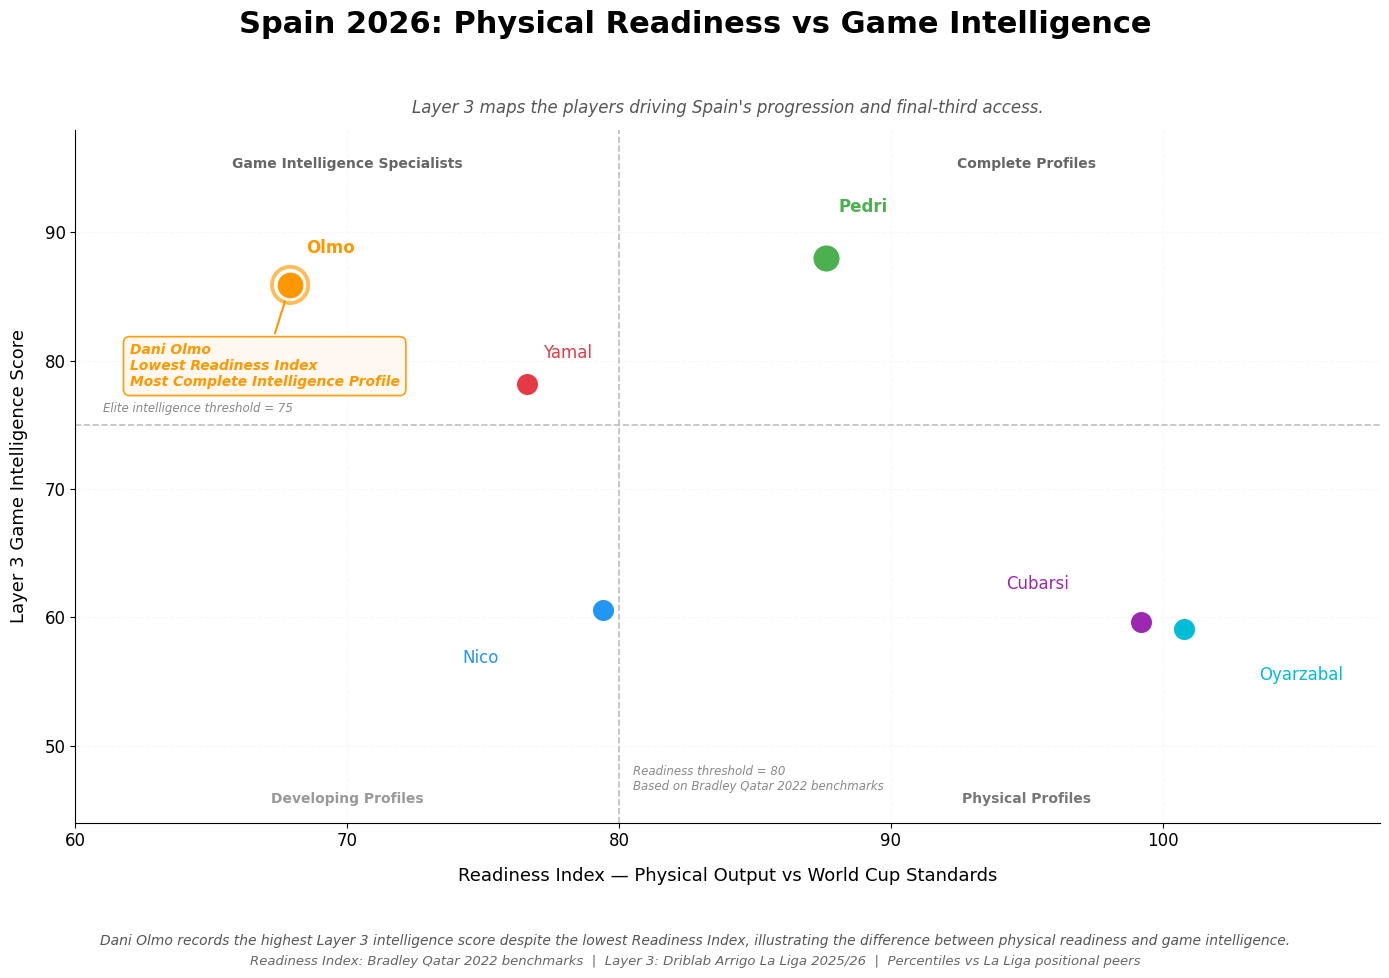

Saved: physical_vs_intelligence_scatter_article.png


In [ ]:
import matplotlib.pyplot as plt

players_scatter = [
    "Cubarsi", "Pedri", "Nico", "Yamal", "Olmo", "Oyarzabal"
]

readiness = {
    "Cubarsi": 100.0,
    "Pedri": 87.6,
    "Nico": 79.4,
    "Yamal": 76.6,
    "Olmo": 67.9,
    "Oyarzabal": 100.0
}

layer3_avg = {
    "Cubarsi": 59.6,
    "Pedri": 88.0,
    "Nico": 60.6,
    "Yamal": 78.2,
    "Olmo": 85.9,
    "Oyarzabal": 59.1
}

colors_scatter = {
    "Cubarsi": "#9C27B0",
    "Pedri": "#4CAF50",
    "Nico": "#2196F3",
    "Yamal": "#E63946",
    "Olmo": "#FF9800",
    "Oyarzabal": "#00BCD4"
}

# Slight x-position adjustment only to separate Cubarsi/Oyarzabal visually
x_positions = {
    "Cubarsi": 99.2,
    "Pedri": 87.6,
    "Nico": 79.4,
    "Yamal": 76.6,
    "Olmo": 67.9,
    "Oyarzabal": 100.8
}

label_offsets = {
    "Cubarsi": (-3.8, 2.6),
    "Pedri": (1.4, 3.6),
    "Nico": (-4.5, -4.2),
    "Yamal": (1.5, 2.0),
    "Olmo": (1.5, 2.5),
    "Oyarzabal": (4.3, -4.0)
}

marker_sizes = {
    "Cubarsi": 300,
    "Pedri": 440,
    "Nico": 300,
    "Yamal": 300,
    "Olmo": 430,
    "Oyarzabal": 300
}

fig, ax = plt.subplots(figsize=(14, 10))

fig.suptitle(
    "Spain 2026: Physical Readiness vs Game Intelligence",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

ax.set_title(
    "Layer 3 maps the players driving Spain's progression and final-third access.",
    fontsize=12,
    color="#555555",
    pad=12,
    fontstyle="italic"
)

# Thresholds
ax.axvline(
    x=80,
    color="#aaaaaa",
    linewidth=1.2,
    linestyle="--",
    alpha=0.75,
    zorder=1
)

ax.axhline(
    y=75,
    color="#aaaaaa",
    linewidth=1.2,
    linestyle="--",
    alpha=0.75,
    zorder=1
)

# Quadrant labels
ax.text(
    70, 95,
    "Game Intelligence Specialists",
    ha="center",
    fontsize=10,
    color="#666666",
    fontweight="bold"
)

ax.text(
    95, 95,
    "Complete Profiles",
    ha="center",
    fontsize=10,
    color="#666666",
    fontweight="bold"
)

ax.text(
    70, 45.5,
    "Developing Profiles",
    ha="center",
    fontsize=10,
    color="#999999",
    fontweight="bold"
)

ax.text(
    95, 45.5,
    "Physical Profiles",
    ha="center",
    fontsize=10,
    color="#777777",
    fontweight="bold"
)

# Threshold labels
ax.text(
    80.5, 46.3,
    "Readiness threshold = 80\nBased on Bradley Qatar 2022 benchmarks",
    fontsize=8.5,
    color="#888888",
    fontstyle="italic",
    va="bottom"
)

ax.text(
    61.0, 75.8,
    "Elite intelligence threshold = 75",
    fontsize=8.5,
    color="#888888",
    fontstyle="italic",
    va="bottom"
)

# Points and labels
for player in players_scatter:
    xi = x_positions[player]
    yi = layer3_avg[player]
    color = colors_scatter[player]

    ax.scatter(
        xi,
        yi,
        s=marker_sizes[player],
        color=color,
        edgecolor="white",
        linewidth=2.2,
        alpha=1.0,
        zorder=6 if player in ["Olmo", "Pedri"] else 5
    )

    ox, oy = label_offsets[player]

    ax.annotate(
        player,
        xy=(xi, yi),
        xytext=(xi + ox, yi + oy),
        fontsize=12,
        fontweight="bold" if player in ["Olmo", "Pedri"] else "normal",
        color=color,
        ha="center"
    )

# Olmo highlight ring
ax.scatter(
    x_positions["Olmo"],
    layer3_avg["Olmo"],
    s=680,
    color="none",
    edgecolor=colors_scatter["Olmo"],
    linewidth=2.8,
    zorder=7,
    alpha=0.65
)

# Olmo annotation box
ax.annotate(
    "Dani Olmo\nLowest Readiness Index\nMost Complete Intelligence Profile",
    xy=(x_positions["Olmo"], layer3_avg["Olmo"]),
    xytext=(62.0, 78.0),
    fontsize=10,
    color=colors_scatter["Olmo"],
    fontweight="bold",
    fontstyle="italic",
    arrowprops=dict(
        arrowstyle="->",
        color=colors_scatter["Olmo"],
        lw=1.5
    ),
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="#fff8f0",
        edgecolor=colors_scatter["Olmo"],
        linewidth=1.2,
        alpha=0.95
    )
)

# Axes
ax.set_xlabel(
    "Readiness Index — Physical Output vs World Cup Standards",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    "Layer 3 Game Intelligence Score",
    fontsize=13,
    labelpad=12
)

ax.set_xlim(60, 108)
ax.set_ylim(44, 98)

ax.tick_params(labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.08, linestyle="--")

# Caption / source note
fig.text(
    0.5, 0.045,
    "Dani Olmo records the highest Layer 3 intelligence score despite the lowest Readiness Index, "
    "illustrating the difference between physical readiness and game intelligence.",
    ha="center",
    fontsize=10,
    color="#555555",
    style="italic"
)

fig.text(
    0.5, 0.025,
    "Readiness Index: Bradley Qatar 2022 benchmarks  |  "
    "Layer 3: Driblab Arrigo La Liga 2025/26  |  "
    "Percentiles vs La Liga positional peers",
    ha="center",
    fontsize=9.5,
    color="#666666",
    style="italic"
)

plt.tight_layout(rect=[0, 0.09, 1, 0.95])

plt.savefig(
    "physical_vs_intelligence_scatter_article.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: physical_vs_intelligence_scatter_article.png")

# Layer 3 — Summary Matrix
## Game Intelligence Profiles at a Glance

## What this chart shows

The heatmap summarises each player's Layer 3
profile across the two categories motivated
by Bradley's findings — Progression (r=0.73)
and Final Third Access (r=0.75).

Categories reflect average percentile rankings
against La Liga positional peers:

Elite  — 80th percentile and above
High   — 65th to 79th percentile
Medium — 50th to 64th percentile
Low    — below 50th percentile

Cubarsi has no Final Third metrics — his role
is purely progression initiation from deep.
This is reflected as N/A rather than a low
score.

The chart is designed to communicate the
complete Layer 3 picture immediately. The
full percentile breakdowns and written
profiles for each player appear in the
sections above.

Together the six profiles suggest a squad
whose physical and tactical intelligence
is distributed across complementary roles
rather than concentrated in one or two
individuals — consistent with Spain's
collective attacking identity at Qatar 2022.

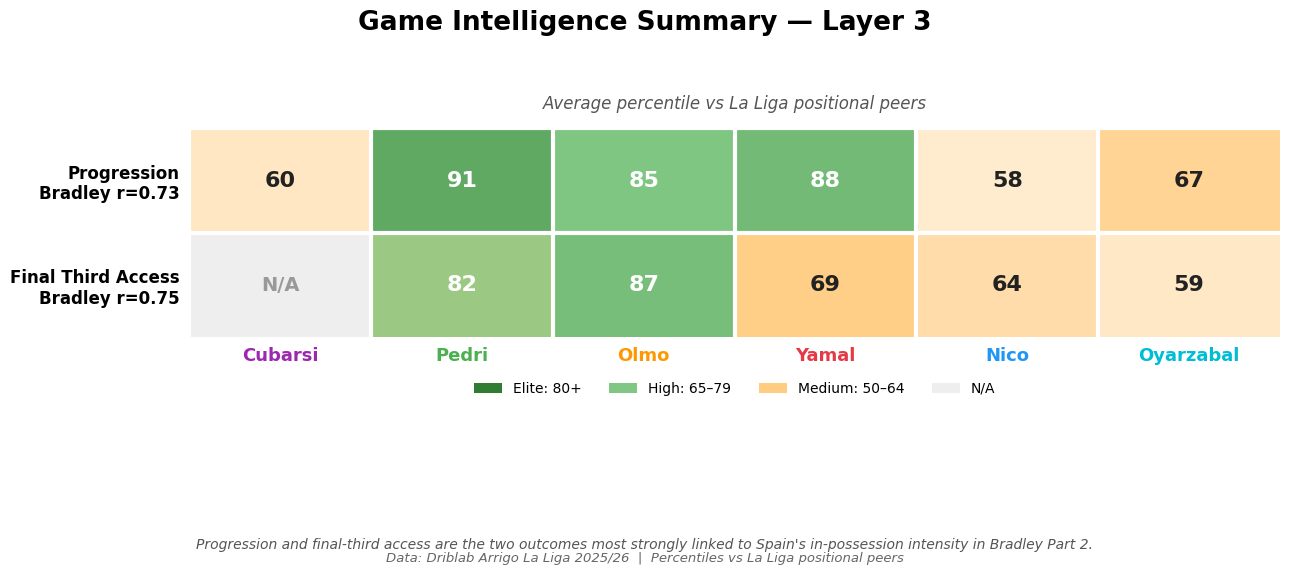

Saved: layer3_summary_heatmap_article.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

players_hm = [
    "Cubarsi", "Pedri", "Olmo",
    "Yamal", "Nico", "Oyarzabal"
]

player_colors_hm = [
    "#9C27B0",
    "#4CAF50",
    "#FF9800",
    "#E63946",
    "#2196F3",
    "#00BCD4",
]

# Actual average percentiles from internal summary
progression_vals = [59.6, 90.9, 85.0, 87.5, 57.7, 66.7]
final_third_vals = [None, 81.8, 86.7, 68.8, 63.5, 59.1]

data = np.array([
    progression_vals,
    [np.nan if v is None else v for v in final_third_vals]
], dtype=float)

# Custom calm article-style colour scale
cmap = LinearSegmentedColormap.from_list(
    "intelligence",
    ["#f4f4f4", "#fff3e0", "#ffcc80", "#81c784", "#2e7d32"],
    N=256
)
cmap.set_bad(color="#eeeeee")

fig, ax = plt.subplots(figsize=(13, 5.8))

fig.suptitle(
    "Game Intelligence Summary — Layer 3",
    fontsize=19,
    fontweight="bold",
    y=0.98
)

ax.set_title(
    "Average percentile vs La Liga positional peers",
    fontsize=12,
    color="#555555",
    pad=14,
    fontstyle="italic"
)

im = ax.imshow(
    data,
    cmap=cmap,
    vmin=40,
    vmax=100,
    aspect="auto"
)

# Axis labels
ax.set_xticks(np.arange(len(players_hm)))
ax.set_yticks([0, 1])

ax.set_xticklabels(
    players_hm,
    fontsize=13,
    fontweight="bold"
)

ax.set_yticklabels(
    [
        "Progression\nBradley r=0.73",
        "Final Third Access\nBradley r=0.75"
    ],
    fontsize=12,
    fontweight="bold"
)

# Colour player labels
for tick, colour in zip(ax.get_xticklabels(), player_colors_hm):
    tick.set_color(colour)

# Cell values
for row in range(2):
    for col in range(len(players_hm)):
        val = data[row, col]

        if np.isnan(val):
            ax.text(
                col,
                row,
                "N/A",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="#999999"
            )
        else:
            text_colour = "white" if val >= 80 else "#222222"

            ax.text(
                col,
                row,
                f"{val:.0f}",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=text_colour
            )

# White grid lines between cells
ax.set_xticks(np.arange(len(players_hm)) - 0.5, minor=True)
ax.set_yticks(np.arange(2) - 0.5, minor=True)

ax.grid(
    which="minor",
    color="white",
    linewidth=3
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# Remove spines and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    top=False,
    bottom=False,
    left=False,
    right=False
)

# Simple explanatory legend instead of colourbar
legend_items = [
    mpatches.Patch(facecolor="#2e7d32", label="Elite: 80+"),
    mpatches.Patch(facecolor="#81c784", label="High: 65–79"),
    mpatches.Patch(facecolor="#ffcc80", label="Medium: 50–64"),
    mpatches.Patch(facecolor="#eeeeee", label="N/A")
]

ax.legend(
    handles=legend_items,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.34),
    ncol=4,
    frameon=False,
    fontsize=10
)

# Caption / source note
fig.text(
    0.5,
    0.05,
    "Progression and final-third access are the two outcomes most strongly linked to Spain's "
    "in-possession intensity in Bradley Part 2.",
    ha="center",
    fontsize=10,
    color="#555555",
    style="italic"
)

fig.text(
    0.5,
    0.028,
    "Data: Driblab Arrigo La Liga 2025/26  |  Percentiles vs La Liga positional peers",
    ha="center",
    fontsize=9.5,
    color="#666666",
    style="italic"
)

plt.tight_layout(rect=[0, 0.14, 1, 0.93])

plt.savefig(
    "layer3_summary_heatmap_article.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: layer3_summary_heatmap_article.png")